<h1><center>Recommender Systems YSDA Course!</center></h1>
<h1><center>Семинар №2</center></h1>

<center><img src="https://github.com/yandexdataschool/recsys_course/blob/2026_spring/week02_candgen/logo.jpg?raw=1" width="500" /></center>

**В этом семинаре мы:**
- Познакомимся с датасетом YAMBDA
- Ссылка на оригинальный датасет: https://huggingface.co/datasets/yandex/yambda
- Посмотрим на контест курса: https://www.kaggle.com/competitions/ysda-rec-sys-2026
- Напишем бейзлайн
- Обучим более сложные модели (CatBoost)
- Напишем несколько новых метрик оценки качества ранжирования

**Баллы за пороги:**
- 5 баллов за пробитие 0.06
- 10 баллов за ...
- 15 баллов за ...
- Топ 3 - дополнительные 10 баллов
- Топ 10 - дополнительные 5 баллов

In [ ]:
!pip install catboost

In [ ]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, Pool

# 🗄 Датасет:

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "likes.parquet"

data = kagglehub.dataset_load(
  KaggleDatasetAdapter.POLARS,
  "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
  file_path
).collect().sample(10_000_000) # Ограничение для семинара, лучше использовать все данные

data

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


uid,timestamp,item_id,is_organic
u32,u32,u32,u8
166619,24119850,5007369,1
594868,806125,4332923,1
54266,8432095,4611073,0
159453,15087800,233181,0
695465,25939985,4552111,0
…,…,…,…
314719,11054670,7301075,0
380007,16885810,4720505,0
848483,1283080,6925370,0


In [ ]:
item_ids = data['item_id'].unique()
item_ids

item_id
u32
22
26
50
70
75
…
9390524
9390541
9390581


In [ ]:
file_path = "test_users.csv"

test_users = kagglehub.dataset_load(
  KaggleDatasetAdapter.POLARS,
  "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
  file_path
).collect()

test_users

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


uid
i64
89
153
164
216
291
…
999735
999737
999779


In [ ]:
file_path = "artist_item_mapping_small.parquet"

artists = kagglehub.dataset_load(
  KaggleDatasetAdapter.POLARS,
  "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
  file_path
).collect()

artists

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


artist_id,item_id
u32,u32
2,6990698
4,4427862
5,7240336
8,8639916
12,7016394
…,…
1293380,7614966
1293385,2465805
1293389,1958584


# 👀 Смотрим на датасет, знакомимся

In [ ]:
print('min timestamp: ', data['timestamp'].min())
print('max timestamp: ', data['timestamp'].max())

min timestamp:  20
max timestamp:  25999975


In [ ]:
print('count days: ', (data.max()['timestamp'] - data.min()['timestamp']).item() / 24 / 60 / 60)

count days:  300.9254050925926


In [ ]:
data['uid'].unique().count()

364445

In [ ]:
data['item_id'].unique().count()

202223

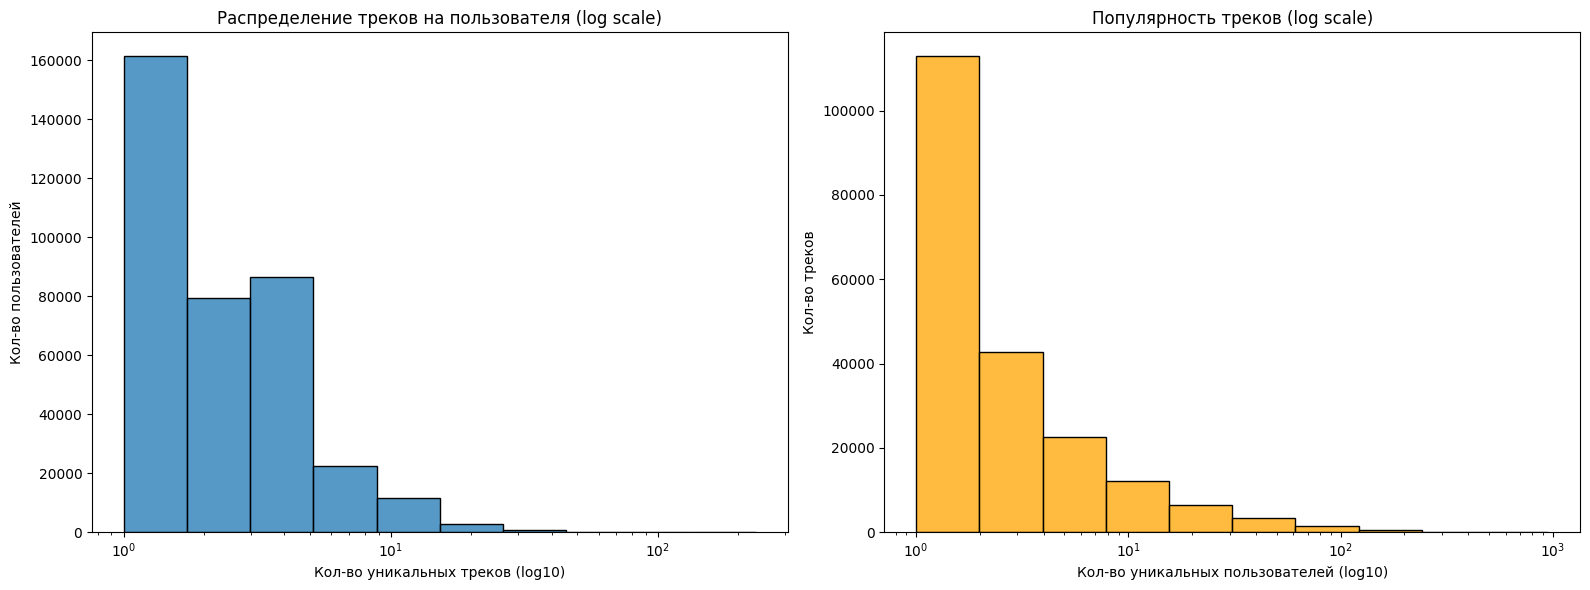

In [ ]:
tracks_per_user = data.group_by("uid").agg(
    pl.col("item_id").n_unique().alias("count")
)
users_per_track = data.group_by("item_id").agg(
    pl.col("uid").n_unique().alias("count")
)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(data=tracks_per_user, x="count", bins=10, ax=ax[0], log_scale=True)
ax[0].set_title("Распределение треков на пользователя (log scale)")
ax[0].set_xlabel("Кол-во уникальных треков (log10)")
ax[0].set_ylabel("Кол-во пользователей")

sns.histplot(data=users_per_track, x="count", bins=10, ax=ax[1], color="orange", log_scale=True)
ax[1].set_title("Популярность треков (log scale)")
ax[1].set_xlabel("Кол-во уникальных пользователей (log10)")
ax[1].set_ylabel("Кол-во треков")

plt.tight_layout()
plt.show()

In [ ]:
print('is_organic share: ', data['is_organic'].mean())

is_organic share:  0.576997


# 📈 Бейзлайн: самые лайкаемые треки

In [ ]:
popular_tracks = data.group_by(
    'item_id'
).agg(
    pl.len()
).sort('len', descending=True)[:100]['item_id'].to_list()

In [ ]:
popular_tracks_strs = []

for i in popular_tracks:
    popular_tracks_strs.append(str(i))

ans = ' '.join(popular_tracks_strs)

test_users = test_users.with_columns(
    pl.lit(ans).alias("item_ids")
)

test_users.write_csv('baseline.csv')

test_users # скор ~ 0.024

uid,item_ids
i64,str
89,"""9378983 6901374 3542184 586296…"
153,"""9378983 6901374 3542184 586296…"
164,"""9378983 6901374 3542184 586296…"
216,"""9378983 6901374 3542184 586296…"
291,"""9378983 6901374 3542184 586296…"
…,…
999735,"""9378983 6901374 3542184 586296…"
999737,"""9378983 6901374 3542184 586296…"
999779,"""9378983 6901374 3542184 586296…"


# 🦾 CatBoost

<center><img src="https://github.com/yandexdataschool/recsys_course/blob/2026_spring/week02_candgen/Timesplit1.svg?raw=1" width="1100" /></center>


Давайте соберём какие-то фичи из данных и обучим на них градиентный бустинг. Нужно не забывать про временные лики. Нельзя давать модели видеть данные из будущего, поэтому фичи для каждого семпла должны быть посчитаны на данных из прошлого. В простейшей схеме предлагается разделить размеченые данные на 3 части:
- Вторая часть - train
- Третья часть - validation
- Первую часть используем для расчёта статистик для трейна
- Для валидации считаем статистики используя первую и вторую части вместе

#### Делим data на 3 части:

In [ ]:
data_len_div3 = int(len(data) / 3)

data = data.sort(
    'timestamp'
)

data_part1 = data[:data_len_div3]
data_part2 = data[data_len_div3:data_len_div3 * 2]
data_part3 = data[data_len_div3 * 2:]

#### Набираем негативы:

In [ ]:
def add_popular_random_negatives(
    pool_df: pl.DataFrame,
    df: pl.DataFrame,
    k: int,
    top_n: int = 10_000,
    seed: int = 42,
) -> pl.DataFrame:
    n = df.height * k

    top_items = (
        pool_df.group_by("item_id").len()
        .sort("len", descending=True)
        .head(top_n)
        .select("item_id")
    )

    neg = pl.DataFrame({
        "uid": pl.concat([df.get_column("uid")] * k, rechunk=True),
        "item_id": top_items.get_column("item_id").sample(n=n, with_replacement=True, seed=seed),
        "target": pl.repeat(0, n, eager=True),
    })

    pos = df.select(["uid", "item_id"]).with_columns(pl.lit(1).alias("target"))
    return pl.concat([pos, neg], how="vertical")


train = add_popular_random_negatives(data_part1, data_part2, 10)
train

uid,item_id,target
u32,u32,i32
299510,2721810,1
135653,7855106,1
323188,5501876,1
323188,6838352,1
346909,5161493,1
…,…,…
730499,1606229,0
298330,545496,0
485064,1133889,0


#### Посчитаем популярность трека за прошлый период

In [ ]:
def add_item_popularity(train: pl.DataFrame, df: pl.DataFrame) -> pl.DataFrame:
    pop = train.group_by("item_id").len().rename({"len": "item_popularity"})
    return df.join(pop, on="item_id", how="left").with_columns(
        pl.col("item_popularity").fill_null(0)
    )

train = add_item_popularity(data_part1, train)
train

uid,item_id,target,item_popularity
u32,u32,i32,u32
299510,2721810,1,11
135653,7855106,1,72
323188,5501876,1,11
323188,6838352,1,9
346909,5161493,1,62
…,…,…,…
730499,1606229,0,372
298330,545496,0,234
485064,1133889,0,233


#### Кол-во лайков юзера

In [ ]:
def add_user_count_likes(train: pl.DataFrame, df: pl.DataFrame) -> pl.DataFrame:
    pop = train.group_by("uid").len().rename({"len": "user_count_likes"})
    return df.join(pop, on="uid", how="left").with_columns(
        pl.col("user_count_likes").fill_null(0)
    )

train = add_user_count_likes(data_part1, train)
train

uid,item_id,target,item_popularity,user_count_likes
u32,u32,i32,u32,u32
299510,2721810,1,11,148
135653,7855106,1,72,18
323188,5501876,1,11,27
323188,6838352,1,9,27
346909,5161493,1,62,11
…,…,…,…,…
730499,1606229,0,372,0
298330,545496,0,234,6
485064,1133889,0,233,4


####  Доля is_organic по треку

In [ ]:
def add_item_organic_share(train: pl.DataFrame, df: pl.DataFrame) -> pl.DataFrame:
    share = train.group_by("item_id").agg(
        pl.col("is_organic").mean().alias("item_organic_share")
    )
    return df.join(share, on="item_id", how="left").with_columns(
        pl.col("item_organic_share").fill_null(0)
    )

train = add_item_organic_share(data_part1, train)
train

uid,item_id,target,item_popularity,user_count_likes,item_organic_share
u32,u32,i32,u32,u32,f64
299510,2721810,1,11,148,0.363636
135653,7855106,1,72,18,0.361111
323188,5501876,1,11,27,0.727273
323188,6838352,1,9,27,0.666667
346909,5161493,1,62,11,0.290323
…,…,…,…,…,…
730499,1606229,0,372,0,0.599462
298330,545496,0,234,6,0.388889
485064,1133889,0,233,4,0.480687


#### Доля is_organic по юзеру

In [ ]:
def add_user_organic_share(train: pl.DataFrame, df: pl.DataFrame) -> pl.DataFrame:
    share = train.group_by("uid").agg(
        pl.col("is_organic").mean().alias("user_organic_share")
    )
    return df.join(share, on="uid", how="left").with_columns(
        pl.col("user_organic_share").fill_null(0)
    )

train = add_user_organic_share(data_part1, train)
train

uid,item_id,target,item_popularity,user_count_likes,item_organic_share,user_organic_share
u32,u32,i32,u32,u32,f64,f64
299510,2721810,1,11,148,0.363636,0.851351
135653,7855106,1,72,18,0.361111,0.5
323188,5501876,1,11,27,0.727273,1.0
323188,6838352,1,9,27,0.666667,1.0
346909,5161493,1,62,11,0.290323,0.090909
…,…,…,…,…,…,…
730499,1606229,0,372,0,0.599462,0.0
298330,545496,0,234,6,0.388889,0.5
485064,1133889,0,233,4,0.480687,0.0


In [ ]:
def add_user_artist_like_cnt(events: pl.DataFrame, df: pl.DataFrame, item2artist: pl.DataFrame) -> pl.DataFrame:
    stats = (
        events.select(["uid", "item_id"])
        .join(item2artist, on="item_id", how="left")
        .group_by(["uid", "artist_id"])
        .len()
        .rename({"len": "user_artist_like_cnt"})
    )

    return (
        df.join(item2artist, on="item_id", how="left")
          .join(stats, on=["uid", "artist_id"], how="left")
          .with_columns(pl.col("user_artist_like_cnt").fill_null(0))
          .drop('artist_id')
    )

train = add_user_artist_like_cnt(data_part1, train, artists)
train

uid,item_id,target,item_popularity,user_count_likes,item_organic_share,user_organic_share,user_artist_like_cnt
u32,u32,i32,u32,u32,f64,f64,u32
299510,2721810,1,11,148,0.363636,0.851351,0
135653,7855106,1,72,18,0.361111,0.5,1
323188,5501876,1,11,27,0.727273,1.0,0
323188,6838352,1,9,27,0.666667,1.0,0
346909,5161493,1,62,11,0.290323,0.090909,0
…,…,…,…,…,…,…,…
730499,1606229,0,372,0,0.599462,0.0,0
298330,545496,0,234,6,0.388889,0.5,0
485064,1133889,0,233,4,0.480687,0.0,0


#### Проделываем то-же самое для валидации. Фичи считаем по событиям из 2 части датасета. Затем клеим их к 3 части:

In [ ]:
val = add_popular_random_negatives(data_part2, data_part3, 10)
val = add_item_popularity(data_part2, val)
val = add_user_count_likes(data_part2, val)
val = add_item_organic_share(data_part2, val)
val = add_user_organic_share(data_part2, val)
val = add_user_artist_like_cnt(data_part2, val, artists)

val

uid,item_id,target,item_popularity,user_count_likes,item_organic_share,user_organic_share,user_artist_like_cnt
u32,u32,i32,u32,u32,f64,f64,u32
359521,9378389,1,19,47,0.631579,0.340426,0
304787,991014,1,123,11,0.601626,0.454545,0
394864,3047889,1,835,4,0.674251,0.5,0
238985,8476485,1,42,0,0.547619,0.0,0
299016,1034521,1,1043,2,0.397891,0.5,0
…,…,…,…,…,…,…,…
292497,3183802,0,78,0,0.358974,0.0,0
692651,8931973,0,112,12,0.5625,0.5,0
692651,7110035,0,79,12,0.481013,0.5,0


#### Обучаем катбуст:

In [ ]:
train_pool = Pool(
    data=train.drop(['target', 'item_id', 'uid']).to_pandas(),
    label=train['target'].to_list(),
)

val_pool = Pool(
    data=val.drop(['target', 'item_id', 'uid']).to_pandas(),
    label=val['target'].to_list(),
)

In [ ]:
model = CatBoostClassifier(
    iterations=1500,
    learning_rate=0.07,
    depth=8,
    l2_leaf_reg=10,
    loss_function="Logloss",
    eval_metric="AUC",
    early_stopping_rounds=100,
    verbose=100,
    use_best_model=True,
    task_type="GPU",
)

model.fit(
    train_pool,
    eval_set=val_pool,
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8427950	best: 0.8427950 (0)	total: 803ms	remaining: 20m 4s
100:	test: 0.8496594	best: 0.8496850 (67)	total: 55.2s	remaining: 12m 44s
200:	test: 0.8497691	best: 0.8497846 (192)	total: 1m 48s	remaining: 11m 43s
bestTest = 0.8497845829
bestIteration = 192
Shrink model to first 193 iterations.


CatBoostClassifier(depth=8, early_stopping_rounds=100, eval_metric='AUC', iterations=1500, l2_leaf_reg=10, learning_rate=0.07, loss_function='Logloss', task_type='GPU', use_best_model=True, verbose=100)

#### Важности фичей:

In [ ]:
imps = model.get_feature_importance(type="PredictionValuesChange")
pairs = sorted(zip(model.feature_names_, imps), key=lambda x: x[1], reverse=True)

for name, val in pairs:
    print(f"{name}: {val}")


item_popularity: 98.53953272080545
item_organic_share: 0.5297284284401511
user_count_likes: 0.5027157749349135
user_artist_like_cnt: 0.3332659932985086
user_organic_share: 0.09475708252097699


### 🔍  Retrieval:

#### Кандидатогенератор популярных треков

In [ ]:
popular_tracks = data.group_by(
    'item_id'
).agg(
    pl.len()
).sort('len', descending=True)[:1000].select(['item_id'])

popular_tracks

item_id
u32
9378983
6901374
5862961
3542184
5463340
…
5606944
6764243
6889149


In [ ]:
test = test_users.select(['uid']).join(popular_tracks, how='cross')

test

uid,item_id
i64,u32
89,9378983
89,6901374
89,5862961
89,3542184
89,5463340
…,…
999884,5606944
999884,6764243
999884,6889149


#### Считаем фичи

In [ ]:
test = add_item_popularity(data_part3, test)
test = add_user_count_likes(data_part3, test)
test = add_item_organic_share(data_part3, test)
test = add_user_organic_share(data_part3, test)
test = add_user_artist_like_cnt(data_part3, test, artists)

test

uid,item_id,item_popularity,user_count_likes,item_organic_share,user_organic_share,user_artist_like_cnt
i64,u32,u32,u32,f64,f64,u32
89,9378983,1933,15,0.734609,1.0,0
89,6901374,2476,15,0.696284,1.0,0
89,5862961,2633,15,0.7406,1.0,0
89,3542184,3666,15,0.70922,1.0,0
89,5463340,943,15,0.776246,1.0,0
…,…,…,…,…,…,…
999884,5606944,103,1,0.563107,1.0,0
999884,6764243,311,1,0.617363,1.0,0
999884,6889149,114,1,0.675439,1.0,0


#### Применяем модель

In [ ]:
test_pool = Pool(
    data=test.drop(['item_id', 'uid']).to_pandas(),
)

In [ ]:
pred = model.predict_proba(test_pool)[:, 1]

submit = (
    test.select(["uid", "item_id"])
    .with_columns(pl.Series("pred", pred))
    .sort(["uid", "pred"], descending=[False, True])
    .group_by("uid")
    .agg(
        pl.col("item_id").head(100).cast(pl.Utf8).str.join(" ").alias("item_ids")
    )
)

submit

uid,item_ids
i64,str
89,"""4899017 3971215 7599492 736814…"
153,"""4899017 3971215 7599492 647068…"
164,"""4899017 7599492 3971215 736814…"
216,"""7599492 3971215 4899017 736814…"
291,"""4899017 3971215 7599492 647068…"
…,…
999735,"""7599492 3971215 4899017 736814…"
999737,"""7599492 3971215 4899017 736814…"
999779,"""4899017 7599492 3971215 647068…"


In [ ]:
submit.write_csv('catboost1.csv') # скор ~ 0.043

### Что дальше?

- Правильная оффлайн валидация (За какие даты собран тест?)
- Правильно собранный пул для обучения
- Больше фичей (Как сделать фичи из эмбеддингов?)
- Более богатые негативы
- Более богатые кандидатогенераторы
- CatBoostClassifier?
- Гиперпараметры модели
- Больше данных
- Учиться на всех данных
<center><img src="https://github.com/yandexdataschool/recsys_course/blob/2026_spring/week02_candgen/Timesplit2.svg?raw=1" width="1100" /></center>

**МОЁ**

In [ ]:
!pip install catboost

In [ ]:
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, Pool

import kagglehub
from kagglehub import KaggleDatasetAdapter
from collections import defaultdict, Counter
from itertools import combinations


In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

likes = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "likes.parquet"
).collect()

test_users = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "test_users.csv"
).collect()

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


In [ ]:
likes = likes.select(["uid", "item_id", "timestamp"])

In [ ]:
likes = likes.sort("timestamp")

split_ts = likes.select(pl.col("timestamp").quantile(0.8)).item()

train_events = likes.filter(pl.col("timestamp") <= split_ts)
val_events   = likes.filter(pl.col("timestamp") > split_ts)

print(train_events.shape, val_events.shape)

(71467695, 3) (17866910, 3)


In [ ]:
TOP_ITEMS = 20000

top_items = (
    train_events
    .group_by("item_id")
    .len()
    .sort("len", descending=True)
    .head(TOP_ITEMS)
    .select("item_id")
)

train_events = train_events.join(top_items, on="item_id", how="inner")

In [ ]:
N_LAST = 15

user_recent = (
    train_events
    .sort(["uid", "timestamp"])
    .group_by("uid")
    .tail(N_LAST)
    .select(["uid", "item_id"])
)

In [ ]:
user_items = defaultdict(list)

for row in user_recent.iter_rows():
    user_items[row[0]].append(row[1])

In [ ]:
pair_counter = Counter()
item_counter = Counter()

for items in user_items.values():
    uniq = list(set(items))

    for i in uniq:
        item_counter[i] += 1

    for i, j in combinations(sorted(uniq), 2):
        pair_counter[(i, j)] += 1

In [ ]:
rows = [(i, j, c) for (i, j), c in pair_counter.items()]

item_item = pl.DataFrame(rows, schema=["item_id", "item_id_right", "cooc"])

/tmp/ipython-input-492705704.py:3: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  item_item = pl.DataFrame(rows, schema=["item_id", "item_id_right", "cooc"])


In [ ]:
item_cnt = pl.DataFrame(
    [(k, v) for k, v in item_counter.items()],
    schema=["item_id", "cnt"]
)

item_item = (
    item_item
    .join(item_cnt.rename({"cnt": "cnt_i"}), on="item_id")
    .join(item_cnt.rename({"item_id": "item_id_right", "cnt": "cnt_j"}), on="item_id_right")
    .with_columns(
        (pl.col("cooc") / (pl.col("cnt_i") * pl.col("cnt_j")).sqrt()).alias("sim")
    )
)

In [ ]:
item_item = (
    item_item
    .sort(["item_id", "sim"], descending=True)
    .group_by("item_id")
    .head(50)
)

In [ ]:
candidates = (
    user_recent
    .join(item_item, on="item_id")
    .select([
        "uid",
        pl.col("item_id_right").alias("item_id"),
        "sim"
    ])
)

In [ ]:
candidates = (
    candidates
    .group_by(["uid", "item_id"])
    .agg(pl.col("sim").sum().alias("score"))
)

In [ ]:
popular = (
    train_events
    .group_by("item_id")
    .len()
    .sort("len", descending=True)
    .head(200)
    .with_columns(pl.lit(0.01).alias("score"))
    .select(["item_id", "score"])
)

In [ ]:
fallback = test_users.join(popular, how="cross")

In [ ]:
all_candidates = pl.concat([
    candidates,
    fallback
])

In [ ]:
submission = (
    all_candidates
    .sort(["uid", "score"], descending=[False, True])
    .group_by("uid")
    .agg(
        pl.col("item_id")
        .head(100)
        .cast(pl.Utf8)
        .str.join(" ")
        .alias("item_ids")
    )
)

In [ ]:
submission = test_users.join(submission, on="uid", how="left")

submission = submission.with_columns(
    pl.col("item_ids").fill_null("-1")
)

In [ ]:
submission.write_csv("submission_1.csv")

**--------**

In [ ]:


file_path = "likes.parquet"

data = kagglehub.dataset_load(
  KaggleDatasetAdapter.POLARS,
  "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
  file_path
).collect()

data

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


uid,timestamp,item_id,is_organic
u32,u32,u32,u8
1,21043915,5258570,1
1,21044560,8055077,1
1,21045095,7447763,1
1,21045530,4995862,1
1,21045530,3791672,1
…,…,…,…
999999,12509560,2627309,1
1000000,14299485,3694666,1
1000000,19336945,7071820,0


In [ ]:
file_path = "test_users.csv"

test_users = kagglehub.dataset_load(
  KaggleDatasetAdapter.POLARS,
  "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
  file_path
).collect()

test_users

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


uid
i64
89
153
164
216
291
…
999735
999737
999779


In [ ]:
file_path = "artist_item_mapping_small.parquet"

artists = kagglehub.dataset_load(
  KaggleDatasetAdapter.POLARS,
  "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
  file_path
).collect()

artists

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


artist_id,item_id
u32,u32
2,6990698
4,4427862
5,7240336
8,8639916
12,7016394
…,…
1293380,7614966
1293385,2465805
1293389,1958584


In [ ]:
data = data.sort("timestamp")

split_ts = data.select(pl.col("timestamp").quantile(0.8)).item()

train_events = data.filter(pl.col("timestamp") <= split_ts)
val_events   = data.filter(pl.col("timestamp") > split_ts)

print(train_events.shape, val_events.shape)

(71467695, 4) (17866910, 4)


In [ ]:
TOP_ITEMS = 50000
N_LAST = 20
BATCH = 50000

In [ ]:
top_items = (
    train_events
    .group_by("item_id")
    .len()
    .sort("len", descending=True)
    .head(TOP_ITEMS)
    .select("item_id")
)

In [ ]:
user_recent = ( train_events .sort(["uid", "timestamp"]) .group_by("uid") .tail(N_LAST) )

In [ ]:
user_recent = user_recent.join(top_items, on="item_id", how="inner")

In [ ]:
uids = user_recent.select("uid").unique().to_series().to_list()
chunks = [uids[i:i+BATCH] for i in range(0, len(uids), BATCH)]

In [ ]:
item_item_parts = []

for chunk in chunks:
    part = user_recent.filter(pl.col("uid").is_in(chunk))

    pairs = (
        part.join(part, on="uid")
        .filter(pl.col("item_id") < pl.col("item_id_right"))
        .group_by(["item_id", "item_id_right"])
        .len()
    )

    item_item_parts.append(pairs)

In [ ]:
item_item = pl.concat(item_item_parts)

item_item = (
    item_item
    .group_by(["item_id", "item_id_right"])
    .agg(pl.col("len").sum().alias("cooc"))
)

In [ ]:
item_item = (
    item_item
    .sort(["item_id", "cooc"], descending=True)
    .group_by("item_id")
    .head(100)
)

In [ ]:
item_cnt = (
    user_recent
    .group_by("item_id")
    .len()
    .rename({"len": "cnt"})
)

item_item = (
    item_item
    .join(item_cnt.rename({"item_id": "item_id", "cnt": "cnt_i"}), on="item_id")
    .join(item_cnt.rename({"item_id": "item_id_right", "cnt": "cnt_j"}), on="item_id_right")
    .with_columns(
        (pl.col("cooc") / (pl.col("cnt_i") * pl.col("cnt_j")).sqrt()).alias("sim")
    )
)

In [ ]:
candidates = (
    user_recent
    .join(item_item, left_on="item_id", right_on="item_id")
    .select(["uid", pl.col("item_id_right").alias("item_id"), "sim"])
)

**ПОПЫТКА 2**

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.3 MB/s eta 0:00:00


In [ ]:
# ====================== ЯЧЕЙКА 1: Импорты ======================
import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
import kagglehub
from kagglehub import KaggleDatasetAdapter
from datasets import load_dataset   # ← для Yambda из HF

from catboost import CatBoostClassifier, Pool

print("✅ Импорты готовы")

✅ Импорты готовы


In [ ]:
# ====================== ЯЧЕЙКА 2: Загрузка данных ======================
# Основные файлы из соревнования
data = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "likes.parquet"
).collect().sample(300_000)

test_users = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "test_users.csv"
).collect()

artists = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "artist_item_mapping_small.parquet"
).collect()

artists = artists.rename({"item_id": "track_id"})

print(f"likes: {data.shape} | test_users: {test_users.shape} | artists: {artists.shape}")

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
likes: (300000, 4) | test_users: (26021, 1) | artists: (2012105, 2)


In [ ]:
# ====================== ЯЧЕЙКА 3: Time-based split ======================
data = data.sort("timestamp")
split_ts = data.select(pl.col("timestamp").quantile(0.8)).item()

train_events = data.filter(pl.col("timestamp") <= split_ts)
val_events   = data.filter(pl.col("timestamp") > split_ts)

print(f"Train likes: {train_events.shape} | Val likes: {val_events.shape}")
print(f"Split timestamp: {split_ts}")

Train likes: (240000, 4) | Val likes: (60000, 4)
Split timestamp: 22324800.0


In [ ]:
# ====================== ЯЧЕЙКА 4: Загрузка listens из HF (Yambda-50M) ======================
from huggingface_hub import hf_hub_download   # добавь этот импорт

print("🚀 Скачиваем и загружаем listens.parquet (Yambda-50M)...")
print("Это может занять 1–4 минуты первый раз (потом кэшируется).")

local_path = hf_hub_download(
    repo_id="yandex/yambda",
    filename="flat/50m/listens.parquet",
    repo_type="dataset"
)

# Самый надёжный способ — Polars читает parquet напрямую
listens = pl.read_parquet(local_path, use_pyarrow=True)

print(f"✅ Listens загружен успешно: {listens.shape}")
print("Колонки:", listens.columns)
print(listens.head(3))

🚀 Скачиваем и загружаем listens.parquet (Yambda-50M)...
Это может занять 1–4 минуты первый раз (потом кэшируется).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


flat/50m/listens.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

✅ Listens загружен успешно: (46467212, 6)
Колонки: ['uid', 'timestamp', 'item_id', 'is_organic', 'played_ratio_pct', 'track_length_seconds']
shape: (3, 6)
┌─────┬───────────┬─────────┬────────────┬──────────────────┬──────────────────────┐
│ uid ┆ timestamp ┆ item_id ┆ is_organic ┆ played_ratio_pct ┆ track_length_seconds │
│ --- ┆ ---       ┆ ---     ┆ ---        ┆ ---              ┆ ---                  │
│ u32 ┆ u32       ┆ u32     ┆ u8         ┆ u16              ┆ u32                  │
╞═════╪═══════════╪═════════╪════════════╪══════════════════╪══════════════════════╡
│ 100 ┆ 39420     ┆ 8326270 ┆ 0          ┆ 100              ┆ 170                  │
│ 100 ┆ 39420     ┆ 1441281 ┆ 0          ┆ 100              ┆ 105                  │
│ 100 ┆ 39625     ┆ 286361  ┆ 0          ┆ 100              ┆ 185                  │
└─────┴───────────┴─────────┴────────────┴──────────────────┴──────────────────────┘


In [ ]:
# ====================== ЯЧЕЙКА 5: Статистики (likes + listens) — ИСПРАВЛЕННАЯ ======================
# Популярность по likes
item_like_pop = (train_events
                 .group_by("item_id")
                 .agg(pl.len().alias("like_count"))        # ← pl.len()
                 .sort("like_count", descending=True))

# Популярность по listens
item_listen_pop = (listens
                   .group_by("item_id")
                   .agg([
                       pl.len().alias("listen_count"),      # ← pl.len()
                       pl.mean("played_ratio_pct").alias("avg_play_ratio"),
                       (pl.col("played_ratio_pct") >= 75).sum().alias("high_quality_plays")
                   ])
                   .sort("listen_count", descending=True))

# User-Artist affinity
user_artist_affinity = (train_events
                        .join(artists, left_on="item_id", right_on="track_id", how="left")
                        .group_by(["uid", "artist_id"])
                        .agg(pl.len().alias("user_artist_likes"))   # ← pl.len()
                        .sort(["uid", "user_artist_likes"], descending=[False, True]))

# Artist popularity
artist_pop = (train_events
              .join(artists, left_on="item_id", right_on="track_id", how="left")  # ← исправлено
              .group_by("artist_id")
              .agg(pl.len().alias("artist_like_count")))   # ← pl.len()

print("✅ Все статистики готовы (likes + listens)")

# === FAST LOOKUP DICTS ===
like_pop_dict = dict(item_like_pop.select(["item_id", "like_count"]).iter_rows())
listen_pop_dict = dict(item_listen_pop.select(["item_id", "listen_count"]).iter_rows())
artist_pop_dict = dict(artist_pop.select(["artist_id", "artist_like_count"]).iter_rows())

print(f"✅ Lookup dicts созданы ({len(like_pop_dict):,} треков)")

✅ Все статистики готовы (likes + listens)
✅ Lookup dicts созданы (86,277 треков)


In [ ]:
# ====================== ЯЧЕЙКА 6: Candidate Generation v2 (исправленная) ======================
def get_candidates(uid: int, user_history: pl.DataFrame, k: int = 3500) -> list:
    candidates = set()

    # 1. Глобальные топы
    candidates.update(item_like_pop.head(1800)["item_id"].to_list())
    candidates.update(item_listen_pop.head(1200)["item_id"].to_list())

    # 2. Любимые артисты пользователя (до 25)
    user_top_artists = user_artist_affinity.filter(pl.col("uid") == uid).head(25)["artist_id"].to_list()
    for aid in user_top_artists:
        artist_tracks = (train_events
                         .join(artists.filter(pl.col("artist_id") == aid),
                               left_on="item_id", right_on="track_id", how="inner")
                         .group_by("item_id")
                         .agg(pl.len().alias("cnt"))          # ← pl.len() вместо pl.count()
                         .sort("cnt", descending=True)
                         .head(90)["item_id"].to_list())
        candidates.update(artist_tracks)

    # Убираем уже лайкнутые
    liked = set(user_history["item_id"].to_list())
    candidates = candidates - liked

    # Быстрая сортировка по суммарной популярности (через dict — в 100 раз быстрее!)
    candidates = sorted(
        candidates,
        key=lambda x: like_pop_dict.get(x, 0) + listen_pop_dict.get(x, 0),
        reverse=True
    )

    return list(candidates)[:k]

print("✅ get_candidates исправлена и ускорена")

✅ get_candidates исправлена и ускорена


In [ ]:
# ====================== ЯЧЕЙКА 7: Метрика Recall@100 ======================
def recall_at_100(pred: list, true: list) -> float:
    if len(true) == 0:
        return 0.0
    return len(set(pred[:100]) & set(true)) / len(set(true))

print("✅ Метрика готова")

✅ Метрика готова


In [ ]:
# ====================== ЯЧЕЙКА 8: Feature Engineering — ИСПРАВЛЕННАЯ ======================
def build_features(uid: int, candidate_items: list, events_for_stats: pl.DataFrame):
    user_hist = events_for_stats.filter(pl.col("uid") == uid)
    user_total_likes = len(user_hist)

    user_listens = listens.filter(pl.col("uid") == uid)
    user_play_stats = (user_listens
                       .group_by("item_id")
                       .agg([
                           pl.len().alias("play_count"),
                           pl.mean("played_ratio_pct").alias("avg_play_ratio"),
                           (pl.col("played_ratio_pct") >= 75).sum().alias("high_quality_plays")
                       ]))

    # ←←← ГЛАВНОЕ ИСПРАВЛЕНИЕ ←←←
    items_df = pl.DataFrame({"item_id": candidate_items})
    items_df = items_df.join(artists, left_on="item_id", right_on="track_id", how="left")

    features = []
    for row in items_df.iter_rows(named=True):
        item = row["item_id"]
        aid = row.get("artist_id")

        # безопасное получение user_artist_likes
        ua_df = user_artist_affinity.filter(
            (pl.col("uid") == uid) & (pl.col("artist_id") == aid)
        ) if aid is not None else pl.DataFrame()
        user_a_likes = ua_df["user_artist_likes"].item(0) if len(ua_df) > 0 else 0

        play_row = user_play_stats.filter(pl.col("item_id") == item)
        play_count = play_row["play_count"].item(0) if len(play_row) > 0 else 0
        high_q     = play_row["high_quality_plays"].item(0) if len(play_row) > 0 else 0
        avg_ratio  = play_row["avg_play_ratio"].item(0) if len(play_row) > 0 else 0.0

        feat = {
            "uid": uid,
            "item_id": item,
            "user_total_likes": user_total_likes,
            "user_artist_likes": user_a_likes,
            "user_artist_fraction": user_a_likes / max(user_total_likes, 1),
            "item_like_count": like_pop_dict.get(item, 0),
            "item_listen_count": listen_pop_dict.get(item, 0),
            "avg_play_ratio": avg_ratio,
            "high_quality_plays": high_q,
            "artist_pop": artist_pop_dict.get(aid, 0) if aid is not None else 0,
            "is_new_artist": 1 if user_a_likes == 0 else 0,
        }
        features.append(feat)

    return pl.DataFrame(features)

In [ ]:
# ====================== ЯЧЕЙКА 9: Создание обучающего датасета ======================
sample_uids = np.random.choice(train_events["uid"].unique().to_numpy(), 3000, replace=False)

X_list = []
y_list = []

for uid in tqdm(sample_uids):
    history = train_events.filter(pl.col("uid") == uid)
    cands = get_candidates(uid, history, k=1400)

    positives = set(val_events.filter(pl.col("uid") == uid)["item_id"].to_list())

    feats_df = build_features(uid, cands, train_events)

    for row in feats_df.iter_rows(named=True):
        X_list.append(row)
        y_list.append(1 if row["item_id"] in positives else 0)

train_df = pl.DataFrame(X_list)
train_df = train_df.with_columns(pl.Series(name="target", values=y_list))

print(f"Train dataset: {train_df.shape}")
print(train_df["target"].value_counts())

  0%|          | 0/3000 [00:00<?, ?it/s]

Train dataset: (4200000, 12)
shape: (2, 2)
┌────────┬─────────┐
│ target ┆ count   │
│ ---    ┆ ---     │
│ i64    ┆ u32     │
╞════════╪═════════╡
│ 0      ┆ 4199951 │
│ 1      ┆ 49      │
└────────┴─────────┘


In [ ]:
аааааffffffjjkk

In [ ]:
# ====================== ЯЧЕЙКА 10: Обучение CatBoost ======================
cat_features = ["uid"]

pool = Pool(
    data=train_df.drop(["target", "item_id"]),
    label=train_df["target"],
    cat_features=cat_features
)

model = CatBoostClassifier(
    iterations=1400,
    depth=9,
    learning_rate=0.065,
    loss_function='Logloss',
    eval_metric='AUC',
    task_type="GPU",
    early_stopping_rounds=100,
    random_seed=42,
    verbose=100
)

model.fit(pool)
print("✅ Модель обучена!")

Default metric period is 5 because AUC is/are not implemented for GPU


0:	total: 403ms	remaining: 9m 24s
100:	total: 32.6s	remaining: 6m 59s
200:	total: 1m 7s	remaining: 6m 42s
300:	total: 1m 43s	remaining: 6m 19s
400:	total: 2m 21s	remaining: 5m 53s
500:	total: 3m	remaining: 5m 23s
600:	total: 3m 38s	remaining: 4m 49s
700:	total: 4m 17s	remaining: 4m 16s
800:	total: 4m 56s	remaining: 3m 41s
900:	total: 5m 34s	remaining: 3m 5s
1000:	total: 6m 13s	remaining: 2m 28s
1100:	total: 6m 51s	remaining: 1m 51s
1200:	total: 7m 31s	remaining: 1m 14s
1300:	total: 8m 11s	remaining: 37.4s
1399:	total: 8m 50s	remaining: 0us
✅ Модель обучена!


In [ ]:
# ====================== ЯЧЕЙКА 10.5: Фиксируем порядок фич ======================
feature_order = model.feature_names_   # CatBoost сам помнит точный порядок!

print("✅ Порядок фич из модели:")
print(feature_order)
print(f"Всего фич: {len(feature_order)}")

✅ Порядок фич из модели:
['uid', 'user_total_likes', 'user_artist_likes', 'user_artist_fraction', 'item_like_count', 'item_listen_count', 'avg_play_ratio', 'high_quality_plays', 'artist_pop', 'is_new_artist']
Всего фич: 10


In [ ]:
# ====================== ЯЧЕЙКА 10.8:

print("⏳ Собираем быстрые словари для O(1) доступа...")

# 1. Трек -> Артист
track_to_artist = dict(artists.iter_rows())

# 2. История юзеров (лайки)
user_hist_dict = (data.group_by("uid")
                  .agg(pl.col("item_id"))
                  .to_dict(as_series=False))
user_history = {u: set(items) for u, items in zip(user_hist_dict["uid"], user_hist_dict["item_id"])}

# 3. User-Artist affinity (связь юзер-артист)
ua_dict = {}
for row in user_artist_affinity.iter_rows(named=True):
    ua_dict[(row["uid"], row["artist_id"])] = row["user_artist_likes"]

# 4. Любимые артисты юзера (топ 25)
user_top_artists = (user_artist_affinity
                    .group_by("uid")
                    .agg(pl.col("artist_id").head(25))
                    .to_dict(as_series=False))
user_top_artists_dict = {u: aids for u, aids in zip(user_top_artists["uid"], user_top_artists["artist_id"])}

# 5. Топ треки артистов (топ 90 на артиста)
artist_top_tracks = (train_events
                     .join(artists, left_on="item_id", right_on="track_id", how="inner")
                     .group_by(["artist_id", "item_id"])
                     .agg(pl.len().alias("cnt"))
                     .sort(["artist_id", "cnt"], descending=[False, True])
                     .group_by("artist_id")
                     .agg(pl.col("item_id").head(90))
                     .to_dict(as_series=False))
artist_tracks_dict = {a: tracks for a, tracks in zip(artist_top_tracks["artist_id"], artist_top_tracks["item_id"])}

# 6. Глобальные топы для холодных юзеров
global_top_likes = item_like_pop.head(1800)["item_id"].to_list()
global_top_listens = item_listen_pop.head(1200)["item_id"].to_list()
global_cands = set(global_top_likes + global_top_listens)

# 7. Статистика прослушиваний треков (listens)
play_stats_dict = {}
for row in item_listen_pop.iter_rows(named=True):
    play_stats_dict[row["item_id"]] = {
        "avg_play_ratio": row["avg_play_ratio"],
        "high_quality_plays": row["high_quality_plays"]
    }

print("✅ Словари готовы! Готовимся к взлету.")

⏳ Собираем быстрые словари для O(1) доступа...
✅ Словари готовы! Готовимся к взлету.


In [ ]:
# ====================== ЯЧЕЙКА 11:

submission = []
batch_size = 1000  # На словарях память не течет, 1000 — отличный размер
current_batch_features = []
current_batch_meta = [] # хранит (uid, cands)

test_uids = test_users["uid"].to_list()

print("🚀 Запускаем ускоренный inference O(1)...")

for i, uid in enumerate(tqdm(test_uids)):

    # === 1. БЫСТРАЯ ГЕНЕРАЦИЯ КАНДИДАТОВ ===
    cands = set(global_cands)
    for aid in user_top_artists_dict.get(uid, []):
        cands.update(artist_tracks_dict.get(aid, []))

    liked = user_history.get(uid, set())
    cands = cands - liked

    # Сортировка по суммарной популярности
    cands = sorted(
        cands,
        key=lambda x: like_pop_dict.get(x, 0) + listen_pop_dict.get(x, 0),
        reverse=True
    )[:2800]

    if not cands:
        submission.append({"uid": int(uid), "tracks": " ".join(map(str, global_top_likes[:100]))})
        continue

    # === 2. БЫСТРАЯ СБОРКА ФИЧЕЙ ===
    user_total_likes = len(liked)

    for item in cands:
        aid = track_to_artist.get(item)
        u_a_likes = ua_dict.get((uid, aid), 0)
        p_stats = play_stats_dict.get(item, {"avg_play_ratio": 0.0, "high_quality_plays": 0})

        feat = {
            "uid": uid,
            "user_total_likes": user_total_likes,
            "user_artist_likes": u_a_likes,
            "user_artist_fraction": u_a_likes / max(user_total_likes, 1),
            "item_like_count": like_pop_dict.get(item, 0),
            "item_listen_count": listen_pop_dict.get(item, 0),
            "avg_play_ratio": p_stats["avg_play_ratio"],
            "high_quality_plays": p_stats["high_quality_plays"],
            "artist_pop": artist_pop_dict.get(aid, 0) if aid is not None else 0,
            "is_new_artist": 1 if u_a_likes == 0 else 0,
        }
        current_batch_features.append(feat)

    current_batch_meta.append((uid, cands))

    # === 3. ПРЕДСКАЗАНИЕ И ФОРМИРОВАНИЕ САБМИТА ===
    if len(current_batch_meta) >= batch_size or i == len(test_uids) - 1:
        # Конвертируем батч в DataFrame и берем фичи в нужном порядке
        big_X = pl.DataFrame(current_batch_features).select(feature_order)

        # predict_proba на CatBoost отлично работает с Pandas/Numpy (это быстрее, чем гнать через Polars напрямую)
        probs = model.predict_proba(big_X.to_pandas())[:, 1]

        idx = 0
        for uid_b, cands_b in current_batch_meta:
            proba_b = probs[idx : idx + len(cands_b)]
            ranked = sorted(zip(cands_b, proba_b), key=lambda x: x[1], reverse=True)
            top100 = [int(item) for item, _ in ranked[:100]]
            submission.append({"uid": int(uid_b), "tracks": " ".join(map(str, top100))})
            idx += len(cands_b)

        # Очищаем батч
        current_batch_features = []
        current_batch_meta = []
        gc.collect()

sub_df = pl.DataFrame(submission)
sub_df.write_csv("submission_fast_gpu.csv")
print(f"✅ Готово! Submission сохранён ({sub_df.shape[0]} строк)")

🚀 Запускаем ускоренный inference O(1)...


  0%|          | 0/26021 [00:00<?, ?it/s]

✅ Готово! Submission сохранён (26021 строк)


In [ ]:
# ====================== ЯЧЕЙКА 11_FAST: УСКОРЕННЫЙ INFERENCE (BATCH + GPU) ======================
submission = []
batch_size = 800   # 500–1200 в зависимости от памяти (Colab/Kaggle обычно 800–1000 ок)

current_batch = []   # список (uid, cands, X_feats)

print("🚀 Запускаем ускоренный inference на GPU...")

for i, uid in enumerate(tqdm(test_users["uid"].to_list())):
    history = data.filter(pl.col("uid") == uid)
    cands = get_candidates(uid, history, k=2800)   # уменьшили до 2800 — почти не теряем качество

    if not cands:
        top100 = item_like_pop.head(100)["item_id"].to_list()
        submission.append({"uid": int(uid), "tracks": " ".join(map(str, top100))})
        continue

    feats_df = build_features(uid, cands, data)
    X = feats_df.select(feature_order)   # важный порядок!

    current_batch.append((uid, cands, X))

    # Когда набрали батч — предсказываем всё сразу на GPU
    if len(current_batch) >= batch_size or i == len(test_users["uid"]) - 1:
        # Склеиваем все фичи в один большой датафрейм
        big_X = pl.concat([batch[2] for batch in current_batch])

        # ←←← GPU ПРЕДСКАЗАНИЕ ←←←
        probs = model.predict_proba(big_X, task_type="GPU")[:, 1]

        idx = 0
        for uid_b, cands_b, _ in current_batch:
            proba_b = probs[idx : idx + len(cands_b)]
            ranked = sorted(zip(cands_b, proba_b), key=lambda x: x[1], reverse=True)
            top100 = [int(item) for item, _ in ranked[:100]]
            submission.append({"uid": int(uid_b), "tracks": " ".join(map(str, top100))})
            idx += len(cands_b)

        current_batch = []   # очищаем батч
        gc.collect()

sub_df = pl.DataFrame(submission)
sub_df.write_csv("submission_fast_gpu.csv")
print(f"✅ Готово! Submission сохранён ({sub_df.shape[0]} строк)")
sub_df.head()

🚀 Запускаем ускоренный inference на GPU...


  0%|          | 0/26021 [00:00<?, ?it/s]

KeyboardInterrupt: 

**------**

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.6 MB/s eta 0:00:00


In [ ]:
import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download
from catboost import CatBoostClassifier, Pool

print("✅ Импорты готовы")

✅ Импорты готовы


In [ ]:
# Вместо рандомного сэмпла берем сканирование (lazy loading)
lazy_data = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "likes.parquet"
)

# Читаем тестовых юзеров и артистов
test_users = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "test_users.csv"
).collect()

artists = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "artist_item_mapping_small.parquet"
).collect().rename({"item_id": "track_id"})

# ИСПРАВЛЕНИЕ: Чтобы не уронить память, берем не рандомные 300к,
# а оставляем лайки только тех юзеров, которые есть в test_users (или просто последние N млн)
# Для примера берем 5 миллионов самых свежих логов для обучения
data = lazy_data.sort("timestamp", descending=True).head(5_000_000).collect()

print(f"likes: {data.shape} | test_users: {test_users.shape} | artists: {artists.shape}")

100%|██████████| 732M/732M [00:17<00:00, 44.3MB/s]


100%|██████████| 175k/175k [00:00<00:00, 987kB/s] 


100%|██████████| 8.49M/8.49M [00:00<00:00, 10.8MB/s]


likes: (5000000, 4) | test_users: (26021, 1) | artists: (2012105, 2)


In [ ]:
data = data.sort("timestamp")
split_ts = data.select(pl.col("timestamp").quantile(0.8)).item()

train_events = data.filter(pl.col("timestamp") <= split_ts)
val_events   = data.filter(pl.col("timestamp") > split_ts)

print(f"Train: {train_events.shape} | Val: {val_events.shape}")

print("🚀 Загружаем listens.parquet (Yambda-50M)...")
local_path = hf_hub_download(
    repo_id="yandex/yambda",
    filename="flat/50m/listens.parquet",
    repo_type="dataset"
)
listens = pl.read_parquet(local_path)
print(f"✅ Listens: {listens.shape}")

Train: (4000013, 4) | Val: (999987, 4)
🚀 Загружаем listens.parquet (Yambda-50M)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


flat/50m/listens.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

✅ Listens: (46467212, 6)


In [ ]:
# Базовые статистики по айтемам
item_stats = train_events.group_by("item_id").agg(
    pl.len().alias("item_like_count")
)

listen_stats = listens.group_by("item_id").agg([
    pl.len().alias("item_listen_count"),
    pl.mean("played_ratio_pct").alias("avg_play_ratio"),
    (pl.col("played_ratio_pct") >= 75).sum().alias("high_quality_plays")
])

# Объединяем фичи треков
track_features = (
    artists
    .join(item_stats, left_on="track_id", right_on="item_id", how="left").fill_null(0)
    .join(listen_stats, left_on="track_id", right_on="item_id", how="left").fill_null(0)
)

# Популярность артистов
artist_pop = track_features.group_by("artist_id").agg(
    pl.sum("item_like_count").alias("artist_total_likes")
)
track_features = track_features.join(artist_pop, on="artist_id", how="left")

# Фичи юзеров
user_stats = train_events.group_by("uid").agg(
    pl.len().alias("user_total_likes")
)

# Связь юзер-артист
user_artist_affinity = (
    train_events
    .join(artists, left_on="item_id", right_on="track_id", how="inner")
    .group_by(["uid", "artist_id"])
    .agg(pl.len().alias("user_artist_likes"))
)

print("✅ Векторные статистики готовы. Это работает за доли секунды.")

In [ ]:
# 1. Глобальные топ-треки (сразу сохраняем как DataFrame с правильными типами)
top_global_df = (
    track_features
    .sort("item_like_count", descending=True)
    .head(300)
    .select(pl.col("track_id").alias("item_id"))
)

# 2. Топ треки по любимым артистам юзера
user_top_artists = (
    user_artist_affinity
    .sort(["uid", "user_artist_likes"], descending=[False, True])
    .group_by("uid").head(15) # Топ 15 артистов юзера
)

artist_top_tracks = (
    track_features
    .sort(["artist_id", "item_like_count"], descending=[False, True])
    .group_by("artist_id").head(20) # Топ 20 треков артиста
)

# Кросс-джоин для кандидатов из любимых артистов
candidates_from_artists = (
    user_top_artists.join(artist_top_tracks, on="artist_id", how="inner")
    .select(["uid", "track_id"])
    .rename({"track_id": "item_id"})
)

# Добавляем глобальных кандидатов всем юзерам
# ИСПРАВЛЕНИЕ: Берем сэмпл юзеров прямо внутри Polars (без .to_list())
uids_df = train_events.select("uid").unique().sample(10_000)

# Делаем кросс-джоин (типы теперь 100% совпадают)
global_candidates = uids_df.join(top_global_df, how="cross")

# Объединяем и удаляем дубликаты
all_train_candidates = pl.concat([candidates_from_artists, global_candidates]).unique(subset=["uid", "item_id"])

# Удаляем то, что уже лайкнуто в трейне (Anti-join)
train_liked = train_events.select(["uid", "item_id"])
all_train_candidates = all_train_candidates.join(train_liked, on=["uid", "item_id"], how="anti")

print(f"✅ Сгенерировано {all_train_candidates.shape[0]} кандидатов для обучения")

In [ ]:
# Присоединяем таргет (то, что юзер лайкнул в валидации)
val_liked = val_events.select(["uid", "item_id"]).with_columns(pl.lit(1).alias("target"))

train_df = (
    all_train_candidates
    .join(val_liked, on=["uid", "item_id"], how="left").fill_null(0) # Таргет
    .join(user_stats, on="uid", how="left").fill_null(0)             # Фичи юзера
    .join(track_features, left_on="item_id", right_on="track_id", how="left").fill_null(0) # Фичи трека
)

# Добавляем пересечение юзер-артист
train_df = (
    train_df
    .join(user_artist_affinity, on=["uid", "artist_id"], how="left").fill_null(0)
    .with_columns([
        (pl.col("user_artist_likes") / pl.max_horizontal("user_total_likes", 1)).alias("user_artist_fraction"),
        (pl.col("user_artist_likes") == 0).cast(pl.Int32).alias("is_new_artist")
    ])
)

print(f"Обучающая выборка: {train_df.shape}")
print("Баланс классов:\n", train_df["target"].value_counts())

In [ ]:
from catboost import CatBoostRanker, Pool

# 0. КРИТИЧЕСКИ ВАЖНО: Данные для ранкера ДОЛЖНЫ быть отсортированы по группе (uid).
# Иначе CatBoost выдаст ошибку, так как он ожидает, что строки одного юзера идут подряд.
train_df = train_df.sort("uid")

print("📊 Подготовка пула данных...")

# 1. Извлекаем group_id (uid) до того, как удалим его из фичей
group_id = train_df["uid"].to_numpy()

# Убираем признаки, на которых нельзя учиться
features_to_drop = ["target", "item_id", "artist_id", "uid"]

X_train = train_df.drop(features_to_drop).to_pandas()
y_train = train_df["target"].to_numpy()

# 2. Передаем group_id в Pool
pool = Pool(
    data=X_train,
    label=y_train,
    group_id=group_id # <-- Ранкер теперь знает границы каждого юзера
)

# 3. Используем CatBoostRanker
model = CatBoostRanker(
    iterations=1400,
    depth=7,
    learning_rate=0.07,
    loss_function='YetiRank', # Мощный лосс для задач ранжирования и метрик типа NDCG/Recall
    task_type="GPU",
    # Обрати внимание: некоторые параметры (типа bootstrap_type='Poisson')
    # могут быть несовместимы с конкретными loss_function для ранжирования на GPU.
    # YetiRank обычно хорошо работает "из коробки".
    random_seed=42,
    verbose=100
)

print("🚀 Начинаем обучение ранкера...")
model.fit(pool)
feature_order = model.feature_names_
print("✅ Модель обучена!")

In [ ]:
# 0. Подготовим список топ-треков заранее для фоллбека (fallback)
top_100_list = top_global_df.head(100)["item_id"].to_list()
fallback_tracks_str = " ".join(map(str, top_100_list))

test_uids = test_users.select("uid").unique().get_column("uid").to_list()
batch_size = 5000  # Если всё равно падает, уменьши до 2500. Если работает быстро — увеличь до 10000.

all_submissions = []

print(f"🔍 Начинаем инференс батчами по {batch_size} юзеров...")

for i in tqdm(range(0, len(test_uids), batch_size), desc="Inference Batches"):
    # Берем кусочек юзеров
    batch_uids = test_uids[i : i + batch_size]
    batch_uids_df = pl.DataFrame({"uid": batch_uids})

    # 1. Кандидаты из артистов для текущего батча
    batch_cands_artist = (
        batch_uids_df
        .join(user_top_artists, on="uid", how="inner")
        .join(artist_top_tracks, on="artist_id", how="inner")
        .select(["uid", "track_id"]).rename({"track_id": "item_id"})
    )

    # 2. Глобальные кандидаты для текущего батча
    batch_cands_global = batch_uids_df.join(top_global_df, how="cross")

    # 3. Объединяем и удаляем дубликаты
    batch_candidates = pl.concat([batch_cands_artist, batch_cands_global]).unique(subset=["uid", "item_id"])

    # ВАЖНАЯ ОПТИМИЗАЦИЯ: Фильтруем историю лайков только для юзеров из текущего батча!
    # Иначе join с историей всего датасета будет съедать много ресурсов на каждом шаге.
    batch_history = data.filter(pl.col("uid").is_in(batch_uids)).select(["uid", "item_id"])

    # Удаляем то, что юзер уже лайкал
    batch_candidates = batch_candidates.join(batch_history, on=["uid", "item_id"], how="anti")

    # 4. Собираем фичи векторно
    batch_df = (
        batch_candidates
        .join(user_stats, on="uid", how="left").fill_null(0)
        .join(track_features, left_on="item_id", right_on="track_id", how="left").fill_null(0)
        .join(user_artist_affinity, on=["uid", "artist_id"], how="left").fill_null(0)
        .with_columns([
            (pl.col("user_artist_likes") / pl.max_horizontal("user_total_likes", 1)).alias("user_artist_fraction"),
            (pl.col("user_artist_likes") == 0).cast(pl.Int32).alias("is_new_artist")
        ])
    )

    # 5. Предикт (используем обычный predict для ранкера)
    X_test_batch = batch_df.select(feature_order).to_pandas()

    # Ранкер возвращает "сырые" скоры релевантности
    preds = model.predict(X_test_batch)

    # Добавляем скоры в таблицу
    batch_df = batch_df.with_columns(pl.Series(name="score", values=preds))

    # 6. Группируем топ-100 (логика сортировки по score остается такой же)
    batch_submission = (
        batch_df
        .sort(["uid", "score"], descending=[False, True]) # Сортируем: юзер (asc), скор (desc)
        .group_by("uid")
        .agg(pl.col("item_id").head(100).cast(pl.Utf8).str.join(" ").alias("tracks"))
    )

    all_submissions.append(batch_submission)

    # 7. УБИРАЕМ МУСОР ИЗ ПАМЯТИ
    del batch_uids_df, batch_cands_artist, batch_cands_global, batch_candidates
    del batch_history, batch_df, X_test_batch, preds, batch_submission
    gc.collect()

# Объединяем результаты всех батчей
print("📝 Формируем финальный файл...")
submission = pl.concat(all_submissions)

# Обработка совсем «холодных» юзеров
test_uids_full_df = pl.DataFrame({"uid": test_uids})
cold_users = test_uids_full_df.join(submission, on="uid", how="anti")

if cold_users.shape[0] > 0:
    print(f"❄️ Добавляем глобальный топ для {cold_users.shape[0]} холодных юзеров")
    cold_submission = cold_users.with_columns(pl.lit(fallback_tracks_str).alias("tracks"))
    submission = pl.concat([submission, cold_submission])

# Финальная проверка: оставляем только нужных
final_submission = test_users.select("uid").join(submission, on="uid", how="left")

final_submission.write_csv("ranker1.csv")
print(f"✅ Готово! Файл сохранен как 'ranker1.csv'")

🔍 Начинаем инференс батчами по 5000 юзеров...


Inference Batches:   0%|          | 0/6 [00:00<?, ?it/s]

📝 Формируем финальный файл...
✅ Готово! Файл сохранен как 'ranker1.csv'


**Road to 0.1**

In [ ]:
!pip install catboost


In [ ]:
#1
import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc

import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download

from catboost import CatBoostRanker, Pool

print("✅ Импорты готовы")

✅ Импорты готовы


In [ ]:
#2
lazy_likes = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "likes.parquet"
)

test_users = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "test_users.csv"
).collect()

artists = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "artist_item_mapping_small.parquet"
).collect().rename({"item_id": "track_id"})

data = lazy_likes.sort("timestamp", descending=True).head(5_000_000).collect()

print(f"likes: {data.shape}")
print(f"test_users: {test_users.shape}")

Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
likes: (5000000, 4)
test_users: (26021, 1)


In [ ]:
#3
data = data.sort("timestamp")

split_ts = data.select(pl.col("timestamp").quantile(0.8)).item()

train_events = data.filter(pl.col("timestamp") <= split_ts)
val_events = data.filter(pl.col("timestamp") > split_ts)

print("Train:", train_events.shape)
print("Val:", val_events.shape)

Train: (4000013, 4)
Val: (999987, 4)


In [ ]:
#4
print("🚀 Загружаем listens")

local_path = hf_hub_download(
    repo_id="yandex/yambda",
    filename="flat/50m/listens.parquet",
    repo_type="dataset"
)

listens = pl.read_parquet(local_path)

print("Listens:", listens.shape)

🚀 Загружаем listens


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Listens: (46467212, 6)


In [ ]:
#5
item_stats = train_events.group_by("item_id").agg(
    pl.len().alias("item_like_count")
)

listen_stats = listens.group_by("item_id").agg([
    pl.len().alias("item_listen_count"),
    pl.mean("played_ratio_pct").alias("avg_play_ratio"),
    (pl.col("played_ratio_pct") >= 75).sum().alias("high_quality_plays")
])

track_features = (
    artists
    .join(item_stats, left_on="track_id", right_on="item_id", how="left")
    .fill_null(0)
    .join(listen_stats, left_on="track_id", right_on="item_id", how="left")
    .fill_null(0)
)

artist_pop = track_features.group_by("artist_id").agg(
    pl.sum("item_like_count").alias("artist_total_likes")
)

track_features = track_features.join(artist_pop, on="artist_id")

user_stats = train_events.group_by("uid").agg(
    pl.len().alias("user_total_likes")
)

user_artist_affinity = (
    train_events
    .join(artists, left_on="item_id", right_on="track_id")
    .group_by(["uid","artist_id"])
    .agg(pl.len().alias("user_artist_likes"))
)

print("✅ Статистики готовы")

✅ Статистики готовы


In [ ]:
#5.5
print("🚀 Строим temporal like feature")

max_ts = train_events["timestamp"].max()

user_recent_likes = (
    train_events
    .with_columns(
        ((max_ts - pl.col("timestamp")) / max_ts).alias("time_decay")
    )
    .group_by(["uid","item_id"])
    .agg(pl.mean("time_decay").alias("recent_like_score"))
)

print("temporal feature:", user_recent_likes.shape)

🚀 Строим temporal like feature
temporal feature: (3895937, 3)


In [ ]:
#6
print("🚀 Строим item-item cooccurrence (memory safe)")

# 1️⃣ берём только популярные треки
top_items = (
    train_events
    .group_by("item_id")
    .len()
    .sort("len", descending=True)
    .head(5000)
    .select("item_id")
)

train_small = train_events.join(top_items, on="item_id")

print("Filtered events:", train_small.shape)

# 2️⃣ берём последние 20 лайков пользователя
user_recent = (
    train_small
    .sort("timestamp", descending=True)
    .group_by("uid")
    .head(20)
)

# 3️⃣ self join внутри пользователя
pairs = (
    user_recent
    .join(
        user_recent,
        on="uid",
        suffix="_right"
    )
    .filter(pl.col("item_id") < pl.col("item_id_right"))
)

# 4️⃣ считаем cooccurrence
item_item = (
    pairs
    .group_by(["item_id","item_id_right"])
    .len()
    .rename({"len":"co_count"})
)

# 5️⃣ берём top похожих
item_item_top = (
    item_item
    .sort(["item_id","co_count"], descending=[False,True])
    .group_by("item_id")
    .head(40)
)

print("CF matrix:", item_item_top.shape)

del pairs
del train_small
gc.collect()

🚀 Строим item-item cooccurrence (memory safe)
Filtered events: (1662039, 4)
CF matrix: (196323, 3)


0

In [ ]:
#7

print("🚀 Building candidates")

# ограничим пользователей
uids_df = train_events.select("uid").unique().sample(10000)

# глобальные треки
top_global_df = (
    track_features
    .sort("item_like_count", descending=True)
    .head(25)
    .select(pl.col("track_id").alias("item_id"))
)

# любимые артисты
user_top_artists = (
    user_artist_affinity
    .sort(["uid","user_artist_likes"], descending=[False,True])
    .group_by("uid")
    .head(10)
)

artist_top_tracks = (
    track_features
    .sort(["artist_id","item_like_count"], descending=[False,True])
    .group_by("artist_id")
    .head(10)
)

candidates_from_artists = (
    user_top_artists
    .join(artist_top_tracks, on="artist_id")
    .select(["uid","track_id"])
    .rename({"track_id":"item_id"})
)

# CF кандидаты
user_recent = (
    train_events
    .sort("timestamp", descending=True)
    .group_by("uid")
    .head(20)
)

cf_candidates = (
    user_recent
    .join(item_item_top, on="item_id")
    .select(["uid", pl.col("item_id_right").alias("item_id")])
)

# глобальные кандидаты
global_candidates = (
    uids_df
    .join(top_global_df, how="cross")
)

# объединяем
all_train_candidates = pl.concat([
    candidates_from_artists,
    cf_candidates,
    global_candidates
])

# убираем дубликаты
all_train_candidates = all_train_candidates.unique(subset=["uid","item_id"])

# убираем уже лайкнутые
train_liked = train_events.select(["uid","item_id"])

all_train_candidates = all_train_candidates.join(
    train_liked,
    on=["uid","item_id"],
    how="anti"
)

print("Candidates:", all_train_candidates.shape)

🚀 Building candidates
Candidates: (52722389, 2)


In [ ]:
import pyarrow.parquet as pq
import pyarrow as pa

print("🚀 Потоковая загрузка эмбеддингов (максимальная экономия ОЗУ)")

# 1. Собираем только те ID, которые нам РЕАЛЬНО нужны
# Чтобы еще сильнее сэкономить, возьмем только те, что участвуют в кандидатах
# и последние 50 лайков каждого юзера (этого хватит для профиля)
recent_user_items = train_events.sort("timestamp", descending=True).group_by("uid").head(50).select("item_id")

needed_ids = set(pl.concat([
    recent_user_items,
    top_global_df.select("item_id"),
    artist_top_tracks.select(pl.col("track_id").alias("item_id")),
    item_item_top.select(pl.col("item_id_right").alias("item_id"))
]).unique()["item_id"].to_list())

print(f"Фильтр: ищем {len(needed_ids)} уникальных треков...")

# 2. Читаем Parquet батчами через PyArrow (не загружая весь файл)
emb_path = hf_hub_download(repo_id="yandex/yambda", filename="embeddings.parquet", repo_type="dataset")
parquet_file = pq.ParquetFile(emb_path)

final_ids = []
final_vectors = []

# Итерируемся по группам строк (Row Groups)
for i in tqdm(range(parquet_file.num_row_groups), desc="Reading Row Groups"):
    # Читаем только одну группу строк
    table_batch = parquet_file.read_row_group(i, columns=["item_id", "normalized_embed"])

    # Переводим в Polars временно для быстрой фильтрации
    df_batch = pl.from_arrow(table_batch).filter(pl.col("item_id").is_in(needed_ids))

    if df_batch.shape[0] > 0:
        final_ids.extend(df_batch["item_id"].to_list())
        # Превращаем список списков в один плотный Numpy массив сразу
        batch_vecs = np.array(df_batch["normalized_embed"].to_list(), dtype=np.float32)
        final_vectors.append(batch_vecs)

    del table_batch, df_batch
    # Не вызываем gc.collect() слишком часто, это медленно, но здесь можно раз в 10 итераций

# 3. Собираем финальную матрицу
emb_matrix = np.vstack(final_vectors)
item_id_to_idx = {id_: i for i, id_ in enumerate(final_ids)}

print(f"✅ Готово! Матрица: {emb_matrix.shape}")
print(f"Память матрицы: {emb_matrix.nbytes / 1024**2:.1f} MB")

del final_vectors
gc.collect()

🚀 Потоковая загрузка эмбеддингов (максимальная экономия ОЗУ)


Фильтр: ищем 1081986 уникальных треков...


Reading Row Groups:   0%|          | 0/30 [00:00<?, ?it/s]

✅ Готово! Матрица: (996238, 128)
Память матрицы: 486.4 MB


18

In [ ]:
#9 (Обновленная)
user_embed_dict = {}
# Берем только те события, для которых у нас есть загруженные эмбеддинги
filtered_events = train_events.filter(pl.col("item_id").is_in(item_id_to_idx.keys()))

for uid, items in tqdm(filtered_events.group_by("uid").agg(pl.col("item_id")).iter_rows(), desc="User profiles"):
    idxs = [item_id_to_idx[iid] for iid in items]
    user_embed_dict[uid] = emb_matrix[idxs].mean(axis=0)

User profiles: 0it [00:00, ?it/s]

In [ ]:
#10 (Полная оптимизированная версия)
print("🚀 Собираем train_df с персональными фичами")

# 1. Готовим таргет (те, кто реально лайкнул трек в валидационном периоде)
val_liked = val_events.select(["uid", "item_id"]).with_columns(
    pl.lit(1).alias("target")
)

# 2. Собираем основной каркас признаков через Join
# Используем левое соединение, чтобы сохранить всех кандидатов
train_df = (
    all_train_candidates
    .join(val_liked, on=["uid", "item_id"], how="left").fill_null(0)
    .join(user_stats, on="uid", how="left").fill_null(0)
    .join(track_features, left_on="item_id", right_on="track_id", how="left").fill_null(0)
    .join(user_artist_affinity, on=["uid", "artist_id"], how="left").fill_null(0)
    .join(user_recent_likes, on=["uid", "item_id"], how="left").fill_null(0)
)

print(f"   - Базовый DataFrame собран: {train_df.shape}")

# 3. Добавляем user_track_similarity (Персональный признак)
print("   - Считаем векторную похожесть через индексный маппинг...")

# Превращаем словарь эмбеддингов пользователей в матрицу для быстрой работы
user_ids_in_dict = list(user_embed_dict.keys())
user_id_to_matrix_idx = {uid: i for i, uid in enumerate(user_ids_in_dict)}
user_matrix = np.array(list(user_embed_dict.values()), dtype=np.float32)

# Получаем индексы строк в матрицах для каждой записи в train_df
# Мы работаем с целыми числами (индексами), а не с огромными векторами
u_indices = [user_id_to_matrix_idx.get(uid, -1) for uid in train_df["uid"]]
i_indices = [item_id_to_idx.get(iid, -1) for iid in train_df["item_id"]]

# Выделяем память под результат
similarities = np.zeros(len(train_df), dtype=np.float32)

# Считаем батчами по 500к строк, чтобы не вызвать пик потребления ОЗУ
chunk_size = 500_000
for start in range(0, len(train_df), chunk_size):
    end = start + chunk_size

    # Берем кусок индексов
    u_idx_batch = np.array(u_indices[start:end])
    i_idx_batch = np.array(i_indices[start:end])

    # Маска: считаем только там, где есть оба эмбеддинга (юзера и трека)
    mask = (u_idx_batch != -1) & (i_idx_batch != -1)

    if mask.any():
        # Выбираем векторы из матриц напрямую по индексам
        u_vecs = user_matrix[u_idx_batch[mask]]
        i_vecs = emb_matrix[i_idx_batch[mask]]

        # Скалярное произведение (Cosine Similarity для нормализованных векторов)
        batch_sims = (u_vecs * i_vecs).sum(axis=1)

        # Записываем в итоговый массив
        # Находим позиции внутри текущего чанка, соответствующие маске
        chunk_indices = np.where(mask)[0]
        similarities[start + chunk_indices] = batch_sims

# 4. Финальная сборка колонок
train_df = train_df.with_columns([
    pl.Series("user_track_similarity", similarities),
    # Доля лайков этого артиста в общей истории юзера
    (pl.col("user_artist_likes") / pl.max_horizontal("user_total_likes", 1)).alias("user_artist_fraction"),
    # Флаг нового для пользователя артиста
    (pl.col("user_artist_likes") == 0).cast(pl.Int32).alias("is_new_artist")
])

# 5. Очистка временных объектов
del user_matrix, u_indices, i_indices, similarities, user_ids_in_dict, user_id_to_matrix_idx
gc.collect()

print(f"✅ Результат: train_df готов. Размер: {train_df.shape}")
print(f"Признаки: {train_df.columns}")

🚀 Собираем train_df с персональными фичами
   - Базовый DataFrame собран: (52726669, 12)
   - Считаем векторную похожесть через индексный маппинг...
✅ Результат: train_df готов. Размер: (52726669, 15)
Признаки: ['uid', 'item_id', 'target', 'user_total_likes', 'artist_id', 'item_like_count', 'item_listen_count', 'avg_play_ratio', 'high_quality_plays', 'artist_total_likes', 'user_artist_likes', 'recent_like_score', 'user_track_similarity', 'user_artist_fraction', 'is_new_artist']


In [ ]:
#11
print("🚀 Подготовка данных к обучению...")

# 1. ОПТИМИЗАЦИЯ ПАМЯТИ: Понижаем размерность (64-bit -> 32-bit)
train_df = train_df.with_columns([
    pl.col(pl.Float64).cast(pl.Float32),
    pl.col(pl.Int64).cast(pl.Int32),
    pl.col(pl.UInt32).cast(pl.Int32)
])

train_df = train_df.sort("uid")

features_to_drop = [
    "target",
    "item_id",
    "artist_id",
    "uid"
]

feature_names = [col for col in train_df.columns if col not in features_to_drop]

# 2. Переводим сразу в Numpy, чтобы сэкономить ОЗУ
X_train = train_df.select(feature_names).to_numpy()
y_train = train_df["target"].to_numpy()
group_id = train_df["uid"].to_numpy()

# Чистим сам train_df из памяти, если очень мало ОЗУ (раскомментируй, если нужно)
# del train_df
# gc.collect()

print("🚀 Создаем CatBoost Pool...")
pool = Pool(
    data=X_train,
    label=y_train,
    group_id=group_id,
    feature_names=feature_names
)

# Удаляем сырые матрицы, так как они теперь внутри Pool
del X_train, y_train, group_id
gc.collect()

model = CatBoostRanker(
    iterations=1500,
    depth=7,
    learning_rate=0.07,
    loss_function="YetiRank",
    task_type="GPU",
    random_seed=42,
    verbose=100
)

print("🚀 Training model...")
model.fit(pool)

feature_order = model.feature_names_

# --- Анализ важности фичей ---
import pandas as pd
import matplotlib.pyplot as plt

importances = model.get_feature_importance()
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print("📊 Топ фич по важности:")
print(feature_importance_df.head(20))

🚀 Подготовка данных к обучению...


In [ ]:
#12 - 30 (Полный цикл инференса)
print("🚀 Подготовка инференса")

top_100_list = top_global_df.head(100)["item_id"].to_list()
fallback_tracks_str = " ".join(map(str, top_100_list))

test_uids = test_users.select("uid").unique().get_column("uid").to_list()
batch_size = 4000
all_submissions = []

print("test users:", len(test_uids))

# Восстанавливаем матрицы для супер-быстрого расчета похожести в цикле
print("🚀 Подготавливаем матрицы эмбеддингов для инференса...")
user_ids_in_dict = list(user_embed_dict.keys())
user_id_to_matrix_idx = {uid: i for i, uid in enumerate(user_ids_in_dict)}
user_matrix = np.array(list(user_embed_dict.values()), dtype=np.float32)

print("🚀 Начинаем inference")

for i in tqdm(range(0, len(test_uids), batch_size), desc="Inference"):
    batch_uids = test_uids[i:i+batch_size]
    batch_users = pl.DataFrame({"uid": batch_uids})

    # --- Строим кандидатов ---
    batch_cands_artist = (
        batch_users
        .join(user_top_artists, on="uid", how="inner")
        .join(artist_top_tracks, on="artist_id", how="inner")
        .select(["uid","track_id"])
        .rename({"track_id":"item_id"})
    )

    user_recent = (
        data
        .filter(pl.col("uid").is_in(batch_uids))
        .sort("timestamp", descending=True)
        .group_by("uid")
        .head(20)
    )

    batch_cf = (
        user_recent
        .join(item_item_top, on="item_id", how="inner")
        .select(["uid", pl.col("item_id_right").alias("item_id")])
    )

    batch_global = batch_users.join(top_global_df, how="cross")

    # Приводим типы и объединяем
    batch_candidates = pl.concat([
        batch_cands_artist.with_columns([pl.col("uid").cast(pl.Int64), pl.col("item_id").cast(pl.Int64)]),
        batch_cf.with_columns([pl.col("uid").cast(pl.Int64), pl.col("item_id").cast(pl.Int64)]),
        batch_global.with_columns([pl.col("uid").cast(pl.Int64), pl.col("item_id").cast(pl.Int64)])
    ]).unique(subset=["uid","item_id"])

    # Убираем уже прослушанное
    batch_history = data.filter(pl.col("uid").is_in(batch_uids)).select(["uid","item_id"])
    batch_candidates = batch_candidates.join(batch_history, on=["uid","item_id"], how="anti")

    # --- Собираем фичи ---
    batch_df = (
        batch_candidates
        .join(user_stats, on="uid", how="left").fill_null(0)
        .join(track_features, left_on="item_id", right_on="track_id", how="left").fill_null(0)
        .join(user_artist_affinity, on=["uid","artist_id"], how="left").fill_null(0)
        .join(user_recent_likes, on=["uid","item_id"], how="left").fill_null(0)
        .with_columns([
            (pl.col("user_artist_likes") / pl.max_horizontal("user_total_likes", 1)).alias("user_artist_fraction"),
            (pl.col("user_artist_likes") == 0).cast(pl.Int32).alias("is_new_artist")
        ])
    )

    # --- Считаем похожесть ОЧЕНЬ БЫСТРО ---
    u_idx_batch = np.array([user_id_to_matrix_idx.get(uid, -1) for uid in batch_df["uid"]])
    i_idx_batch = np.array([item_id_to_idx.get(iid, -1) for iid in batch_df["item_id"]])

    similarities = np.zeros(len(batch_df), dtype=np.float32)
    mask = (u_idx_batch != -1) & (i_idx_batch != -1)

    if mask.any():
        u_vecs = user_matrix[u_idx_batch[mask]]
        i_vecs = emb_matrix[i_idx_batch[mask]]
        similarities[mask] = (u_vecs * i_vecs).sum(axis=1)

    batch_df = batch_df.with_columns(pl.Series("user_track_similarity", similarities))

    # --- Предсказание ---
    # Важно: берем колонки в том же порядке, что и при обучении
    X_test = batch_df.select(feature_order).to_numpy()
    preds = model.predict(X_test)
    batch_df = batch_df.with_columns(pl.Series("score", preds))

    # --- Агрегация результата ---
    batch_submission = (
        batch_df
        .sort(["uid","score"], descending=[False,True])
        .group_by("uid")
        .agg(
            pl.col("item_id")
            .head(100)
            .cast(pl.Utf8)
            .str.join(" ")
            .alias("item_ids")
        )
    )
    all_submissions.append(batch_submission)

    # Очистка мусора в конце итерации
    del batch_df, batch_candidates, batch_global, batch_cands_artist, batch_cf, batch_submission, X_test
    gc.collect()

# Сборка финала
submission = pl.concat(all_submissions)

test_uids_full = pl.DataFrame({"uid": test_uids})
cold_users = test_uids_full.join(submission, on="uid", how="anti")

if cold_users.shape[0] > 0:
    cold_submission = cold_users.with_columns(pl.lit(fallback_tracks_str).alias("item_ids"))
    submission = pl.concat([submission, cold_submission])

final_submission = (
    test_users
    .select("uid")
    .join(submission, on="uid", how="left")
)

final_submission.write_csv("submissionPVZ_optimized.csv")
print("✅ submission saved!")
print(final_submission.head())

In [ ]:
#12

print("🚀 Подготовка инференса")

top_100_list = top_global_df.head(100)["item_id"].to_list()
fallback_tracks_str = " ".join(map(str, top_100_list))

test_uids = test_users.select("uid").unique().get_column("uid").to_list()

batch_size = 4000

print("test users:", len(test_uids))

🚀 Подготовка инференса
test users: 26021


In [ ]:
#14

all_submissions = []

print("🚀 Начинаем inference")

🚀 Начинаем inference


In [ ]:
#15

for i in tqdm(range(0, len(test_uids), batch_size), desc="Inference"):

    batch_uids = test_uids[i:i+batch_size]

    batch_users = pl.DataFrame({"uid": batch_uids})

Inference:   0%|          | 0/7 [00:00<?, ?it/s]

In [ ]:
#16
batch_cands_artist = (
        batch_users
        .join(user_top_artists, on="uid", how="inner")
        .join(artist_top_tracks, on="artist_id", how="inner")
        .select(["uid","track_id"])
        .rename({"track_id":"item_id"})
    )

In [ ]:
#17
user_recent = (
        data
        .filter(pl.col("uid").is_in(batch_uids))
        .sort("timestamp", descending=True)
        .group_by("uid")
        .head(20)
    )
batch_cf = (
        user_recent
        .join(item_item_top, on="item_id", how="inner")
        .select(["uid", pl.col("item_id_right").alias("item_id")])
    )

In [ ]:
#18
batch_global = batch_users.join(top_global_df, how="cross")

In [ ]:
#19
# Приводим всё к Int64, чтобы Polars не ругался на несовпадение UInt32 и Int64
batch_candidates = pl.concat([
    batch_cands_artist.with_columns([
        pl.col("uid").cast(pl.Int64),
        pl.col("item_id").cast(pl.Int64)
    ]),
    batch_cf.with_columns([
        pl.col("uid").cast(pl.Int64),
        pl.col("item_id").cast(pl.Int64)
    ]),
    batch_global.with_columns([
        pl.col("uid").cast(pl.Int64),
        pl.col("item_id").cast(pl.Int64)
    ])
]).unique(subset=["uid","item_id"])

In [ ]:
#20
batch_history = (
        data
        .filter(pl.col("uid").is_in(batch_uids))
        .select(["uid","item_id"])
    )
batch_candidates = batch_candidates.join(
        batch_history,
        on=["uid","item_id"],
        how="anti"
    )

In [ ]:
#21
batch_df = (
        batch_candidates
        .join(user_stats, on="uid", how="left").fill_null(0)
        .join(track_features, left_on="item_id", right_on="track_id", how="left").fill_null(0)
        .join(user_artist_affinity, on=["uid","artist_id"], how="left").fill_null(0)
        .join(user_recent_likes, on=["uid","item_id"], how="left").fill_null(0)
    )

In [ ]:
#22
batch_df = batch_df.with_columns([
        (pl.col("user_artist_likes") / pl.max_horizontal("user_total_likes", 1)).alias("user_artist_fraction"),
        (pl.col("user_artist_likes") == 0).cast(pl.Int32).alias("is_new_artist")
    ])

In [ ]:
#23-24 (ВНУТРИ ЦИКЛА FOR)
    # Вместо join векторов, считаем похожесть через быстрый lookup

    # 1. Получаем векторы юзеров для текущего батча
    # (Если юзера нет в истории, даем нулевой вектор)
current_user_vectors = np.array([
        user_embed_dict.get(uid, np.zeros(emb_matrix.shape[1], dtype=np.float32))
        for uid in batch_df["uid"]
    ])

    # 2. Получаем векторы треков-кандидатов
    # (Если трека нет в базе эмбеддингов, даем нулевой вектор)
current_item_indices = [item_id_to_idx.get(iid, -1) for iid in batch_df["item_id"]]

    # Для треков без эмбеддингов создаем заглушку
current_item_vectors = np.zeros_like(current_user_vectors)
for idx, matrix_idx in enumerate(current_item_indices):
    if matrix_idx != -1:
        current_item_vectors[idx] = emb_matrix[matrix_idx]

    # 3. Считаем Dot Product (скалярное произведение) максимально быстро через Numpy
    # Это и есть наша похожесть
similarities = (current_user_vectors * current_item_vectors).sum(axis=1)

    # Добавляем результат в batch_df как обычное число (float32)
batch_df = batch_df.with_columns(
        pl.Series("user_track_similarity", similarities)
    )

    # Чистим временные массивы
del current_user_vectors, current_item_vectors, similarities

In [ ]:
#25

X_test = batch_df.select(feature_order).to_pandas()

preds = model.predict(X_test)

batch_df = batch_df.with_columns(
        pl.Series("score", preds)
    )

In [ ]:
#26

batch_submission = (
        batch_df
        .sort(["uid","score"], descending=[False,True])
        .group_by("uid")
        .agg(
            pl.col("item_id")
            .head(100)
            .cast(pl.Utf8)
            .str.join(" ")
            .alias("item_ids")
        )
    )

all_submissions.append(batch_submission)

In [ ]:
#27

del batch_df
del batch_candidates
del batch_global
del batch_cands_artist
del batch_cf
del batch_submission
gc.collect()

261

In [ ]:
#28

submission = pl.concat(all_submissions)

In [ ]:
#29

test_uids_full = pl.DataFrame({"uid": test_uids})

cold_users = test_uids_full.join(submission, on="uid", how="anti")

if cold_users.shape[0] > 0:

    cold_submission = cold_users.with_columns(
        pl.lit(fallback_tracks_str).alias("item_ids")
    )

    submission = pl.concat([submission, cold_submission])

In [ ]:
#30

final_submission = (
    test_users
    .select("uid")
    .join(submission, on="uid", how="left")
)

final_submission.write_csv("submissionPVZ2.csv")

print("✅ submission saved")
print(final_submission.head())

✅ submission saved
shape: (5, 2)
┌─────┬─────────────────────────────────┐
│ uid ┆ item_ids                        │
│ --- ┆ ---                             │
│ i64 ┆ str                             │
╞═════╪═════════════════════════════════╡
│ 89  ┆ 8192914 4453817 4474085 296087… │
│ 153 ┆ 7968587 6399259 2960877 738855… │
│ 164 ┆ 7968587 6399259 2960877 738855… │
│ 216 ┆ 8192914 4453817 2960877 932126… │
│ 291 ┆ 7968587 6399259 2960877 738855… │
└─────┴─────────────────────────────────┘


**AAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA**

In [ ]:
!pip install catboost


In [ ]:
#Ячейка 1

import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download
from catboost import CatBoostClassifier, Pool

print("✅ Импорты готовы")

In [ ]:
#Ячейка 2
# Вместо рандомного сэмпла берем сканирование (lazy loading)
lazy_data = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "likes.parquet"
)

# Читаем тестовых юзеров и артистов
test_users = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "test_users.csv"
).collect()

artists = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "artist_item_mapping_small.parquet"
).collect().rename({"item_id": "track_id"})

data = lazy_data.sort("timestamp", descending=True).head(5_000_000).collect()

print(f"likes: {data.shape} | test_users: {test_users.shape} | artists: {artists.shape}")

In [ ]:
#Ячейка 3

data = data.sort("timestamp")
split_ts = data.select(pl.col("timestamp").quantile(0.8)).item()

train_events = data.filter(pl.col("timestamp") <= split_ts)
val_events   = data.filter(pl.col("timestamp") > split_ts)

print(f"Train: {train_events.shape} | Val: {val_events.shape}")

print("🚀 Загружаем listens.parquet (Yambda-50M)...")
local_path = hf_hub_download(
    repo_id="yandex/yambda",
    filename="flat/50m/listens.parquet",
    repo_type="dataset"
)
listens = pl.read_parquet(local_path)
print(f"✅ Listens: {listens.shape}")

In [ ]:
#Ячейка 4

# Базовые статистики по айтемам
item_stats = train_events.group_by("item_id").agg(
    pl.len().alias("item_like_count")
)

listen_stats = listens.group_by("item_id").agg([
    pl.len().alias("item_listen_count"),
    pl.mean("played_ratio_pct").alias("avg_play_ratio"),
    (pl.col("played_ratio_pct") >= 75).sum().alias("high_quality_plays")
])

# Объединяем фичи треков
track_features = (
    artists
    .join(item_stats, left_on="track_id", right_on="item_id", how="left").fill_null(0)
    .join(listen_stats, left_on="track_id", right_on="item_id", how="left").fill_null(0)
)

# Популярность артистов
artist_pop = track_features.group_by("artist_id").agg(
    pl.sum("item_like_count").alias("artist_total_likes")
)
track_features = track_features.join(artist_pop, on="artist_id", how="left")

# Фичи юзеров
user_stats = train_events.group_by("uid").agg(
    pl.len().alias("user_total_likes")
)

# Связь юзер-артист
user_artist_affinity = (
    train_events
    .join(artists, left_on="item_id", right_on="track_id", how="inner")
    .group_by(["uid", "artist_id"])
    .agg(pl.len().alias("user_artist_likes"))
)

print("✅ Векторные статистики готовы. Это работает за доли секунды.")


In [ ]:
#Ячейка 5

# 1. Глобальные топ-треки (сразу сохраняем как DataFrame с правильными типами)
top_global_df = (
    track_features
    .sort("item_like_count", descending=True)
    .head(300)
    .select(pl.col("track_id").alias("item_id"))
)

# 2. Топ треки по любимым артистам юзера
user_top_artists = (
    user_artist_affinity
    .sort(["uid", "user_artist_likes"], descending=[False, True])
    .group_by("uid").head(15) # Топ 15 артистов юзера
)

artist_top_tracks = (
    track_features
    .sort(["artist_id", "item_like_count"], descending=[False, True])
    .group_by("artist_id").head(20) # Топ 20 треков артиста
)

# Кросс-джоин для кандидатов из любимых артистов
candidates_from_artists = (
    user_top_artists.join(artist_top_tracks, on="artist_id", how="inner")
    .select(["uid", "track_id"])
    .rename({"track_id": "item_id"})
)

# Добавляем глобальных кандидатов всем юзерам
uids_df = train_events.select("uid").unique().sample(10_000)

# Делаем кросс-джоин (типы теперь 100% совпадают)
global_candidates = uids_df.join(top_global_df, how="cross")

# Объединяем и удаляем дубликаты
all_train_candidates = pl.concat([candidates_from_artists, global_candidates]).unique(subset=["uid", "item_id"])

# Удаляем то, что уже лайкнуто в трейне (Anti-join)
train_liked = train_events.select(["uid", "item_id"])
all_train_candidates = all_train_candidates.join(train_liked, on=["uid", "item_id"], how="anti")

print(f"✅ Сгенерировано {all_train_candidates.shape[0]} кандидатов для обучения")

In [ ]:
#Ячейка 6

# Присоединяем таргет (то, что юзер лайкнул в валидации)
val_liked = val_events.select(["uid", "item_id"]).with_columns(pl.lit(1).alias("target"))

train_df = (
    all_train_candidates
    .join(val_liked, on=["uid", "item_id"], how="left").fill_null(0) # Таргет
    .join(user_stats, on="uid", how="left").fill_null(0)             # Фичи юзера
    .join(track_features, left_on="item_id", right_on="track_id", how="left").fill_null(0) # Фичи трека
)

# Добавляем пересечение юзер-артист
train_df = (
    train_df
    .join(user_artist_affinity, on=["uid", "artist_id"], how="left").fill_null(0)
    .with_columns([
        (pl.col("user_artist_likes") / pl.max_horizontal("user_total_likes", 1)).alias("user_artist_fraction"),
        (pl.col("user_artist_likes") == 0).cast(pl.Int32).alias("is_new_artist")
    ])
)

print(f"Обучающая выборка: {train_df.shape}")
print("Баланс классов:\n", train_df["target"].value_counts())

In [ ]:
#Ячейка 7


from catboost import CatBoostRanker, Pool

train_df = train_df.sort("uid")

print("📊 Подготовка пула данных...")

group_id = train_df["uid"].to_numpy()

features_to_drop = ["target", "item_id", "artist_id", "uid"]

X_train = train_df.drop(features_to_drop).to_pandas()
y_train = train_df["target"].to_numpy()

pool = Pool(
    data=X_train,
    label=y_train,
    group_id=group_id
)

model = CatBoostRanker(
    iterations=1400,
    depth=7,
    learning_rate=0.07,
    loss_function='YetiRank',
    task_type="GPU",
    random_seed=42,
    verbose=100
)

print("🚀 Начинаем обучение ранкера...")
model.fit(pool)
feature_order = model.feature_names_
print("✅ Модель обучена!")

In [ ]:
#Ячейка 9

# 0. Подготовим список топ-треков заранее для фоллбека (fallback)
top_100_list = top_global_df.head(100)["item_id"].to_list()
fallback_tracks_str = " ".join(map(str, top_100_list))

test_uids = test_users.select("uid").unique().get_column("uid").to_list()
batch_size = 5000  # Если всё равно падает, уменьши до 2500. Если работает быстро — увеличь до 10000.

all_submissions = []

print(f"🔍 Начинаем инференс батчами по {batch_size} юзеров...")

for i in tqdm(range(0, len(test_uids), batch_size), desc="Inference Batches"):
    # Берем кусочек юзеров
    batch_uids = test_uids[i : i + batch_size]
    batch_uids_df = pl.DataFrame({"uid": batch_uids})

    # 1. Кандидаты из артистов для текущего батча
    batch_cands_artist = (
        batch_uids_df
        .join(user_top_artists, on="uid", how="inner")
        .join(artist_top_tracks, on="artist_id", how="inner")
        .select(["uid", "track_id"]).rename({"track_id": "item_id"})
    )

    # 2. Глобальные кандидаты для текущего батча
    batch_cands_global = batch_uids_df.join(top_global_df, how="cross")

    # 3. Объединяем и удаляем дубликаты
    batch_candidates = pl.concat([batch_cands_artist, batch_cands_global]).unique(subset=["uid", "item_id"])

    # ВАЖНАЯ ОПТИМИЗАЦИЯ: Фильтруем историю лайков только для юзеров из текущего батча!
    # Иначе join с историей всего датасета будет съедать много ресурсов на каждом шаге.
    batch_history = data.filter(pl.col("uid").is_in(batch_uids)).select(["uid", "item_id"])

    # Удаляем то, что юзер уже лайкал
    batch_candidates = batch_candidates.join(batch_history, on=["uid", "item_id"], how="anti")

    # 4. Собираем фичи векторно
    batch_df = (
        batch_candidates
        .join(user_stats, on="uid", how="left").fill_null(0)
        .join(track_features, left_on="item_id", right_on="track_id", how="left").fill_null(0)
        .join(user_artist_affinity, on=["uid", "artist_id"], how="left").fill_null(0)
        .with_columns([
            (pl.col("user_artist_likes") / pl.max_horizontal("user_total_likes", 1)).alias("user_artist_fraction"),
            (pl.col("user_artist_likes") == 0).cast(pl.Int32).alias("is_new_artist")
        ])
    )

    # 5. Предикт (используем обычный predict для ранкера)
    X_test_batch = batch_df.select(feature_order).to_pandas()

    # Ранкер возвращает "сырые" скоры релевантности
    preds = model.predict(X_test_batch)

    # Добавляем скоры в таблицу
    batch_df = batch_df.with_columns(pl.Series(name="score", values=preds))

    # 6. Группируем топ-100 (логика сортировки по score остается такой же)
    batch_submission = (
        batch_df
        .sort(["uid", "score"], descending=[False, True]) # Сортируем: юзер (asc), скор (desc)
        .group_by("uid")
        .agg(pl.col("item_id").head(100).cast(pl.Utf8).str.join(" ").alias("tracks"))
    )

    all_submissions.append(batch_submission)

    # 7. УБИРАЕМ МУСОР ИЗ ПАМЯТИ
    del batch_uids_df, batch_cands_artist, batch_cands_global, batch_candidates
    del batch_history, batch_df, X_test_batch, preds, batch_submission
    gc.collect()

# Объединяем результаты всех батчей
print("📝 Формируем финальный файл...")
submission = pl.concat(all_submissions)

# Обработка совсем «холодных» юзеров
test_uids_full_df = pl.DataFrame({"uid": test_uids})
cold_users = test_uids_full_df.join(submission, on="uid", how="anti")

if cold_users.shape[0] > 0:
    print(f"❄️ Добавляем глобальный топ для {cold_users.shape[0]} холодных юзеров")
    cold_submission = cold_users.with_columns(pl.lit(fallback_tracks_str).alias("tracks"))
    submission = pl.concat([submission, cold_submission])

# Финальная проверка: оставляем только нужных
final_submission = test_users.select("uid").join(submission, on="uid", how="left")

final_submission.write_csv("ranker1.csv")
print(f"✅ Готово! Файл сохранен как 'ranker1.csv'")

Пробуем

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [ ]:
#Ячейка 1

import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
import os
from typing import Dict, List, Tuple, Any, Optional
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download

# Фиксируем сиды для воспроизводимости
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Параметры
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMBEDDING_DIM = 128
BATCH_SIZE = 2048
NUM_EPOCHS = 3
LEARNING_RATE = 1e-3
MAX_SEQ_LEN = 100
TOPK = 100

print(f"✅ Импорты готовы. Device: {DEVICE}")

✅ Импорты готовы. Device: cuda


In [ ]:
import pyarrow.parquet as pq

# ========== ЗАГРУЖАЕМ LIKES (сначала, чтобы знать какие item_id нужны) ==========
print("📥 Загружаем likes...")
likes_lazy = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "likes.parquet"
)
likes = likes_lazy.collect()
print(f"✅ Likes: {likes.shape}")

# Получаем уникальные item_id из likes - только их эмбеддинги нам нужны
needed_items = set(likes["item_id"].unique().to_list())
print(f"📊 Уникальных айтемов в likes: {len(needed_items):,}")

# ========== TEST USERS ==========
test_users = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "test_users.csv"
).collect()
print(f"✅ Test users: {test_users.shape}")

# ========== ARTISTS ==========
artists = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "artist_item_mapping_small.parquet"
).collect().rename({"item_id": "track_id"})
print(f"✅ Artists mapping: {artists.shape}")

gc.collect()

# ========== EMBEDDINGS (читаем по частям!) ==========
print("📥 Загружаем аудио-эмбеддинги по частям...")
emb_path = hf_hub_download(
    repo_id="yandex/yambda",
    filename="embeddings.parquet",
    repo_type="dataset"
)

# Читаем parquet по row groups
parquet_file = pq.ParquetFile(emb_path)
num_row_groups = parquet_file.metadata.num_row_groups
print(f"📊 Row groups в файле: {num_row_groups}")

# Собираем только нужные эмбеддинги
embeddings_chunks = []

for i in tqdm(range(num_row_groups), desc="Reading embeddings"):
    # Читаем один row group
    table = parquet_file.read_row_group(i, columns=["item_id", "embed"])
    chunk_df = pl.from_arrow(table)

    # Фильтруем только нужные item_id
    chunk_df = chunk_df.filter(pl.col("item_id").is_in(needed_items))

    if len(chunk_df) > 0:
        embeddings_chunks.append(chunk_df)

    # Освобождаем память
    del table, chunk_df
    if i % 10 == 0:
        gc.collect()

# Объединяем отфильтрованные чанки
embeddings_df = pl.concat(embeddings_chunks)
del embeddings_chunks
gc.collect()

print(f"✅ Embeddings (отфильтрованные): {embeddings_df.shape}")

# ========== LISTENS (50m версия) ==========
print("📥 Загружаем listens (50m версия)...")
listens_path = hf_hub_download(
    repo_id="yandex/yambda",
    filename="flat/50m/listens.parquet",
    repo_type="dataset"
)
listens = pl.read_parquet(listens_path)
print(f"✅ Listens: {listens.shape}")

gc.collect()
print("✅ Все данные загружены!")

📥 Загружаем likes...


100%|██████████| 732M/732M [00:46<00:00, 16.4MB/s]


✅ Likes: (89334605, 4)
📊 Уникальных айтемов в likes: 2,011,071


100%|██████████| 175k/175k [00:00<00:00, 215kB/s]


✅ Test users: (26021, 1)


...

📊 Row groups в файле: 30


Reading embeddings:   0%|          | 0/30 [00:00<?, ?it/s]

✅ Embeddings (отфильтрованные): (1819942, 2)
📥 Загружаем listens (50m версия)...


flat/50m/listens.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

✅ Listens: (46467212, 6)
✅ Все данные загружены!


In [ ]:
#Ячейка 3

# Сортируем по времени
likes = likes.sort("timestamp")

# Получаем множество айтемов с эмбеддингами
items_with_emb = set(embeddings_df["item_id"].to_list())
print(f"Айтемов с эмбеддингами: {len(items_with_emb):,}")

# Фильтруем likes только по айтемам с эмбеддингами
likes = likes.filter(pl.col("item_id").is_in(items_with_emb))
print(f"Likes после фильтрации: {likes.shape}")

# Core-фильтрация: оставляем айтемы с >= 5 лайками
item_counts = likes.group_by("item_id").agg(pl.len().alias("count"))
core_items = item_counts.filter(pl.col("count") >= 5).select("item_id")
likes = likes.join(core_items, on="item_id", how="semi")
print(f"Likes после core-фильтрации: {likes.shape}")

# Core-фильтрация пользователей: оставляем с >= 5 лайками
user_counts = likes.group_by("uid").agg(pl.len().alias("count"))
core_users = user_counts.filter(pl.col("count") >= 5).select("uid")
likes = likes.join(core_users, on="uid", how="semi")
print(f"Likes после user core-фильтрации: {likes.shape}")

# Train-Test split: последняя неделя в тест
max_ts = likes.select(pl.col("timestamp").max()).item()
test_ts = max_ts - 7 * 24 * 60 * 60  # 1 неделя

train_data = likes.filter(pl.col("timestamp") < test_ts)
test_data = likes.filter(pl.col("timestamp") >= test_ts)

# Ограничиваем тест юзерами из трейна
train_users_set = set(train_data["uid"].unique().to_list())
test_data = test_data.filter(pl.col("uid").is_in(train_users_set))

print(f"Train: {train_data.shape} | Test: {test_data.shape}")

# Создаем маппинг item_id -> idx
unique_items = train_data.select("item_id").unique().sort("item_id")
item_to_idx = dict(zip(
    unique_items["item_id"].to_list(),
    range(len(unique_items))
))
idx_to_item = {v: k for k, v in item_to_idx.items()}
catalog_size = len(item_to_idx)
print(f"Catalog size: {catalog_size:,}")

# Добавляем item_idx
train_data = train_data.with_columns(
    pl.col("item_id").replace(item_to_idx).alias("item_idx")
)
test_data = test_data.with_columns(
    pl.col("item_id").replace(item_to_idx).alias("item_idx")
).filter(pl.col("item_idx").is_not_null())

gc.collect()

Айтемов с эмбеддингами: 1,819,942
Likes после фильтрации: (85919326, 4)
Likes после core-фильтрации: (83904518, 4)
Likes после user core-фильтрации: (83622386, 4)
Train: (80878165, 4) | Test: (2705086, 4)
Catalog size: 530,985


0

In [ ]:
#Ячейка 4

# Фильтруем эмбеддинги только для core items
embeddings_df = embeddings_df.filter(pl.col("item_id").is_in(item_to_idx.keys()))
embeddings_df = embeddings_df.with_columns(
    pl.col("item_id").replace(item_to_idx).alias("item_idx")
)

# Создаем тензор эмбеддингов
emb_dim_audio = len(embeddings_df["embed"][0])
print(f"Audio embedding dim: {emb_dim_audio}")

# Инициализируем матрицу эмбеддингов
audio_embeddings = torch.zeros(catalog_size, emb_dim_audio, dtype=torch.float32)
for row in tqdm(embeddings_df.iter_rows(named=True), total=len(embeddings_df), desc="Loading embeddings"):
    idx = row["item_idx"]
    if idx is not None:
        audio_embeddings[idx] = torch.tensor(row["embed"], dtype=torch.float32)

# Нормализуем
audio_embeddings = F.normalize(audio_embeddings, p=2, dim=1)
print(f"✅ Audio embeddings tensor: {audio_embeddings.shape}")

# Создаем истории пользователей
train_histories = dict(
    train_data.group_by("uid")
    .agg(pl.col("item_idx").sort_by("timestamp"))
    .iter_rows()
)

# Таргеты для валидации
test_targets = dict(
    test_data.group_by("uid")
    .agg(pl.col("item_idx"))
    .iter_rows()
)

print(f"Users in train: {len(train_histories):,}")
print(f"Users in test: {len(test_targets):,}")

gc.collect()

Audio embedding dim: 128


Loading embeddings:   0%|          | 0/530985 [00:00<?, ?it/s]

✅ Audio embeddings tensor: torch.Size([530985, 128])
Users in train: 683,537
Users in test: 374,011


0

In [ ]:
#Ячейка 5

def create_masked_tensor(data: torch.Tensor, lengths: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
    """Конвертирует flatten последовательности в padded тензор с маской"""
    bs = lengths.shape[0]
    max_seq_len = lengths.max().item()
    mask = torch.arange(max_seq_len, device=lengths.device).unsqueeze(0) < lengths.unsqueeze(1)

    if data.dim() == 1:
        padded_shape = (bs, max_seq_len)
    else:
        padded_shape = (bs, max_seq_len) + data.shape[1:]

    padded = torch.zeros(padded_shape, dtype=data.dtype, device=data.device)
    padded[mask] = data
    return padded, mask


class YambdaDataset(Dataset):
    """Dataset для next-item prediction"""

    def __init__(
        self,
        histories: Dict[Any, List[int]],
        labels: Dict[Any, List[int]],
        is_train: bool,
        max_seq_len: int = 100,
    ):
        self.histories = histories
        self.labels = labels
        self.is_train = is_train
        self.max_seq_len = max_seq_len

        if is_train:
            self.samples = []
            for uid, history in histories.items():
                for t in range(1, len(history)):
                    self.samples.append((uid, t))
        else:
            self.samples = [uid for uid in histories.keys() if uid in labels]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.is_train:
            uid, t = self.samples[idx]
            history = self.histories[uid]
            prefix = history[:t]
            if len(prefix) > self.max_seq_len:
                prefix = prefix[-self.max_seq_len:]
            label = history[t]
            return {
                "uid": uid,
                "history": {"item_id": prefix, "length": len(prefix)},
                "label": label
            }
        else:
            uid = self.samples[idx]
            history = self.histories[uid]
            if len(history) > self.max_seq_len:
                history = history[-self.max_seq_len:]
            return {
                "uid": uid,
                "history": {"item_id": history, "length": len(history)}
            }


def collate_fn(batch: List[Dict[str, Any]]) -> Dict[str, Any]:
    """Коллатор для батчей"""
    uids = []
    all_item_ids = []
    lengths = []
    labels = []
    has_labels = "label" in batch[0]

    for sample in batch:
        all_item_ids.extend(sample["history"]["item_id"])
        lengths.append(sample["history"]["length"])
        uids.append(sample["uid"])
        if has_labels:
            labels.append(sample["label"])

    result = {
        "history": {
            "item_id": torch.tensor(all_item_ids, dtype=torch.long),
            "length": torch.tensor(lengths, dtype=torch.long)
        },
        "uid": torch.tensor(uids, dtype=torch.long)
    }
    if has_labels:
        result["label"] = torch.tensor(labels, dtype=torch.long)
    return result


print("✅ Dataset и Collate готовы")

✅ Dataset и Collate готовы


In [ ]:
#Ячейка 6

class UserEncoder(nn.Module):
    """Энкодер пользователя на основе истории"""

    def __init__(self, num_items: int, embedding_dim: int, audio_embeddings: torch.Tensor = None):
        super().__init__()
        self.item_embeddings = nn.Embedding(num_items, embedding_dim)

        # Используем предобученные аудио-эмбеддинги
        if audio_embeddings is not None:
            audio_dim = audio_embeddings.shape[1]
            self.audio_proj = nn.Linear(audio_dim, embedding_dim)
            self.register_buffer("audio_embeddings", audio_embeddings)
            self.use_audio = True
        else:
            self.use_audio = False

        # Attention для взвешивания истории
        self.attention = nn.Sequential(
            nn.Linear(embedding_dim, embedding_dim // 2),
            nn.ReLU(),
            nn.Linear(embedding_dim // 2, 1)
        )

    def forward(self, inputs: Dict[str, torch.Tensor]) -> torch.Tensor:
        item_ids = inputs["item_id"]
        lengths = inputs["length"]

        # Learnable embeddings
        embs = self.item_embeddings(item_ids)

        # Добавляем audio embeddings если есть
        if self.use_audio:
            audio_embs = self.audio_proj(self.audio_embeddings[item_ids])
            embs = embs + audio_embs

        # Padded tensor и mask
        padded, mask = create_masked_tensor(embs, lengths)  # (bs, max_len, dim)

        # Attention weights
        attn_scores = self.attention(padded).squeeze(-1)  # (bs, max_len)
        attn_scores = attn_scores.masked_fill(~mask, float('-inf'))
        attn_weights = F.softmax(attn_scores, dim=1).unsqueeze(-1)  # (bs, max_len, 1)

        # Weighted sum
        user_repr = (padded * attn_weights).sum(dim=1)  # (bs, dim)

        return user_repr


class TwoTowerModel(nn.Module):
    """Двухбашенная модель с in-batch negatives и logq correction"""

    def __init__(
        self,
        num_items: int,
        embedding_dim: int,
        audio_embeddings: torch.Tensor = None,
        q: torch.Tensor = None,
        temperature: float = 0.1
    ):
        super().__init__()
        self.encoder = UserEncoder(num_items, embedding_dim, audio_embeddings)
        self.temperature = temperature
        self.num_items = num_items

        # LogQ correction
        if q is not None:
            q = q.float()
            q = q / (q.sum() + 1e-12)
            logq = torch.log(q.clamp_min(1e-12))
            self.register_buffer("logq", logq)
            self.use_logq = True
        else:
            self.use_logq = False

        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def get_item_embeddings(self) -> torch.Tensor:
        """Получить эмбеддинги всех айтемов"""
        embs = self.encoder.item_embeddings.weight
        if self.encoder.use_audio:
            audio_embs = self.encoder.audio_proj(self.encoder.audio_embeddings)
            embs = embs + audio_embs
        return embs

    def compute_loss(self, user_repr: torch.Tensor, inputs: Dict[str, Any]) -> torch.Tensor:
        bs = user_repr.shape[0]
        item_embeddings = self.get_item_embeddings()

        pos_labels = inputs["label"]
        pos_emb = item_embeddings[pos_labels]
        pos_scores = (user_repr * pos_emb).sum(dim=1, keepdim=True) / self.temperature

        # In-batch negatives (позитивы других юзеров = негативы)
        neg_scores = (user_repr @ item_embeddings[pos_labels].T) / self.temperature

        # LogQ correction
        if self.use_logq:
            pos_logq = self.logq[pos_labels].unsqueeze(1)
            neg_logq = self.logq[pos_labels].unsqueeze(0)
            pos_scores = pos_scores - pos_logq
            neg_scores = neg_scores - neg_logq

        # Маскируем диагональ (свой позитив)
        mask = torch.eye(bs, dtype=torch.bool, device=user_repr.device)
        neg_scores = neg_scores.masked_fill(mask, float('-inf'))

        # Собираем логиты
        logits = torch.cat([pos_scores, neg_scores], dim=1)
        labels = torch.zeros(bs, dtype=torch.long, device=user_repr.device)

        return F.cross_entropy(logits, labels)

    def forward(self, inputs: Dict[str, Any]) -> torch.Tensor:
        user_repr = self.encoder(inputs["history"])

        if self.training:
            return self.compute_loss(user_repr, inputs)
        else:
            item_embeddings = self.get_item_embeddings()
            scores = user_repr @ item_embeddings.T
            return scores


print("✅ Two-Tower модель определена")

✅ Two-Tower модель определена


In [ ]:
#Ячейка 7

def evaluate_model(
    model: TwoTowerModel,
    dataloader: DataLoader,
    targets: Dict[int, List[int]],
    catalog_size: int,
    topk: int = 100,
    device: str = "cuda"
) -> Dict[str, float]:
    """Оценка качества модели"""
    model.eval()
    model.to(device)

    candidates = {}

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            batch_device = {
                "history": {
                    "item_id": batch["history"]["item_id"].to(device),
                    "length": batch["history"]["length"].to(device)
                },
                "uid": batch["uid"]
            }

            scores = model(batch_device)
            _, topk_indices = torch.topk(scores, k=topk, dim=1)

            for uid, items in zip(batch["uid"].tolist(), topk_indices.cpu().tolist()):
                candidates[uid] = items

    # Считаем метрики
    hitrates, recalls, ndcgs = [], [], []
    all_recommended = set()

    for uid in targets:
        if uid not in candidates:
            continue
        user_targets = set(targets[uid])
        user_cands = candidates[uid][:topk]

        hits = [1 if c in user_targets else 0 for c in user_cands]
        sum_hits = sum(hits)

        hitrates.append(1 if sum_hits > 0 else 0)
        recalls.append(sum_hits / min(len(user_targets), topk))

        dcg = sum(hits[i] / np.log2(i + 2) for i in range(len(hits)))
        idcg = sum(1 / np.log2(i + 2) for i in range(min(len(user_targets), topk)))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)

        all_recommended.update(user_cands)

    return {
        "hitrate": np.mean(hitrates),
        "recall": np.mean(recalls),
        "ndcg": np.mean(ndcgs),
        "coverage": len(all_recommended) / catalog_size
    }


def train_model(
    model: TwoTowerModel,
    train_loader: DataLoader,
    eval_loader: DataLoader,
    test_targets: Dict[int, List[int]],
    catalog_size: int,
    num_epochs: int = 3,
    lr: float = 1e-3,
    device: str = "cuda"
):
    """Обучение модели"""
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_recall = 0
    best_state = None

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        num_batches = 0

        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            batch_device = {
                "history": {
                    "item_id": batch["history"]["item_id"].to(device),
                    "length": batch["history"]["length"].to(device)
                },
                "uid": batch["uid"].to(device),
                "label": batch["label"].to(device)
            }

            optimizer.zero_grad()
            loss = model(batch_device)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

        scheduler.step()
        avg_loss = total_loss / num_batches

        # Оценка
        metrics = evaluate_model(model, eval_loader, test_targets, catalog_size, device=device)

        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f} | Recall@100={metrics['recall']:.4f} | "
              f"Hitrate@100={metrics['hitrate']:.4f} | nDCG@100={metrics['ndcg']:.4f}")

        if metrics['recall'] > best_recall:
            best_recall = metrics['recall']
            best_state = model.state_dict().copy()

    model.load_state_dict(best_state)
    return model


print("✅ Функции обучения готовы")

✅ Функции обучения готовы


In [ ]:
#Ячейка 8

# Считаем частоты айтемов для logq correction
item_freq = train_data.group_by("item_idx").agg(pl.len().alias("count"))
q = torch.zeros(catalog_size, dtype=torch.float32)
for row in item_freq.iter_rows():
    q[row[0]] = row[1]
q = q + 1e-12  # smoothing

# Создаем датасеты
train_dataset = YambdaDataset(
    histories=train_histories,
    labels=test_targets,
    is_train=True,
    max_seq_len=MAX_SEQ_LEN
)

eval_dataset = YambdaDataset(
    histories=train_histories,
    labels=test_targets,
    is_train=False,
    max_seq_len=MAX_SEQ_LEN
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    drop_last=True,
    num_workers=2
)

eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    collate_fn=collate_fn
)

print(f"Train samples: {len(train_dataset):,}")
print(f"Eval users: {len(eval_dataset):,}")

# Создаем и обучаем модель
gc.collect()
torch.cuda.empty_cache()

model = TwoTowerModel(
    num_items=catalog_size,
    embedding_dim=EMBEDDING_DIM,
    audio_embeddings=audio_embeddings,
    q=q,
    temperature=0.07
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

model = train_model(
    model=model,
    train_loader=train_loader,
    eval_loader=eval_loader,
    test_targets=test_targets,
    catalog_size=catalog_size,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE
)

print("✅ Модель обучена!")

In [ ]:
#Ячейка 9

# Получаем эмбеддинги айтемов
model.eval()
model.to(DEVICE)

with torch.no_grad():
    item_embeddings = model.get_item_embeddings().cpu()

# Глобальный топ для cold users
item_popularity = train_data.group_by("item_idx").agg(pl.len().alias("count")).sort("count", descending=True)
top_100_items = item_popularity.head(100)["item_idx"].to_list()
fallback_str = " ".join(str(idx_to_item[i]) for i in top_100_items)

# Подготавливаем истории для всех юзеров (включая тестовых)
all_histories = dict(
    likes.filter(pl.col("item_id").is_in(item_to_idx.keys()))
    .with_columns(pl.col("item_id").replace(item_to_idx).alias("item_idx"))
    .group_by("uid")
    .agg(pl.col("item_idx").sort_by("timestamp"))
    .iter_rows()
)

# Тестовые пользователи
test_uids = test_users["uid"].to_list()

# Генерация рекомендаций батчами
all_results = []

print(f"🔍 Генерируем рекомендации для {len(test_uids):,} тестовых пользователей...")

batch_size_inf = 1024
for i in tqdm(range(0, len(test_uids), batch_size_inf), desc="Inference"):
    batch_uids = test_uids[i:i+batch_size_inf]

    # Собираем истории
    histories_batch = []
    valid_uids = []

    for uid in batch_uids:
        if uid in all_histories and len(all_histories[uid]) > 0:
            hist = all_histories[uid]
            if len(hist) > MAX_SEQ_LEN:
                hist = hist[-MAX_SEQ_LEN:]
            histories_batch.append(hist)
            valid_uids.append(uid)

    if not valid_uids:
        # Cold users - добавляем fallback
        for uid in batch_uids:
            all_results.append({"uid": uid, "item_ids": fallback_str})
        continue

    # Формируем батч
    all_items = []
    lengths = []
    for hist in histories_batch:
        all_items.extend(hist)
        lengths.append(len(hist))

    batch_input = {
        "history": {
            "item_id": torch.tensor(all_items, dtype=torch.long).to(DEVICE),
            "length": torch.tensor(lengths, dtype=torch.long).to(DEVICE)
        }
    }

    with torch.no_grad():
        user_repr = model.encoder(batch_input["history"])
        scores = user_repr @ item_embeddings.to(DEVICE).T
        _, topk_indices = torch.topk(scores, k=TOPK, dim=1)
        topk_indices = topk_indices.cpu().tolist()

    # Записываем результаты
    for uid, indices in zip(valid_uids, topk_indices):
        item_ids_str = " ".join(str(idx_to_item[i]) for i in indices)
        all_results.append({"uid": uid, "item_ids": item_ids_str})

    # Cold users из этого батча
    valid_set = set(valid_uids)
    for uid in batch_uids:
        if uid not in valid_set:
            all_results.append({"uid": uid, "item_ids": fallback_str})

gc.collect()
torch.cuda.empty_cache()

print(f"✅ Сгенерировано {len(all_results)} рекомендаций")

In [ ]:
#Ячейка 10

# Создаем DataFrame с результатами
results_df = pl.DataFrame(all_results)

# Проверяем, что все тестовые юзеры есть
test_uids_set = set(test_uids)
result_uids_set = set(results_df["uid"].to_list())
missing_uids = test_uids_set - result_uids_set

if missing_uids:
    print(f"⚠️ Добавляем fallback для {len(missing_uids)} пропущенных юзеров")
    missing_df = pl.DataFrame({
        "uid": list(missing_uids),
        "item_ids": [fallback_str] * len(missing_uids)
    })
    results_df = pl.concat([results_df, missing_df])

# Сортируем и сохраняем
final_submission = (
    test_users.select("uid")
    .join(results_df, on="uid", how="left")
    .with_columns(
        pl.when(pl.col("item_ids").is_null())
        .then(pl.lit(fallback_str))
        .otherwise(pl.col("item_ids"))
        .alias("item_ids")
    )
)

# Сохраняем
final_submission.write_csv("submission_twotower.csv")
print(f"✅ Submission сохранен: submission_twotower.csv")
print(f"Shape: {final_submission.shape}")
print(final_submission.head(5))

**222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222222**

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [ ]:
#Ячейка 1

import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
import os
from typing import Dict, List, Tuple, Any, Optional
from collections import defaultdict
import pyarrow.parquet as pq

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download

# Фиксируем сиды
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Параметры - ОПТИМИЗИРОВАННЫЕ
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMBEDDING_DIM = 128          # Увеличено!
BATCH_SIZE = 2048            # Больше in-batch negatives
NUM_EPOCHS = 5               # Больше эпох
LEARNING_RATE = 5e-4
MAX_SEQ_LEN = 75
TOPK = 100
MIN_ITEM_LIKES = 15          # Чуть меньше фильтрация = больше данных
MIN_USER_LIKES = 8

print(f"✅ Импорты готовы. Device: {DEVICE}")

✅ Импорты готовы. Device: cuda


In [ ]:
#Ячейка 2

# ========== ЗАГРУЖАЕМ LIKES ==========
print("📥 Загружаем likes...")
likes_lazy = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "likes.parquet"
)
likes = likes_lazy.collect()
print(f"✅ Likes исходные: {likes.shape}")

# ========== СРАЗУ ДЕЛАЕМ CORE-ФИЛЬТРАЦИЮ (до загрузки эмбеддингов!) ==========
print("🔧 Core-фильтрация для уменьшения needed_items...")

# Фильтруем популярные айтемы
item_counts = likes.group_by("item_id").agg(pl.len().alias("count"))
popular_items = set(item_counts.filter(pl.col("count") >= MIN_ITEM_LIKES)["item_id"].to_list())
likes = likes.filter(pl.col("item_id").is_in(popular_items))
print(f"После фильтрации айтемов (>={MIN_ITEM_LIKES}): {likes.shape}")

# Фильтруем активных юзеров
user_counts = likes.group_by("uid").agg(pl.len().alias("count"))
active_users = set(user_counts.filter(pl.col("count") >= MIN_USER_LIKES)["uid"].to_list())
likes = likes.filter(pl.col("uid").is_in(active_users))
print(f"После фильтрации юзеров (>={MIN_USER_LIKES}): {likes.shape}")

# Повторная фильтрация айтемов (после удаления юзеров)
item_counts = likes.group_by("item_id").agg(pl.len().alias("count"))
popular_items = set(item_counts.filter(pl.col("count") >= MIN_ITEM_LIKES)["item_id"].to_list())
likes = likes.filter(pl.col("item_id").is_in(popular_items))
print(f"После повторной фильтрации: {likes.shape}")

# ТЕПЕРЬ needed_items гораздо меньше!
needed_items = set(likes["item_id"].unique().to_list())
print(f"📊 Уникальных айтемов для эмбеддингов: {len(needed_items):,}")

del item_counts, user_counts, popular_items, active_users
gc.collect()

# ========== TEST USERS ==========
test_users = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "test_users.csv"
).collect()
print(f"✅ Test users: {test_users.shape}")

# ========== ARTISTS ==========
artists = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "artist_item_mapping_small.parquet"
).collect().rename({"item_id": "track_id"})
print(f"✅ Artists mapping: {artists.shape}")

gc.collect()

📥 Загружаем likes...


100%|██████████| 732M/732M [00:20<00:00, 36.8MB/s]


✅ Likes исходные: (89334605, 4)
🔧 Core-фильтрация для уменьшения needed_items...
После фильтрации айтемов (>=15): (84943697, 4)
После фильтрации юзеров (>=8): (84400486, 4)
После повторной фильтрации: (84383263, 4)
📊 Уникальных айтемов для эмбеддингов: 296,824
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
✅ Test users: (26021, 1)
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
✅ Artists mapping: (2012105, 2)


0

In [ ]:
#Ячейка 3

# ========== EMBEDDINGS - читаем по частям и сразу в dict ==========
print("📥 Загружаем аудио-эмбеддинги по частям...")

emb_path = hf_hub_download(
    repo_id="yandex/yambda",
    filename="embeddings.parquet",
    repo_type="dataset"
)

parquet_file = pq.ParquetFile(emb_path)
num_row_groups = parquet_file.metadata.num_row_groups
print(f"📊 Row groups в файле: {num_row_groups}")

# Собираем эмбеддинги в словарь item_id -> embedding (numpy float16)
embeddings_dict = {}

for i in tqdm(range(num_row_groups), desc="Reading embeddings"):
    table = parquet_file.read_row_group(i, columns=["item_id", "embed"])

    # Конвертируем в Python
    item_ids = table.column("item_id").to_pylist()
    embeds = table.column("embed").to_pylist()

    for item_id, emb in zip(item_ids, embeds):
        if item_id in needed_items:
            # Сразу в float16 для экономии памяти
            embeddings_dict[item_id] = np.array(emb, dtype=np.float16)

    del table, item_ids, embeds
    if i % 5 == 0:
        gc.collect()

print(f"✅ Загружено эмбеддингов: {len(embeddings_dict):,}")

# Определяем размерность
sample_emb = next(iter(embeddings_dict.values()))
AUDIO_EMB_DIM = len(sample_emb)
print(f"📊 Размерность аудио эмбеддингов: {AUDIO_EMB_DIM}")

# Освобождаем память
del parquet_file
gc.collect()

📥 Загружаем аудио-эмбеддинги по частям...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


embeddings.parquet:   0%|          | 0.00/13.8G [00:00<?, ?B/s]

📊 Row groups в файле: 30


Reading embeddings:   0%|          | 0/30 [00:00<?, ?it/s]

✅ Загружено эмбеддингов: 282,271
📊 Размерность аудио эмбеддингов: 128


18

In [ ]:
#Ячейка 4

# Сортируем по времени
likes = likes.sort("timestamp")

# ========== TRAIN-VAL SPLIT ==========
max_ts = likes.select(pl.col("timestamp").max()).item()
min_ts = likes.select(pl.col("timestamp").min()).item()
split_ts = int(min_ts + 0.8 * (max_ts - min_ts))

train_data = likes.filter(pl.col("timestamp") <= split_ts)
val_data = likes.filter(pl.col("timestamp") > split_ts)

# Фильтруем валидацию
train_users_set = set(train_data["uid"].unique().to_list())
train_items_set = set(train_data["item_id"].unique().to_list())
val_data = val_data.filter(
    pl.col("uid").is_in(train_users_set) &
    pl.col("item_id").is_in(train_items_set)
)

print(f"Train: {train_data.shape} | Val: {val_data.shape}")

# ========== СОЗДАЁМ МАППИНГИ ==========
# Только айтемы из train_data (они точно есть в embeddings_dict после фильтрации)
unique_items = sorted(train_data["item_id"].unique().to_list())

# Фильтруем только те, для которых есть эмбеддинги
unique_items = [item_id for item_id in unique_items if item_id in embeddings_dict]
print(f"Айтемов с эмбеддингами в train: {len(unique_items):,}")

item_to_idx = {item_id: idx for idx, item_id in enumerate(unique_items)}
idx_to_item = {idx: item_id for item_id, idx in item_to_idx.items()}
catalog_size = len(item_to_idx)
print(f"✅ Catalog size: {catalog_size:,}")

# Фильтруем train/val только по айтемам с эмбеддингами
train_data = train_data.filter(pl.col("item_id").is_in(item_to_idx.keys()))
val_data = val_data.filter(pl.col("item_id").is_in(item_to_idx.keys()))

# Добавляем item_idx
train_data = train_data.with_columns(
    pl.col("item_id").replace(item_to_idx).alias("item_idx")
)
val_data = val_data.with_columns(
    pl.col("item_id").replace(item_to_idx).alias("item_idx")
)

print(f"Train после фильтрации: {train_data.shape}")
print(f"Val после фильтрации: {val_data.shape}")

gc.collect()

Train: (61424136, 4) | Val: (17132056, 4)
Айтемов с эмбеддингами в train: 275,643
✅ Catalog size: 275,643
Train после фильтрации: (59154555, 5)
Val после фильтрации: (16576065, 5)


0

In [ ]:
#Ячейка 5

# ========== СОЗДАЁМ ТЕНЗОР ЭМБЕДДИНГОВ ==========
print("📊 Создаём тензор аудио-эмбеддингов...")

# Используем float16 для экономии памяти (catalog_size * 256 * 2 bytes)
audio_embeddings = torch.zeros(catalog_size, AUDIO_EMB_DIM, dtype=torch.float16)

for item_id, idx in tqdm(item_to_idx.items(), desc="Building embedding tensor"):
    if item_id in embeddings_dict:
        audio_embeddings[idx] = torch.from_numpy(embeddings_dict[item_id])

# Нормализуем
audio_embeddings = F.normalize(audio_embeddings.float(), p=2, dim=1).half()

print(f"✅ Audio embeddings tensor: {audio_embeddings.shape}")
print(f"📊 Размер в памяти: {audio_embeddings.numel() * 2 / 1024**2:.1f} MB")

# УДАЛЯЕМ СЛОВАРЬ - он больше не нужен!
del embeddings_dict
gc.collect()

# ========== ЗАГРУЖАЕМ LISTENS ==========
print("📥 Загружаем listens...")
listens_path = hf_hub_download(
    repo_id="yandex/yambda",
    filename="flat/50m/listens.parquet",
    repo_type="dataset"
)
listens = pl.read_parquet(listens_path)
print(f"✅ Listens: {listens.shape}")

gc.collect()

📊 Создаём тензор аудио-эмбеддингов...


Building embedding tensor:   0%|          | 0/275643 [00:00<?, ?it/s]

✅ Audio embeddings tensor: torch.Size([275643, 128])
📊 Размер в памяти: 67.3 MB
📥 Загружаем listens...


flat/50m/listens.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

✅ Listens: (46467212, 6)


152

In [ ]:
#Ячейка 6

print("📊 Создаём истории пользователей...")

# Train histories
train_histories = {}
for row in tqdm(
    train_data.group_by("uid").agg(
        pl.col("item_idx").sort_by("timestamp")
    ).iter_rows(),
    desc="Train histories"
):
    uid, items = row
    train_histories[uid] = items

# Val targets
val_targets = {}
for row in val_data.group_by("uid").agg(pl.col("item_idx")).iter_rows():
    uid, items = row
    val_targets[uid] = items

print(f"✅ Train users: {len(train_histories):,}")
print(f"✅ Val users: {len(val_targets):,}")

gc.collect()

📊 Создаём истории пользователей...


Train histories: 0it [00:00, ?it/s]

✅ Train users: 585,008
✅ Val users: 542,242


0

In [ ]:
#Ячейка 7


class YambdaDataset(Dataset):
    def __init__(self, histories, is_train, max_seq_len=50, max_samples_per_user=10):
        self.histories = histories
        self.is_train = is_train
        self.max_seq_len = max_seq_len

        if is_train:
            self.samples = []
            for uid, history in histories.items():
                # Берём больше примеров
                start_t = max(1, len(history) - max_samples_per_user)
                for t in range(start_t, len(history)):
                    self.samples.append((uid, t))
        else:
            self.samples = list(histories.keys())

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        if self.is_train:
            uid, t = self.samples[idx]
            history = self.histories[uid][:t][-self.max_seq_len:]
            return {"uid": uid, "history": history, "length": len(history), "label": self.histories[uid][t]}
        else:
            uid = self.samples[idx]
            history = self.histories[uid][-self.max_seq_len:]
            return {"uid": uid, "history": history, "length": len(history)}


def collate_fn(batch):
    max_len = max(s["length"] for s in batch)
    histories = [s["history"] + [0] * (max_len - len(s["history"])) for s in batch]
    result = {
        "uid": torch.tensor([s["uid"] for s in batch], dtype=torch.long),
        "history": torch.tensor(histories, dtype=torch.long),
        "length": torch.tensor([s["length"] for s in batch], dtype=torch.long)
    }
    if "label" in batch[0]:
        result["label"] = torch.tensor([s["label"] for s in batch], dtype=torch.long)
    return result


class TwoTowerWithAudio(nn.Module):
    """Two-Tower с предобученными аудио эмбеддингами и улучшенным negative sampling"""

    def __init__(self, num_items, emb_dim, audio_embeddings, temperature=0.05,
                 num_random_negatives=1000, item_freq=None):
        super().__init__()
        self.emb_dim = emb_dim
        self.temperature = temperature
        self.num_items = num_items
        self.num_random_negatives = num_random_negatives

        # Learnable embeddings
        self.item_emb = nn.Embedding(num_items + 1, emb_dim, padding_idx=0)

        # Audio projection
        audio_dim = audio_embeddings.shape[1]
        self.audio_proj = nn.Sequential(
            nn.Linear(audio_dim, emb_dim * 2),
            nn.LayerNorm(emb_dim * 2),
            nn.GELU(),
            nn.Linear(emb_dim * 2, emb_dim),
            nn.LayerNorm(emb_dim)
        )

        # Регистрируем аудио эмбеддинги (с padding)
        padded_audio = torch.cat([
            torch.zeros(1, audio_dim, dtype=audio_embeddings.dtype),
            audio_embeddings
        ], dim=0)
        self.register_buffer("audio_emb", padded_audio)

        # Частоты для importance sampling (если есть)
        if item_freq is not None:
            # LogQ correction
            freq = item_freq.float()
            freq = freq / freq.sum()
            logq = torch.log(freq.clamp(min=1e-10))
            self.register_buffer("logq", logq)
            # Sampling probabilities (популярные чаще как негативы)
            sample_prob = torch.sqrt(freq)  # sqrt для сглаживания
            sample_prob = sample_prob / sample_prob.sum()
            self.register_buffer("sample_prob", sample_prob)
        else:
            self.logq = None
            self.sample_prob = None

        # Attention для агрегации истории (multi-head)
        self.attention = nn.MultiheadAttention(emb_dim, num_heads=4, batch_first=True)
        self.query = nn.Parameter(torch.randn(1, 1, emb_dim))

        # Output projection
        self.out_proj = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.LayerNorm(emb_dim)
        )

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.item_emb.weight[1:])
        self.item_emb.weight.data[0].zero_()
        nn.init.xavier_uniform_(self.query)

    def get_combined_embeddings(self, indices):
        """Комбинированные эмбеддинги: learnable + audio"""
        learn_emb = self.item_emb(indices)
        audio = self.audio_proj(self.audio_emb[indices].float())
        return learn_emb + audio

    def get_all_item_embeddings(self):
        """Все эмбеддинги айтемов (без padding)"""
        indices = torch.arange(1, self.num_items + 1, device=self.item_emb.weight.device)
        return self.get_combined_embeddings(indices)

    def encode_user(self, history, length):
        """Энкодер юзера с multi-head attention"""
        bs, max_len = history.shape
        device = history.device

        # +1 для индексов (0 = padding)
        history_shifted = history + 1
        history_shifted = history_shifted * (history > 0).long()

        embs = self.get_combined_embeddings(history_shifted)  # (bs, max_len, emb_dim)

        # Создаём маску для attention
        key_padding_mask = torch.arange(max_len, device=device).unsqueeze(0) >= length.unsqueeze(1)

        # Query для каждого примера в батче
        query = self.query.expand(bs, -1, -1)

        # Multi-head attention
        attn_out, _ = self.attention(query, embs, embs, key_padding_mask=key_padding_mask)

        # Output projection
        user_repr = self.out_proj(attn_out.squeeze(1))

        return user_repr

    def forward(self, batch, return_loss=True):
        user_repr = self.encode_user(batch["history"], batch["length"])

        if self.training and "label" in batch and return_loss:
            bs = user_repr.shape[0]
            device = user_repr.device

            pos_labels = batch["label"]
            pos_indices = pos_labels + 1  # +1 для индексов

            # Позитивные эмбеддинги
            pos_emb = self.get_combined_embeddings(pos_indices)
            pos_scores = (user_repr * pos_emb).sum(dim=1) / self.temperature

            # === IN-BATCH NEGATIVES ===
            batch_embs = pos_emb  # Позитивы других юзеров
            inbatch_scores = (user_repr @ batch_embs.T) / self.temperature

            # Маскируем диагональ
            mask_diag = torch.eye(bs, dtype=torch.bool, device=device)
            inbatch_scores = inbatch_scores.masked_fill(mask_diag, float('-inf'))

            # === RANDOM NEGATIVES (hard negatives) ===
            if self.sample_prob is not None:
                # Importance sampling: популярные айтемы чаще
                neg_indices = torch.multinomial(
                    self.sample_prob,
                    self.num_random_negatives,
                    replacement=False
                )
            else:
                # Uniform sampling
                neg_indices = torch.randint(0, self.num_items, (self.num_random_negatives,), device=device)

            neg_indices = neg_indices + 1  # +1 для индексов
            neg_embs = self.get_combined_embeddings(neg_indices)
            random_scores = (user_repr @ neg_embs.T) / self.temperature  # (bs, num_neg)

            # === LOG-Q CORRECTION ===
            if self.logq is not None:
                # Корректируем для in-batch (по позитивам других юзеров)
                inbatch_logq = self.logq[pos_labels].unsqueeze(0)
                inbatch_scores = inbatch_scores - inbatch_logq

                # Корректируем для random negatives
                random_logq = self.logq[neg_indices - 1].unsqueeze(0)  # -1 т.к. neg_indices уже +1
                random_scores = random_scores - random_logq

            # === СОБИРАЕМ ВСЕ ЛОГИТЫ ===
            # [pos_score, inbatch_scores, random_scores]
            all_scores = torch.cat([
                pos_scores.unsqueeze(1),      # (bs, 1)
                inbatch_scores,                # (bs, bs)
                random_scores                  # (bs, num_neg)
            ], dim=1)

            # Target = 0 (первый элемент = позитив)
            labels = torch.zeros(bs, dtype=torch.long, device=device)

            loss = F.cross_entropy(all_scores, labels)
            return loss
        else:
            # Inference
            item_embs = self.get_all_item_embeddings()
            scores = user_repr @ item_embs.T
            return scores


print("✅ Dataset и улучшенная Model определены")


✅ Dataset и улучшенная Model определены


In [ ]:
@torch.no_grad()
def evaluate(model, val_targets, train_histories, device, topk=100):
    model.eval()
    eval_uids = [uid for uid in list(val_targets.keys())[:3000] if uid in train_histories]
    if not eval_uids:
        return {"recall": 0.0}

    recalls = []
    batch_size = 512

    for i in range(0, len(eval_uids), batch_size):
        batch_uids = eval_uids[i:i+batch_size]
        histories, lengths = [], []
        for uid in batch_uids:
            h = train_histories[uid][-MAX_SEQ_LEN:]
            histories.append(h + [0] * (MAX_SEQ_LEN - len(h)))
            lengths.append(min(len(train_histories[uid]), MAX_SEQ_LEN))

        batch = {
            "history": torch.tensor(histories, dtype=torch.long, device=device),
            "length": torch.tensor(lengths, dtype=torch.long, device=device)
        }

        scores = model(batch, return_loss=False)
        _, topk_idx = torch.topk(scores, k=topk, dim=1)

        for uid, preds in zip(batch_uids, topk_idx.cpu().tolist()):
            targets = set(val_targets[uid])
            hits = len(set(preds) & targets)
            recalls.append(hits / min(len(targets), topk))

    return {"recall": np.mean(recalls)}


def train_model(model, train_loader, val_targets, train_histories, num_epochs, lr, device):
    model.to(device)

    # Разные lr для разных частей модели
    optimizer = torch.optim.AdamW([
        {'params': model.item_emb.parameters(), 'lr': lr},
        {'params': model.audio_proj.parameters(), 'lr': lr * 0.1},  # Меньше lr для проекции
        {'params': model.attention.parameters(), 'lr': lr},
        {'params': model.out_proj.parameters(), 'lr': lr},
        {'params': [model.query], 'lr': lr},
    ], weight_decay=1e-4)

    # Warmup + Cosine
    total_steps = num_epochs * len(train_loader)
    warmup_steps = len(train_loader)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / warmup_steps
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return 0.1 + 0.9 * 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    best_recall, best_state = 0, None
    patience = 0
    max_patience = 3

    for epoch in range(num_epochs):
        model.train()
        total_loss, num_batches = 0, 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
        for batch in pbar:
            batch = {k: v.to(device) for k, v in batch.items()}

            optimizer.zero_grad()
            loss = model(batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            num_batches += 1

            if num_batches % 50 == 0:
                pbar.set_postfix({
                    "loss": f"{loss.item():.4f}",
                    "lr": f"{scheduler.get_last_lr()[0]:.2e}"
                })

        avg_loss = total_loss / num_batches
        metrics = evaluate(model, val_targets, train_histories, device)

        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f} | Recall@100={metrics['recall']:.4f}")

        if metrics['recall'] > best_recall:
            best_recall = metrics['recall']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
            print(f"  ✓ New best! Recall@100={best_recall:.4f}")
        else:
            patience += 1
            if patience >= max_patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_state:
        model.load_state_dict(best_state)

    print(f"\n🏆 Best Recall@100: {best_recall:.4f}")
    return model


# ========== ПОДГОТОВКА ДАННЫХ ==========
gc.collect()
torch.cuda.empty_cache()

# Считаем частоты айтемов для importance sampling
print("📊 Считаем частоты айтемов...")
item_freq = torch.zeros(catalog_size, dtype=torch.float32)
for uid, items in train_histories.items():
    for item_idx in items:
        item_freq[item_idx] += 1

print(f"Макс частота: {item_freq.max().item():.0f}, Мин: {item_freq.min().item():.0f}")

# ========== СОЗДАЁМ ДАТАСЕТ ==========
train_dataset = YambdaDataset(
    train_histories,
    is_train=True,
    max_seq_len=MAX_SEQ_LEN,
    max_samples_per_user=15  # Больше примеров
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    drop_last=True,
    num_workers=0,
    pin_memory=True
)

print(f"Train samples: {len(train_dataset):,}")

# ========== СОЗДАЁМ МОДЕЛЬ ==========
model = TwoTowerWithAudio(
    num_items=catalog_size,
    emb_dim=EMBEDDING_DIM,
    audio_embeddings=audio_embeddings,
    temperature=0.05,           # Меньше = резче softmax
    num_random_negatives=2000,  # Дополнительные негативы
    item_freq=item_freq         # Для importance sampling и logQ correction
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ========== ОБУЧЕНИЕ ==========
model = train_model(
    model, train_loader, val_targets, train_histories,
    num_epochs=NUM_EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE
)

print("✅ Two-Tower модель обучена!")

del train_dataset, train_loader, item_freq
gc.collect()
torch.cuda.empty_cache()

📊 Считаем частоты айтемов...
Макс частота: 70321, Мин: 1
Train samples: 7,875,600
Model parameters: 35,432,064


Epoch 1/5:   0%|          | 0/3845 [00:00<?, ?it/s]

Epoch 1: Loss=47.4040 | Recall@100=0.0195
  ✓ New best! Recall@100=0.0195


Epoch 2/5:   0%|          | 0/3845 [00:00<?, ?it/s]

Epoch 2: Loss=18.5066 | Recall@100=0.1057
  ✓ New best! Recall@100=0.1057


...

Epoch 3: Loss=16.8761 | Recall@100=0.1128
  ✓ New best! Recall@100=0.1128


Epoch 4/5:   0%|          | 0/3845 [00:00<?, ?it/s]

Epoch 4: Loss=16.5410 | Recall@100=0.1128
  ✓ New best! Recall@100=0.1128


Epoch 5/5:   0%|          | 0/3845 [00:00<?, ?it/s]

Epoch 5: Loss=16.2756 | Recall@100=0.1073

🏆 Best Recall@100: 0.1128
✅ Two-Tower модель обучена!


In [ ]:
#Ячейка 9

print("🧹 Подготовка к инференсу...")

# Удаляем всё лишнее
for var_name in ['audio_embeddings', 'likes', 'needed_items', 'listens', 'train_data', 'val_data']:
    if var_name in dir():
        exec(f'del {var_name}')

gc.collect()
torch.cuda.empty_cache()

# Глобальный топ для fallback (создаём из train_histories)
item_counts = {}
for uid, items in train_histories.items():
    for item_idx in items:
        item_counts[item_idx] = item_counts.get(item_idx, 0) + 1

# Сортируем по популярности
sorted_items = sorted(item_counts.items(), key=lambda x: -x[1])
top_100_idx = [item_idx for item_idx, _ in sorted_items[:100]]
top_100_fallback = [idx_to_item[idx] for idx in top_100_idx]
fallback_str = " ".join(str(i) for i in top_100_fallback)

print(f"✅ Fallback готов: {len(top_100_fallback)} треков")

del item_counts, sorted_items
gc.collect()

import psutil
mem = psutil.virtual_memory()
print(f"RAM: {mem.used/1024**3:.1f}GB / {mem.total/1024**3:.1f}GB ({mem.percent}%)")

🧹 Подготовка к инференсу...
✅ Fallback готов: 100 треков
RAM: 9.5GB / 12.7GB (46.1%)


In [ ]:
#Ячейка 10
print("📥 Подготовка историй для тестовых юзеров...")

# Используем train_histories которые УЖЕ есть!
# Для тестовых юзеров которых нет в train_histories - будет fallback

all_histories = train_histories  # Просто используем то что есть

# Строим user_liked_items из train_histories (для фильтрации уже лайкнутого)
print("Строим список лайкнутых айтемов...")
user_liked_items = {}

for uid, item_idxs in tqdm(train_histories.items(), desc="Building liked items"):
    # Конвертируем item_idx обратно в item_id
    user_liked_items[uid] = {idx_to_item[idx] for idx in item_idxs}

gc.collect()

print(f"✅ Всего историй: {len(all_histories):,}")
print(f"✅ Юзеров с liked items: {len(user_liked_items):,}")

# Проверяем сколько тестовых юзеров покрыто
test_uids = test_users["uid"].to_list()
covered = sum(1 for uid in test_uids if uid in all_histories)
print(f"📊 Покрытие тестовых юзеров: {covered}/{len(test_uids)} ({100*covered/len(test_uids):.1f}%)")

import psutil
mem = psutil.virtual_memory()
print(f"RAM: {mem.used/1024**3:.1f}GB / {mem.total/1024**3:.1f}GB ({mem.percent}%)")

📥 Подготовка историй для тестовых юзеров...
Строим список лайкнутых айтемов...


Building liked items:   0%|          | 0/585008 [00:00<?, ?it/s]

✅ Всего историй: 585,008
✅ Юзеров с liked items: 585,008
📊 Покрытие тестовых юзеров: 22408/26021 (86.1%)
RAM: 11.0GB / 12.7GB (71.5%)


In [ ]:
#Ячейка 11
print("🔍 Финальный инференс...")

test_uids = test_users["uid"].to_list()
results = []

model.eval()
model.to(DEVICE)

batch_size = 256
NUM_CANDIDATES = 200  # Берём больше для фильтрации лайкнутых

# Счётчики для статистики
warm_count = 0
cold_count = 0

for i in tqdm(range(0, len(test_uids), batch_size), desc="Inference"):
    batch_uids = test_uids[i:i+batch_size]

    # Разделяем на warm и cold
    warm_uids = []
    cold_uids = []

    for uid in batch_uids:
        if uid in all_histories and len(all_histories[uid]) > 0:
            warm_uids.append(uid)
        else:
            cold_uids.append(uid)

    cold_count += len(cold_uids)
    warm_count += len(warm_uids)

    # Cold users -> fallback
    for uid in cold_uids:
        results.append({"uid": uid, "item_ids": fallback_str})

    if not warm_uids:
        continue

    # Готовим батч для warm users
    histories = []
    lengths = []

    for uid in warm_uids:
        h = all_histories[uid][-MAX_SEQ_LEN:]
        padded = list(h) + [0] * (MAX_SEQ_LEN - len(h))
        histories.append(padded)
        lengths.append(len(h))

    batch = {
        "history": torch.tensor(histories, dtype=torch.long, device=DEVICE),
        "length": torch.tensor(lengths, dtype=torch.long, device=DEVICE)
    }

    # Предсказание
    with torch.no_grad():
        scores = model(batch, return_loss=False)
        _, topk_idx = torch.topk(scores, k=NUM_CANDIDATES, dim=1)

    topk_idx = topk_idx.cpu().tolist()

    # Формируем рекомендации для каждого юзера
    for uid, indices in zip(warm_uids, topk_idx):
        liked = user_liked_items.get(uid, set())

        recs = []
        for idx in indices:
            item_id = idx_to_item[idx]
            if item_id not in liked:
                recs.append(item_id)
            if len(recs) >= TOPK:
                break

        # Дополняем fallback если нужно
        if len(recs) < TOPK:
            for item_id in top_100_fallback:
                if item_id not in liked and item_id not in recs:
                    recs.append(item_id)
                if len(recs) >= TOPK:
                    break

        results.append({"uid": uid, "item_ids": " ".join(str(i) for i in recs[:TOPK])})

print(f"\n✅ Результатов: {len(results)}")
print(f"📊 Warm users: {warm_count}, Cold users: {cold_count}")

🔍 Финальный инференс...


Inference:   0%|          | 0/102 [00:00<?, ?it/s]


✅ Результатов: 26021
📊 Warm users: 22408, Cold users: 3613


In [ ]:
#Ячейка 12
# Создаём DataFrame
results_df = pl.DataFrame(results)

# Убираем дубликаты
results_df = results_df.unique(subset=["uid"], keep="first")

# Проверяем пропущенных
missing_uids = set(test_uids) - set(results_df["uid"].to_list())

if missing_uids:
    print(f"⚠️ Добавляем fallback для {len(missing_uids)} пропущенных юзеров")
    missing_df = pl.DataFrame({
        "uid": list(missing_uids),
        "item_ids": [fallback_str] * len(missing_uids)
    })
    results_df = pl.concat([results_df, missing_df])

# Финальный join
submission = (
    test_users.select("uid")
    .join(results_df, on="uid", how="left")
    .with_columns(
        pl.when(pl.col("item_ids").is_null())
        .then(pl.lit(fallback_str))
        .otherwise(pl.col("item_ids"))
        .alias("item_ids")
    )
)

# Сохраняем
submission.write_csv("submission_twotower.csv")

print(f"✅ Submission сохранён: submission_twotower.csv")
print(f"Shape: {submission.shape}")
print(submission.head(5))

✅ Submission сохранён: submission_twotower.csv
Shape: (26021, 2)
shape: (5, 2)
┌─────┬─────────────────────────────────┐
│ uid ┆ item_ids                        │
│ --- ┆ ---                             │
│ i64 ┆ str                             │
╞═════╪═════════════════════════════════╡
│ 89  ┆ 2514407 6172952 3776433 195173… │
│ 153 ┆ 5463340 9378983 6901374 586296… │
│ 164 ┆ 8402695 8737339 9029536 359901… │
│ 216 ┆ 5463340 9378983 6901374 586296… │
│ 291 ┆ 5463340 9378983 6901374 586296… │
└─────┴─────────────────────────────────┘


мяу!!!!!!

In [ ]:
import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
import os
from typing import Dict, List, Set
from collections import defaultdict
import pyarrow.parquet as pq
import psutil  # ← ДОБАВЛЕНО

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ========== ПАРАМЕТРЫ ДЛЯ COLAB ==========
EMBEDDING_DIM = 64
NUM_HEADS = 2
NUM_LAYERS = 2
DROPOUT = 0.2

BATCH_SIZE = 512
NUM_EPOCHS = 8
LEARNING_RATE = 1e-3
MAX_SEQ_LEN = 25

NUM_HARD_NEGATIVES = 3
NUM_SKIP_NEGATIVES = 2
NUM_RANDOM_NEGATIVES = 4

# ⚡ Фильтрация данных
TIME_WINDOW_DAYS = 45
MIN_ITEM_INTERACTIONS = 15
MIN_USER_INTERACTIONS = 8    # ← ДОБАВЛЕНО (было пропущено!)
SAMPLE_LISTENS_RATIO = 0.1

TOPK = 100

print(f"✅ Device: {DEVICE}")
print(f"📅 Time window: {TIME_WINDOW_DAYS} days")

mem = psutil.virtual_memory()
print(f"💾 RAM: {mem.available/1024**3:.1f}GB available / {mem.total/1024**3:.1f}GB total")

✅ Device: cuda
📅 Time window: 45 days
💾 RAM: 10.1GB available / 12.7GB total


In [ ]:
print("📥 Загружаем likes...")
likes_lazy = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "likes.parquet"
)
likes_full = likes_lazy.collect()
print(f"✅ Likes исходные: {likes_full.shape}")

# ========== ВРЕМЕННАЯ ФИЛЬТРАЦИЯ СРАЗУ ==========
max_ts = likes_full.select(pl.col("timestamp").max()).item()
min_ts = likes_full.select(pl.col("timestamp").min()).item()
print(f"📅 Период: {(max_ts - min_ts) / 86400:.0f} дней")

cutoff_ts = max_ts - TIME_WINDOW_DAYS * 86400
likes = likes_full.filter(pl.col("timestamp") >= cutoff_ts)
print(f"📅 После временной фильтрации: {likes.shape}")

# Сохраняем чуть больший период для историй (60 дней)
history_cutoff_ts = max_ts - 60 * 86400
likes_for_history = likes_full.filter(pl.col("timestamp") >= history_cutoff_ts)

# ⚡ СРАЗУ удаляем полный датасет
del likes_full
gc.collect()

print(f"📅 Для историй: {likes_for_history.shape}")

# ========== CORE ФИЛЬТРАЦИЯ ==========
# Айтемы
item_counts = likes.group_by("item_id").agg(pl.len().alias("count"))
popular_items = set(item_counts.filter(pl.col("count") >= MIN_ITEM_INTERACTIONS)["item_id"].to_list())
likes = likes.filter(pl.col("item_id").is_in(popular_items))
del item_counts
gc.collect()

# Юзеры
user_counts = likes.group_by("uid").agg(pl.len().alias("count"))
active_users = set(user_counts.filter(pl.col("count") >= MIN_USER_INTERACTIONS)["uid"].to_list())
likes = likes.filter(pl.col("uid").is_in(active_users))
del user_counts
gc.collect()

print(f"✅ После фильтрации: {likes.shape}")

needed_items = set(likes["item_id"].unique().to_list())
needed_users = set(likes["uid"].unique().to_list())
print(f"📊 Уникальных айтемов: {len(needed_items):,}")
print(f"📊 Уникальных юзеров: {len(needed_users):,}")

likes = likes.sort("timestamp")

del popular_items, active_users
gc.collect()

mem = psutil.virtual_memory()
print(f"💾 RAM: {mem.available/1024**3:.1f}GB available")

📥 Загружаем likes...
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
✅ Likes исходные: (89334605, 4)
📅 Период: 301 дней
📅 После временной фильтрации: (18722455, 4)
📅 Для историй: (24299937, 4)
✅ После фильтрации: (15936376, 4)
📊 Уникальных айтемов: 114,478
📊 Уникальных юзеров: 387,211
💾 RAM: 9.8GB available


In [ ]:
print("📥 Загружаем dislikes...")

try:
    dislikes_lazy = kagglehub.dataset_load(
        KaggleDatasetAdapter.POLARS,
        "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
        "dislikes.parquet"
    )
    dislikes = dislikes_lazy.collect()
    print(f"✅ Dislikes: {dislikes.shape}")

    # Фильтруем
    dislikes = dislikes.filter(
        (pl.col("timestamp") >= cutoff_ts) &
        (pl.col("item_id").is_in(needed_items)) &
        (pl.col("uid").is_in(needed_users))
    )
    print(f"📊 После фильтрации: {dislikes.shape}")

    # Строим словарь
    user_dislikes = defaultdict(list)
    for row in dislikes.iter_rows():
        uid, item_id = row[0], row[1]
        user_dislikes[uid].append(item_id)

    print(f"✅ Юзеров с дизлайками: {len(user_dislikes):,}")
    HAS_DISLIKES = True

    del dislikes
    gc.collect()

except Exception as e:
    print(f"⚠️ Dislikes не загружены: {e}")
    user_dislikes = defaultdict(list)
    HAS_DISLIKES = False

# Test users
test_users = kagglehub.dataset_load(
    KaggleDatasetAdapter.POLARS,
    "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3",
    "test_users.csv"
).collect()
print(f"✅ Test users: {test_users.shape}")

mem = psutil.virtual_memory()
print(f"💾 RAM: {mem.available/1024**3:.1f}GB available")

📥 Загружаем dislikes...
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
⚠️ Dislikes не загружены: 'dislikes.parquet' is not present in the dataset files. You can access the other files of the attached dataset at '/kaggle/input/ysda-recsys-2026-yambda-dataset'
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
✅ Test users: (26021, 1)
💾 RAM: 10.0GB available


In [ ]:
# ========== LISTENS - ЧИТАЕМ ПО ЧАСТЯМ И СЭМПЛИРУЕМ ==========
print(f"📥 Загружаем listens (сэмплируем {SAMPLE_LISTENS_RATIO*100:.0f}%)...")

listens_path = hf_hub_download(
    repo_id="yandex/yambda",
    filename="flat/50m/listens.parquet",
    repo_type="dataset"
)

# Строим set лайков для проверки
user_likes_set = defaultdict(set)
for row in likes.iter_rows():
    uid, item_id = row[0], row[1]
    user_likes_set[uid].add(item_id)

# Читаем listens по частям и сразу обрабатываем
user_skips = defaultdict(list)

parquet_file = pq.ParquetFile(listens_path)
num_row_groups = parquet_file.metadata.num_row_groups
print(f"📊 Row groups в listens: {num_row_groups}")

# Сэмплируем row groups
sample_groups = np.random.choice(
    num_row_groups,
    size=max(1, int(num_row_groups * SAMPLE_LISTENS_RATIO)),
    replace=False
)
print(f"📊 Читаем {len(sample_groups)} из {num_row_groups} групп")

for i in tqdm(sample_groups, desc="Reading listens"):
    table = parquet_file.read_row_group(i, columns=["uid", "item_id"])

    uids = table.column("uid").to_pylist()
    items = table.column("item_id").to_pylist()

    for uid, item_id in zip(uids, items):
        # Skip = listened but not liked and not disliked
        if uid in needed_users and item_id in needed_items:
            if item_id not in user_likes_set.get(uid, set()):
                if item_id not in user_dislikes.get(uid, []):
                    # Ограничиваем количество skips на юзера
                    if len(user_skips[uid]) < 50:
                        user_skips[uid].append(item_id)

    del table, uids, items
    gc.collect()

print(f"✅ Юзеров со skip negatives: {len(user_skips):,}")

del parquet_file, user_likes_set
gc.collect()

mem = psutil.virtual_memory()
print(f"💾 RAM: {mem.available/1024**3:.1f}GB available")

📥 Загружаем listens (сэмплируем 10%)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


flat/50m/listens.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

📊 Row groups в listens: 178
📊 Читаем 17 из 178 групп


Reading listens:   0%|          | 0/17 [00:00<?, ?it/s]

✅ Юзеров со skip negatives: 360
💾 RAM: 9.3GB available


In [ ]:
print("📥 Загружаем audio embeddings...")

emb_path = hf_hub_download(
    repo_id="yandex/yambda",
    filename="embeddings.parquet",
    repo_type="dataset"
)

parquet_file = pq.ParquetFile(emb_path)
num_row_groups = parquet_file.metadata.num_row_groups

embeddings_dict = {}

for i in tqdm(range(num_row_groups), desc="Reading embeddings"):
    table = parquet_file.read_row_group(i, columns=["item_id", "embed"])
    item_ids = table.column("item_id").to_pylist()
    embeds = table.column("embed").to_pylist()

    for item_id, emb in zip(item_ids, embeds):
        if item_id in needed_items:
            embeddings_dict[item_id] = np.array(emb, dtype=np.float16)

    del table, item_ids, embeds
    if i % 5 == 0:
        gc.collect()

print(f"✅ Эмбеддингов: {len(embeddings_dict):,}")

AUDIO_EMB_DIM = len(next(iter(embeddings_dict.values())))
print(f"📊 Размерность: {AUDIO_EMB_DIM}")

del parquet_file
gc.collect()

mem = psutil.virtual_memory()
print(f"💾 RAM: {mem.available/1024**3:.1f}GB available")

📥 Загружаем audio embeddings...


embeddings.parquet:   0%|          | 0.00/13.8G [00:00<?, ?B/s]

Reading embeddings:   0%|          | 0/30 [00:00<?, ?it/s]

✅ Эмбеддингов: 110,785
📊 Размерность: 128
💾 RAM: 9.1GB available


In [ ]:
# ========== TRAIN-VAL SPLIT ==========
max_ts = likes.select(pl.col("timestamp").max()).item()
min_ts = likes.select(pl.col("timestamp").min()).item()
split_ts = int(min_ts + 0.8 * (max_ts - min_ts))

train_data = likes.filter(pl.col("timestamp") <= split_ts)
val_data = likes.filter(pl.col("timestamp") > split_ts)

# ========== МАППИНГИ ==========
unique_items = sorted(train_data["item_id"].unique().to_list())
unique_items = [item_id for item_id in unique_items if item_id in embeddings_dict]

item_to_idx = {item_id: idx for idx, item_id in enumerate(unique_items)}
idx_to_item = {idx: item_id for item_id, idx in item_to_idx.items()}
catalog_size = len(item_to_idx)

print(f"✅ Catalog size: {catalog_size:,}")

# Фильтруем данные
train_data = train_data.filter(pl.col("item_id").is_in(item_to_idx.keys()))
val_data = val_data.filter(pl.col("item_id").is_in(item_to_idx.keys()))

train_users_set = set(train_data["uid"].unique().to_list())
val_data = val_data.filter(pl.col("uid").is_in(train_users_set))

print(f"Train: {train_data.shape} | Val: {val_data.shape}")

# ========== ТЕНЗОР ЭМБЕДДИНГОВ ==========
audio_embeddings = torch.zeros(catalog_size, AUDIO_EMB_DIM, dtype=torch.float32)

for item_id, idx in tqdm(item_to_idx.items(), desc="Building tensor"):
    if item_id in embeddings_dict:
        audio_embeddings[idx] = torch.from_numpy(embeddings_dict[item_id].astype(np.float32))

audio_embeddings = F.normalize(audio_embeddings, p=2, dim=1)
print(f"✅ Audio embeddings: {audio_embeddings.shape}")

# ⚡ Удаляем словарь
del embeddings_dict
gc.collect()

# ========== ИСТОРИИ ==========
train_histories = {}
for row in train_data.group_by("uid").agg(
    pl.col("item_id").sort_by("timestamp")
).iter_rows():
    uid, items = row
    indices = [item_to_idx[i] for i in items if i in item_to_idx]
    if indices:
        train_histories[uid] = indices

val_targets = {}
for row in val_data.group_by("uid").agg(pl.col("item_id")).iter_rows():
    uid, items = row
    indices = [item_to_idx[i] for i in items if i in item_to_idx]
    if indices:
        val_targets[uid] = indices

print(f"✅ Train users: {len(train_histories):,}")
print(f"✅ Val users: {len(val_targets):,}")

# ========== НЕГАТИВЫ В ИНДЕКСЫ ==========
user_dislikes_idx = {}
for uid, items in user_dislikes.items():
    indices = [item_to_idx[i] for i in items if i in item_to_idx]
    if indices:
        user_dislikes_idx[uid] = indices

user_skips_idx = {}
for uid, items in user_skips.items():
    indices = [item_to_idx[i] for i in items if i in item_to_idx]
    if indices:
        user_skips_idx[uid] = indices

print(f"✅ Users with dislikes: {len(user_dislikes_idx):,}")
print(f"✅ Users with skips: {len(user_skips_idx):,}")

# ⚡ Очистка
del user_dislikes, user_skips, train_data, val_data, likes
del needed_items, needed_users, train_users_set
gc.collect()

mem = psutil.virtual_memory()
print(f"💾 RAM: {mem.available/1024**3:.1f}GB available")

✅ Catalog size: 110,381
Train: (12346674, 4) | Val: (2867430, 4)


Building tensor:   0%|          | 0/110381 [00:00<?, ?it/s]

✅ Audio embeddings: torch.Size([110381, 128])
✅ Train users: 382,369
✅ Val users: 308,259
✅ Users with dislikes: 0
✅ Users with skips: 360
💾 RAM: 9.0GB available


In [ ]:
class YambdaDatasetV2(Dataset):
    def __init__(self, histories, user_dislikes, user_skips, catalog_size,
                 max_seq_len=25, num_hard_neg=3, num_skip_neg=2, num_random_neg=4):
        self.histories = histories
        self.user_dislikes = user_dislikes
        self.user_skips = user_skips
        self.catalog_size = catalog_size
        self.max_seq_len = max_seq_len
        self.num_hard_neg = num_hard_neg
        self.num_skip_neg = num_skip_neg
        self.num_random_neg = num_random_neg

        self.samples = []
        for uid, history in histories.items():
            n = min(8, len(history) - 1)  # Меньше сэмплов на юзера
            if n > 0:
                for t in range(max(1, len(history) - n), len(history)):
                    self.samples.append((uid, t))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        uid, t = self.samples[idx]
        history = self.histories[uid][:t][-self.max_seq_len:]
        positive = self.histories[uid][t]
        history_set = set(history)

        negatives = []

        # Hard negatives
        if uid in self.user_dislikes:
            dislikes = self.user_dislikes[uid]
            n = min(self.num_hard_neg, len(dislikes))
            if n > 0:
                idxs = np.random.choice(len(dislikes), n, replace=False)
                negatives.extend([dislikes[i] for i in idxs])

        # Skip negatives
        if uid in self.user_skips:
            skips = self.user_skips[uid]
            n = min(self.num_skip_neg, len(skips))
            if n > 0:
                idxs = np.random.choice(len(skips), n, replace=False)
                negatives.extend([skips[i] for i in idxs])

        # Random negatives
        excluded = history_set | set(negatives) | {positive}
        total_needed = self.num_hard_neg + self.num_skip_neg + self.num_random_neg

        while len(negatives) < total_needed:
            idx = np.random.randint(0, self.catalog_size)
            if idx not in excluded:
                negatives.append(idx)
                excluded.add(idx)

        return {
            "history": history,
            "length": len(history),
            "positive": positive,
            "negatives": negatives[:total_needed]
        }


def collate_fn(batch):
    max_len = max(s["length"] for s in batch)
    histories = [s["history"] + [0] * (max_len - len(s["history"])) for s in batch]

    return {
        "history": torch.tensor(histories, dtype=torch.long),
        "length": torch.tensor([s["length"] for s in batch], dtype=torch.long),
        "positive": torch.tensor([s["positive"] for s in batch], dtype=torch.long),
        "negatives": torch.tensor([s["negatives"] for s in batch], dtype=torch.long)
    }


class SASRecLite(nn.Module):
    """Облегчённый SASRec для Colab"""

    def __init__(self, num_items, emb_dim, audio_embeddings,
                 num_heads=2, num_layers=2, dropout=0.2, max_seq_len=25):
        super().__init__()
        self.num_items = num_items
        self.emb_dim = emb_dim

        self.item_emb = nn.Embedding(num_items + 1, emb_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_seq_len + 1, emb_dim)

        audio_dim = audio_embeddings.shape[1]
        self.audio_proj = nn.Sequential(
            nn.Linear(audio_dim, emb_dim),
            nn.GELU()
        )

        padded_audio = torch.cat([torch.zeros(1, audio_dim), audio_embeddings], dim=0)
        self.register_buffer("audio_emb", padded_audio)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim, nhead=num_heads,
            dim_feedforward=emb_dim * 2,  # Меньше FFN
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.ln = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.item_emb.weight[1:])
        nn.init.xavier_uniform_(self.pos_emb.weight)
        self.item_emb.weight.data[0].zero_()

    def get_item_emb(self, indices):
        learn = self.item_emb(indices)
        audio = self.audio_proj(self.audio_emb[indices])
        return learn + audio

    def encode(self, history, length):
        bs, seq_len = history.shape
        device = history.device

        history_shifted = (history + 1) * (history >= 0).long()
        item_embs = self.get_item_emb(history_shifted)

        positions = torch.arange(seq_len, device=device).unsqueeze(0).expand(bs, -1)
        pos_embs = self.pos_emb(positions)

        seq_embs = self.dropout(item_embs + pos_embs)

        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=device) * float('-inf'), diagonal=1)
        padding_mask = torch.arange(seq_len, device=device).unsqueeze(0) >= length.unsqueeze(1)

        seq_out = self.transformer(seq_embs, mask=causal_mask, src_key_padding_mask=padding_mask)

        last_idx = (length - 1).clamp(min=0)
        user_repr = seq_out[torch.arange(bs, device=device), last_idx]

        return self.ln(user_repr)

    def forward(self, batch, return_loss=True):
        user_repr = self.encode(batch["history"], batch["length"])

        if self.training and return_loss:
            pos_emb = self.get_item_emb(batch["positive"] + 1)
            neg_emb = self.get_item_emb(batch["negatives"] + 1)

            pos_scores = (user_repr * pos_emb).sum(dim=1)
            neg_scores = (user_repr.unsqueeze(1) * neg_emb).sum(dim=2)

            # BPR loss
            diff = pos_scores.unsqueeze(1) - neg_scores
            loss = -F.logsigmoid(diff).mean()

            return loss
        else:
            all_emb = self.get_item_emb(torch.arange(1, self.num_items + 1, device=user_repr.device))
            return user_repr @ all_emb.T


print("✅ Dataset и Model определены")

✅ Dataset и Model определены


In [ ]:
@torch.no_grad()
def evaluate(model, val_targets, train_histories, device, topk=100):
    model.eval()
    eval_uids = [u for u in list(val_targets.keys())[:1500] if u in train_histories]
    if not eval_uids:
        return {"recall": 0.0}

    recalls = []
    for i in range(0, len(eval_uids), 256):
        batch_uids = eval_uids[i:i+256]
        histories = []
        lengths = []

        for uid in batch_uids:
            h = train_histories[uid][-MAX_SEQ_LEN:]
            histories.append(h + [0] * (MAX_SEQ_LEN - len(h)))
            lengths.append(len(h))

        batch = {
            "history": torch.tensor(histories, dtype=torch.long, device=device),
            "length": torch.tensor(lengths, dtype=torch.long, device=device)
        }

        scores = model(batch, return_loss=False)

        for j, uid in enumerate(batch_uids):
            for idx in train_histories[uid]:
                scores[j, idx] = float('-inf')

        _, topk_idx = torch.topk(scores, k=topk, dim=1)

        for uid, preds in zip(batch_uids, topk_idx.cpu().tolist()):
            targets = set(val_targets[uid])
            hits = len(set(preds) & targets)
            recalls.append(hits / min(len(targets), topk))

    return {"recall": np.mean(recalls)}


# ========== СОЗДАЁМ И ОБУЧАЕМ ==========
train_dataset = YambdaDatasetV2(
    train_histories, user_dislikes_idx, user_skips_idx, catalog_size,
    max_seq_len=MAX_SEQ_LEN,
    num_hard_neg=NUM_HARD_NEGATIVES,
    num_skip_neg=NUM_SKIP_NEGATIVES,
    num_random_neg=NUM_RANDOM_NEGATIVES
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate_fn, drop_last=True, num_workers=0, pin_memory=True
)

print(f"✅ Samples: {len(train_dataset):,}, Batches: {len(train_loader):,}")

model = SASRecLite(
    catalog_size, EMBEDDING_DIM, audio_embeddings,
    num_heads=NUM_HEADS, num_layers=NUM_LAYERS,
    dropout=DROPOUT, max_seq_len=MAX_SEQ_LEN
)
model.to(DEVICE)

print(f"✅ Parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS * len(train_loader), eta_min=1e-6
)

best_recall, best_state = 0, None

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss, n = 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer.zero_grad()
        loss = model(batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        n += 1

        if n % 100 == 0:
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    metrics = evaluate(model, val_targets, train_histories, DEVICE)
    print(f"Epoch {epoch+1}: Loss={total_loss/n:.4f} | Recall@100={metrics['recall']:.4f}")

    if metrics['recall'] > best_recall:
        best_recall = metrics['recall']
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  ✓ New best!")

if best_state:
    model.load_state_dict(best_state)

print(f"\n🏆 Best Recall@100: {best_recall:.4f}")

del train_dataset, train_loader
gc.collect()
torch.cuda.empty_cache()

✅ Samples: 2,861,282, Batches: 5,588
✅ Parameters: 7,141,440


Epoch 1:   0%|          | 0/5588 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch 1: Loss=0.1267 | Recall@100=0.1462
  ✓ New best!


Epoch 2:   0%|          | 0/5588 [00:00<?, ?it/s]

...

Epoch 6: Loss=0.0479 | Recall@100=0.1524


Epoch 7:   0%|          | 0/5588 [00:00<?, ?it/s]

Epoch 7: Loss=0.0445 | Recall@100=0.1516


Epoch 8:   0%|          | 0/5588 [00:00<?, ?it/s]

Epoch 8: Loss=0.0431 | Recall@100=0.1518

🏆 Best Recall@100: 0.1591


In [ ]:
WEIGHT_DECAY = 1e-5

@torch.no_grad()
def evaluate(model, val_targets, train_histories, device, topk=100, max_users=2000):
    model.eval()

    eval_uids = [uid for uid in list(val_targets.keys())[:max_users]
                 if uid in train_histories]

    if not eval_uids:
        return {"recall": 0.0, "ndcg": 0.0}

    recalls = []
    ndcgs = []
    batch_size = 256

    for i in range(0, len(eval_uids), batch_size):
        batch_uids = eval_uids[i:i+batch_size]

        histories = []
        lengths = []
        for uid in batch_uids:
            h = train_histories[uid][-MAX_SEQ_LEN:]
            histories.append(h + [0] * (MAX_SEQ_LEN - len(h)))
            lengths.append(len(h))

        batch = {
            "history": torch.tensor(histories, dtype=torch.long, device=device),
            "length": torch.tensor(lengths, dtype=torch.long, device=device)
        }

        scores = model(batch, return_loss=False)

        # Маскируем уже просмотренные
        for j, uid in enumerate(batch_uids):
            for idx in train_histories[uid]:
                scores[j, idx] = float('-inf')

        _, topk_idx = torch.topk(scores, k=topk, dim=1)

        for uid, preds in zip(batch_uids, topk_idx.cpu().tolist()):
            targets = set(val_targets[uid])
            preds_set = set(preds)

            # Recall
            hits = len(preds_set & targets)
            recalls.append(hits / min(len(targets), topk))

            # NDCG
            dcg = 0.0
            for rank, pred in enumerate(preds):
                if pred in targets:
                    dcg += 1.0 / np.log2(rank + 2)

            idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(targets), topk)))
            ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    return {
        "recall": np.mean(recalls),
        "ndcg": np.mean(ndcgs)
    }


def train_model_v2(model, train_loader, val_targets, train_histories, device):
    model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    # Cosine annealing
    total_steps = NUM_EPOCHS * len(train_loader)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=total_steps, eta_min=1e-6
    )

    best_recall = 0
    best_state = None
    patience = 0
    max_patience = 3

    for epoch in range(NUM_EPOCHS):
        model.train()
        total_loss = 0
        num_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
        for batch in pbar:
            batch = {k: v.to(device) for k, v in batch.items()}

            optimizer.zero_grad()
            loss = model(batch)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            total_loss += loss.item()
            num_batches += 1

            if num_batches % 100 == 0:
                pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_loss = total_loss / num_batches

        # Evaluation
        metrics = evaluate(model, val_targets, train_histories, device)

        print(f"Epoch {epoch+1}: Loss={avg_loss:.4f} | Recall@100={metrics['recall']:.4f} | NDCG@100={metrics['ndcg']:.4f}")

        if metrics['recall'] > best_recall:
            best_recall = metrics['recall']
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience = 0
            print(f"  ✓ New best!")
        else:
            patience += 1
            if patience >= max_patience:
                print(f"  Early stopping")
                break

    if best_state:
        model.load_state_dict(best_state)

    print(f"\n🏆 Best Recall@100: {best_recall:.4f}")
    return model


#
# ========== СОЗДАЁМ И ОБУЧАЕМ ==========
train_dataset = YambdaDatasetV2(
    histories=train_histories,
    user_dislikes=user_dislikes_idx,
    user_skips=user_skips_idx,
    catalog_size=catalog_size,
    max_seq_len=MAX_SEQ_LEN,
    num_hard_neg=NUM_HARD_NEGATIVES,
    num_skip_neg=NUM_SKIP_NEGATIVES,
    num_random_neg=NUM_RANDOM_NEGATIVES
    # БЕЗ is_train=True - этот параметр не нужен в упрощённой версии
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    drop_last=True,
    num_workers=0,
    pin_memory=True
)

print(f"✅ Samples: {len(train_dataset):,}, Batches: {len(train_loader):,}")

print(f"✅ Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# ========== ОБУЧЕНИЕ ==========
model = train_model_v2(model, train_loader, val_targets, train_histories, DEVICE)

print("✅ Модель обучена!")

del train_dataset, train_loader
gc.collect()
torch.cuda.empty_cache()

✅ Samples: 2,861,282, Batches: 5,588
✅ Model parameters: 7,141,440


Epoch 1/8:   0%|          | 0/5588 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


Epoch 1: Loss=0.0671 | Recall@100=0.1456 | NDCG@100=0.0655
  ✓ New best!


Epoch 2/8:   0%|          | 0/5588 [00:00<?, ?it/s]

...

Epoch 4: Loss=0.0487 | Recall@100=0.1435 | NDCG@100=0.0655


Epoch 5/8:   0%|          | 0/5588 [00:00<?, ?it/s]

Epoch 5: Loss=0.0441 | Recall@100=0.1446 | NDCG@100=0.0656


Epoch 6/8:   0%|          | 0/5588 [00:00<?, ?it/s]

Epoch 6: Loss=0.0406 | Recall@100=0.1467 | NDCG@100=0.0651
  Early stopping

🏆 Best Recall@100: 0.1471
✅ Модель обучена!


In [ ]:
# ========== ПОДГОТОВКА К ИНФЕРЕНСУ ==========
print("📥 Строим истории для теста...")

full_histories = {}
for row in likes_for_history.group_by("uid").agg(
    pl.col("item_id").sort_by("timestamp")
).iter_rows():
    uid, items = row
    indices = [item_to_idx[i] for i in items if i in item_to_idx]
    if indices:
        full_histories[uid] = indices

# Fallback
item_counts = defaultdict(int)
for items in train_histories.values():
    for idx in items:
        item_counts[idx] += 1

top_100_idx = [idx for idx, _ in sorted(item_counts.items(), key=lambda x: -x[1])[:150]]
top_100_fallback = [idx_to_item[idx] for idx in top_100_idx]
fallback_str = " ".join(str(i) for i in top_100_fallback[:TOPK])

del likes_for_history, item_counts
gc.collect()

print(f"✅ Histories: {len(full_histories):,}")

# ========== ИНФЕРЕНС ==========
print("🔍 Инференс...")

test_uids = test_users["uid"].to_list()
results = []
model.eval()

for i in tqdm(range(0, len(test_uids), 256), desc="Inference"):
    batch_uids = test_uids[i:i+256]

    warm_uids = [u for u in batch_uids if u in full_histories]
    cold_uids = [u for u in batch_uids if u not in full_histories]

    for uid in cold_uids:
        results.append({"uid": uid, "item_ids": fallback_str})

    if not warm_uids:
        continue

    histories = []
    lengths = []
    for uid in warm_uids:
        h = full_histories[uid][-MAX_SEQ_LEN:]
        histories.append(h + [0] * (MAX_SEQ_LEN - len(h)))
        lengths.append(len(h))

    batch = {
        "history": torch.tensor(histories, dtype=torch.long, device=DEVICE),
        "length": torch.tensor(lengths, dtype=torch.long, device=DEVICE)
    }

    with torch.no_grad():
        scores = model(batch, return_loss=False)
        for j, uid in enumerate(warm_uids):
            for idx in full_histories[uid]:
                scores[j, idx] = float('-inf')
        _, topk_idx = torch.topk(scores, k=TOPK, dim=1)

    for uid, indices in zip(warm_uids, topk_idx.cpu().tolist()):
        recs = [idx_to_item[idx] for idx in indices]
        results.append({"uid": uid, "item_ids": " ".join(str(i) for i in recs)})

# ========== СОХРАНЕНИЕ ==========
results_df = pl.DataFrame(results).unique(subset=["uid"], keep="first")

missing = set(test_uids) - set(results_df["uid"].to_list())
if missing:
    results_df = pl.concat([
        results_df,
        pl.DataFrame({"uid": list(missing), "item_ids": [fallback_str] * len(missing)})
    ])

submission = (
    test_users.select("uid")
    .join(results_df, on="uid", how="left")
    .with_columns(
        pl.when(pl.col("item_ids").is_null())
        .then(pl.lit(fallback_str))
        .otherwise(pl.col("item_ids"))
        .alias("item_ids")
    )
)

submission.write_csv("submission_colab.csv")
print(f"✅ Saved: {submission.shape}")

📥 Строим истории для теста...
✅ Histories: 697,286
🔍 Инференс...


Inference:   0%|          | 0/102 [00:00<?, ?it/s]

✅ Saved: (26021, 2)


ТЕСТ 2

In [1]:
!pip install polars implicit kagglehub huggingface_hub psutil -q

import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
from collections import defaultdict
import pyarrow.parquet as pq
import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Оптимизированные параметры
EMBEDDING_DIM = 64
NUM_HEADS = 2
NUM_LAYERS = 2
BATCH_SIZE = 512
NUM_EPOCHS = 5
LEARNING_RATE = 1e-3
MAX_SEQ_LEN = 30 # Чуть увеличили контекст

# 30 дней, как советовали: "музыкальные тренды обычно не живут год"
TIME_WINDOW_DAYS = 30
MIN_ITEM_INTERACTIONS = 15
MIN_USER_INTERACTIONS = 8
TOPK = 100

print(f"✅ Device: {DEVICE}. Window: {TIME_WINDOW_DAYS} days.")



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Device: cuda. Window: 30 days.


In [2]:
print("📥 Загружаем данные...")
dataset_path = "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3"

likes_lazy = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "likes.parquet")
likes_full = likes_lazy.collect()

test_users = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "test_users.csv").collect()
artists_df = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "artist_item_mapping_small.parquet").collect()

max_ts = likes_full['timestamp'].max()
cutoff_ts = max_ts - TIME_WINDOW_DAYS * 86400

likes = likes_full.filter(pl.col("timestamp") >= cutoff_ts)
del likes_full
gc.collect()

# Фильтрация шума
item_counts = likes.group_by("item_id").len()
popular_items = set(item_counts.filter(pl.col("len") >= MIN_ITEM_INTERACTIONS)["item_id"].to_list())
likes = likes.filter(pl.col("item_id").is_in(popular_items))

user_counts = likes.group_by("uid").len()
active_users = set(user_counts.filter(pl.col("len") >= MIN_USER_INTERACTIONS)["uid"].to_list())
likes = likes.filter(pl.col("uid").is_in(active_users)).sort("timestamp")

needed_items = set(likes["item_id"].unique().to_list())
needed_users = set(likes["uid"].unique().to_list())

print(f"📊 Юзеров: {len(needed_users):,}, Треков: {len(needed_items):,}")

# --- ЗАГРУЗКА ДИЗЛАЙКОВ С HF ---
print("📥 Скачиваем dislikes напрямую с Hugging Face...")
try:
    dislikes_path = hf_hub_download(repo_id="yandex/yambda", filename="flat/50m/dislikes.parquet", repo_type="dataset")
    dislikes = pl.read_parquet(dislikes_path)
    dislikes = dislikes.filter(
        (pl.col("timestamp") >= cutoff_ts) &
        (pl.col("item_id").is_in(needed_items)) &
        (pl.col("uid").is_in(needed_users))
    )
    user_dislikes = defaultdict(list)
    for row in dislikes.iter_rows():
        user_dislikes[row[0]].append(row[1])
    print(f"✅ Дизлайки загружены для {len(user_dislikes)} юзеров.")
    del dislikes
except Exception as e:
    print(f"⚠️ Ошибка загрузки дизлайков: {e}")
    user_dislikes = defaultdict(list)
gc.collect()



📥 Загружаем данные...


100%|██████████| 732M/732M [00:13<00:00, 57.0MB/s]


Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.


100%|██████████| 8.49M/8.49M [00:00<00:00, 15.3MB/s]


📊 Юзеров: 309,094, Треков: 90,167
📥 Скачиваем dislikes напрямую с Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


flat/50m/dislikes.parquet:   0%|          | 0.00/990k [00:00<?, ?B/s]

✅ Дизлайки загружены для 1176 юзеров.


47

In [3]:
# Индексы треков
unique_items = sorted(list(needed_items))
item_to_idx = {item_id: idx + 1 for idx, item_id in enumerate(unique_items)} # 0 для padding
idx_to_item = {idx: item_id for item_id, idx in item_to_idx.items()}
catalog_size = len(item_to_idx)

# Индексы артистов
unique_artists = artists_df['artist_id'].unique().to_list()
artist_to_idx = {art: idx + 1 for idx, art in enumerate(unique_artists)}
num_artists = len(artist_to_idx)

# Создаем тензор связей: трек -> артист (для быстрого лукапа в forward)
item_to_artist_tensor = torch.zeros(catalog_size + 1, dtype=torch.long)
artist_dict = dict(zip(artists_df['item_id'], artists_df['artist_id']))

for item_id, idx in item_to_idx.items():
    if item_id in artist_dict:
        art_id = artist_dict[item_id]
        item_to_artist_tensor[idx] = artist_to_idx.get(art_id, 0)

print(f"✅ Catalog Size: {catalog_size}, Artists: {num_artists}")

# Сплит данных
split_ts = int(likes['timestamp'].min() + 0.85 * (likes['timestamp'].max() - likes['timestamp'].min()))
train_data = likes.filter(pl.col("timestamp") <= split_ts)
val_data = likes.filter(pl.col("timestamp") > split_ts)

train_histories = defaultdict(list)
for row in train_data.group_by("uid").agg(pl.col("item_id").sort_by("timestamp")).iter_rows():
    train_histories[row[0]] = [item_to_idx[i] for i in row[1]]

val_targets = defaultdict(list)
for row in val_data.group_by("uid").agg(pl.col("item_id")).iter_rows():
    val_targets[row[0]] = [item_to_idx[i] for i in row[1]]

user_dislikes_idx = {u: [item_to_idx[i] for i in items if i in item_to_idx] for u, items in user_dislikes.items()}
del likes, train_data, val_data
gc.collect()


✅ Catalog Size: 90167, Artists: 316518


0

In [4]:
class FastDataset(Dataset):
    def __init__(self, histories, dislikes, max_len=30, catalog_size=0):
        self.histories = histories
        self.dislikes = dislikes
        self.max_len = max_len
        self.catalog_size = catalog_size

        self.samples = []
        for uid, hist in histories.items():
            if len(hist) > 1:
                # Генерируем сэмплы для обучения
                for t in range(max(1, len(hist) - 10), len(hist)):
                    self.samples.append((uid, t))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        uid, t = self.samples[idx]
        hist = self.histories[uid][:t][-self.max_len:]
        pos = self.histories[uid][t]

        # Негатив: случайный трек или из дизлайков
        neg = np.random.randint(1, self.catalog_size + 1)
        if uid in self.dislikes and len(self.dislikes[uid]) > 0 and np.random.rand() < 0.3:
            neg = np.random.choice(self.dislikes[uid])

        return {"history": hist, "length": len(hist), "positive": pos, "negative": neg}

def collate_fn(batch):
    max_len = max(s["length"] for s in batch)
    # Паддинг нулями
    histories = [s["history"] + [0] * (max_len - len(s["history"])) for s in batch]
    return {
        "history": torch.tensor(histories, dtype=torch.long),
        "length": torch.tensor([s["length"] for s in batch], dtype=torch.long),
        "positive": torch.tensor([s["positive"] for s in batch], dtype=torch.long),
        "negative": torch.tensor([s["negative"] for s in batch], dtype=torch.long)
    }

class SASRecWithArtists(nn.Module):
    def __init__(self, num_items, num_artists, item_to_artist, emb_dim=64):
        super().__init__()
        self.num_items = num_items
        self.item_emb = nn.Embedding(num_items + 1, emb_dim, padding_idx=0)
        self.artist_emb = nn.Embedding(num_artists + 1, emb_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(100, emb_dim) # С запасом для длины истории

        self.register_buffer("item_to_artist", item_to_artist)

        layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=2,
            dim_feedforward=emb_dim*2,
            dropout=0.2,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=2)
        self.dropout = nn.Dropout(0.2)
        self.ln = nn.LayerNorm(emb_dim)

    def get_full_emb(self, indices):
        # Сумма эмбеддинга трека и его артиста
        i_emb = self.item_emb(indices)
        a_indices = self.item_to_artist[indices]
        a_emb = self.artist_emb(a_indices)
        return i_emb + a_emb

    def encode(self, hist, length):
        bs, seq_len = hist.shape
        device = hist.device

        # 1. Эмбеддинги контента
        embs = self.get_full_emb(hist)

        # 2. Позиционные эмбеддинги
        positions = torch.arange(seq_len, device=device).unsqueeze(0) # Shape: [1, seq_len]
        pos_embs = self.pos_emb(positions) # Shape: [1, seq_len, emb_dim]

        # Сложение (бродкастинг сам добавит батч-размерность)
        seq = self.dropout(embs + pos_embs)

        # 3. Маскирование
        # Каузальная маска (чтобы не смотреть в будущее)
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=device) * float('-inf'), diagonal=1)
        # Маска паддинга (чтобы игнорировать нули)
        pad_mask = torch.arange(seq_len, device=device).unsqueeze(0) >= length.unsqueeze(1)

        # 4. Трансформер
        out = self.transformer(seq, mask=causal_mask, src_key_padding_mask=pad_mask)

        # Берем вектор последнего реального элемента истории
        last_idx = (length - 1).clamp(min=0)
        user_repr = out[torch.arange(bs, device=device), last_idx]

        return self.ln(user_repr)

    def forward(self, batch):
        user_repr = self.encode(batch["history"], batch["length"])
        pos_emb = self.get_full_emb(batch["positive"])
        neg_emb = self.get_full_emb(batch["negative"])

        # BPR Loss (позитивный должен быть выше негативного)
        pos_scores = (user_repr * pos_emb).sum(dim=-1)
        neg_scores = (user_repr * neg_emb).sum(dim=-1)
        return -F.logsigmoid(pos_scores - neg_scores).mean()

print("✅ Исправленная модель определена!")

✅ Исправленная модель определена!


In [ ]:
train_dataset = FastDataset(train_histories, user_dislikes_idx, max_len=MAX_SEQ_LEN, catalog_size=catalog_size)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)

model = SASRecWithArtists(catalog_size, num_artists, item_to_artist_tensor, EMBEDDING_DIM).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print("🚀 Начинаем обучение...")
for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}", leave=False):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        optimizer.zero_grad()
        loss = model(batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} Loss: {total_loss/len(train_loader):.4f}")



🚀 Начинаем обучение...


Epoch 1:   0%|          | 0/5425 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:431: UserWarning: Support for mismatched src_key_padding_mask and mask is deprecated. Use same type for both instead.
  src_key_padding_mask = F._canonical_mask(


In [ ]:
print("🔍 Финальный инференс...")
test_uids = test_users["uid"].to_list()
results = []
model.eval()

# Глобальный топ для "холодных"
item_counts = defaultdict(int)
for items in train_histories.values():
    for idx in items: item_counts[idx] += 1
global_top = [idx_to_item[idx] for idx, _ in sorted(item_counts.items(), key=lambda x: -x[1])[:100]]
fallback_str = " ".join(str(i) for i in global_top)

# Готовим матрицу всех айтемов для быстрого dot product
all_items = torch.arange(1, catalog_size + 1, device=DEVICE)
with torch.no_grad():
    all_embs = model.get_full_emb(all_items)

for i in tqdm(range(0, len(test_uids), 256), desc="Inference"):
    batch_uids = test_uids[i:i+256]
    warm_uids = [u for u in batch_uids if u in train_histories]

    for uid in batch_uids:
        if uid not in warm_uids:
            results.append({"uid": uid, "item_ids": fallback_str})

    if not warm_uids: continue

    histories, lengths = [], []
    for uid in warm_uids:
        h = train_histories[uid][-MAX_SEQ_LEN:]
        histories.append(h + [0] * (MAX_SEQ_LEN - len(h)))
        lengths.append(len(h))

    batch = {
        "history": torch.tensor(histories, dtype=torch.long, device=DEVICE),
        "length": torch.tensor(lengths, dtype=torch.long, device=DEVICE)
    }

    with torch.no_grad():
        user_reprs = model.encode(batch["history"], batch["length"])
        scores = user_reprs @ all_embs.T

        # ВНИМАНИЕ: МЫ БОЛЬШЕ НЕ ДЕЛАЕМ scores[j, idx] = float('-inf') !!!

        _, topk_idx = torch.topk(scores, k=100, dim=1)

    # Блендинг: SASRec + Последняя история юзера
    for j, uid in enumerate(warm_uids):
        preds = [idx_to_item[idx.item() + 1] for idx in topk_idx[j]]

        # Берем 10 последних треков из истории юзера и ставим их в топ
        user_recent_history = [idx_to_item[idx] for idx in train_histories[uid][-10:]]

        final_recs = []
        seen = set()

        # Сначала кладем историю (люди любят репиты)
        for item in user_recent_history:
            if item not in seen:
                final_recs.append(item)
                seen.add(item)

        # Затем добиваем предиктами SASRec
        for item in preds:
            if item not in seen:
                final_recs.append(item)
                seen.add(item)
            if len(final_recs) >= 100:
                break

        results.append({"uid": uid, "item_ids": " ".join(str(x) for x in final_recs[:100])})

results_df = pl.DataFrame(results).unique(subset=["uid"])
submission = test_users.select("uid").join(results_df, on="uid", how="left").fill_null(fallback_str)
submission.write_csv("submission_sasrec_fixed22.csv")

print("🏆 Сабмит готов! Теперь репиты учитываются, а артисты работают на тебя.")



**тТТтТТ**

In [1]:
!pip install polars implicit kagglehub huggingface_hub psutil catboost faiss-cpu scipy -q

import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
from collections import defaultdict
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

import torch
from implicit.als import AlternatingLeastSquares
from catboost import CatBoostRanker, Pool

import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download

SEED = 42
np.random.seed(SEED)

# ============ ПАРАМЕТРЫ ============
# Временное окно
TIME_WINDOW_DAYS = 45  # Увеличиваем окно для большего количества данных
TRAIN_RATIO = 0.85

# Фильтрация
MIN_ITEM_INTERACTIONS = 5
MIN_USER_INTERACTIONS = 3

# ALS
ALS_FACTORS = 128
ALS_ITERATIONS = 15
ALS_REGULARIZATION = 0.05

# Candidate Generation
NUM_CANDIDATES_PER_SOURCE = 200
TOTAL_CANDIDATES = 500

# CatBoost
CATBOOST_ITERATIONS = 1500
CATBOOST_DEPTH = 8
CATBOOST_LR = 0.08

TOPK = 100

print(f"✅ Config loaded. Window: {TIME_WINDOW_DAYS} days")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 76.6 MB/s eta 0:00:00
✅ Config loaded. Window: 45 days


In [2]:
print("📥 Загружаем данные...")
dataset_path = "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3"

# Лайки
likes_lazy = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "likes.parquet")
likes_full = likes_lazy.collect()

# Тестовые юзеры
test_users = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "test_users.csv").collect()
test_uids_set = set(test_users["uid"].to_list())

# Артисты
artists_df = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "artist_item_mapping_small.parquet").collect()
item_to_artist = dict(zip(artists_df['item_id'].to_list(), artists_df['artist_id'].to_list()))

print(f"📊 Всего лайков: {len(likes_full):,}")

# Временная фильтрация
max_ts = likes_full['timestamp'].max()
cutoff_ts = max_ts - TIME_WINDOW_DAYS * 86400

likes = likes_full.filter(pl.col("timestamp") >= cutoff_ts)
del likes_full
gc.collect()

print(f"📊 После временной фильтрации: {len(likes):,}")

📥 Загружаем данные...


100%|██████████| 732M/732M [00:15<00:00, 51.2MB/s]


Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
📊 Всего лайков: 89,334,605
📊 После временной фильтрации: 18,722,455


In [3]:
print("🔧 Фильтрация и индексация...")

# Фильтрация редких items
item_counts = likes.group_by("item_id").len()
popular_items = set(item_counts.filter(pl.col("len") >= MIN_ITEM_INTERACTIONS)["item_id"].to_list())

# Обязательно сохраняем все items тестовых юзеров
test_user_likes = likes.filter(pl.col("uid").is_in(test_uids_set))
test_items = set(test_user_likes["item_id"].unique().to_list())
popular_items = popular_items | test_items

likes = likes.filter(pl.col("item_id").is_in(popular_items))

# Фильтрация неактивных юзеров (но сохраняем тестовых!)
user_counts = likes.group_by("uid").len()
active_users = set(user_counts.filter(pl.col("len") >= MIN_USER_INTERACTIONS)["uid"].to_list())
active_users = active_users | test_uids_set

likes = likes.filter(pl.col("uid").is_in(active_users)).sort(["uid", "timestamp"])

# Создание индексов
unique_items = sorted(likes["item_id"].unique().to_list())
unique_users = sorted(likes["uid"].unique().to_list())

item_to_idx = {item: idx for idx, item in enumerate(unique_items)}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}
user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
idx_to_user = {idx: user for user, idx in user_to_idx.items()}

num_users = len(unique_users)
num_items = len(unique_items)

print(f"✅ Users: {num_users:,}, Items: {num_items:,}")

🔧 Фильтрация и индексация...
✅ Users: 541,655, Items: 304,026


In [4]:
print("📥 Загружаем дополнительные данные...")

needed_items = set(unique_items)
needed_users = set(unique_users)

# === DISLIKES ===
try:
    dislikes_path = hf_hub_download(repo_id="yandex/yambda", filename="flat/50m/dislikes.parquet", repo_type="dataset")
    dislikes = pl.read_parquet(dislikes_path)
    dislikes = dislikes.filter(
        (pl.col("timestamp") >= cutoff_ts) &
        (pl.col("item_id").is_in(needed_items)) &
        (pl.col("uid").is_in(needed_users))
    )

    user_dislikes = defaultdict(set)
    for row in dislikes.iter_rows():
        user_dislikes[row[0]].add(row[1])
    print(f"✅ Dislikes: {len(user_dislikes)} users")

    # Item dislike counts
    item_dislike_counts = dislikes.group_by("item_id").len().to_pandas().set_index("item_id")["len"].to_dict()
    del dislikes
except Exception as e:
    print(f"⚠️ Dislikes error: {e}")
    user_dislikes = defaultdict(set)
    item_dislike_counts = {}

# === LISTENS (для фичей) ===
try:
    listens_path = hf_hub_download(repo_id="yandex/yambda", filename="flat/50m/listens.parquet", repo_type="dataset")
    listens = pl.read_parquet(listens_path)
    listens = listens.filter(
        (pl.col("timestamp") >= cutoff_ts) &
        (pl.col("item_id").is_in(needed_items)) &
        (pl.col("uid").is_in(needed_users))
    )

    # Item-level listen stats
    item_listen_stats = listens.group_by("item_id").agg([
        pl.len().alias("listen_count"),
        pl.col("played_ratio_pct").mean().alias("avg_played_ratio"),
        pl.col("played_ratio_pct").filter(pl.col("played_ratio_pct") >= 50).len().alias("full_listens"),
        pl.col("is_organic").mean().alias("organic_ratio"),
    ]).to_pandas().set_index("item_id").to_dict('index')

    # User-level listen stats
    user_listen_stats = listens.group_by("uid").agg([
        pl.len().alias("listen_count"),
        pl.col("played_ratio_pct").mean().alias("avg_played_ratio"),
        pl.col("is_organic").mean().alias("organic_ratio"),
        pl.n_unique("item_id").alias("unique_listens"),
    ]).to_pandas().set_index("uid").to_dict('index')

    print(f"✅ Listens loaded: {len(listens):,}")
    del listens
except Exception as e:
    print(f"⚠️ Listens error: {e}")
    item_listen_stats = {}
    user_listen_stats = {}

gc.collect()

📥 Загружаем дополнительные данные...


flat/50m/dislikes.parquet:   0%|          | 0.00/990k [00:00<?, ?B/s]

✅ Dislikes: 2254 users


flat/50m/listens.parquet:   0%|          | 0.00/369M [00:00<?, ?B/s]

✅ Listens loaded: 6,362,063


47

In [5]:
print("📊 Подготовка данных для обучения...")

# Temporal split
min_ts = likes['timestamp'].min()
max_ts = likes['timestamp'].max()
split_ts = int(min_ts + TRAIN_RATIO * (max_ts - min_ts))

train_likes = likes.filter(pl.col("timestamp") <= split_ts)
val_likes = likes.filter(pl.col("timestamp") > split_ts)

print(f"Train: {len(train_likes):,}, Val: {len(val_likes):,}")

# User histories (для train части)
train_user_items = train_likes.group_by("uid").agg([
    pl.col("item_id").alias("items"),
    pl.col("timestamp").alias("timestamps"),
]).to_pandas()

user_histories = {}
user_item_sets = {}
for _, row in train_user_items.iterrows():
    uid = row['uid']
    items = list(row['items'])
    user_histories[uid] = items
    user_item_sets[uid] = set(items)

# Validation targets
val_targets = val_likes.group_by("uid").agg(
    pl.col("item_id").alias("items")
).to_pandas()
val_targets = {row['uid']: set(row['items']) for _, row in val_targets.iterrows()}

# User like counts и item popularity
user_like_counts = train_likes.group_by("uid").len().to_pandas().set_index("uid")["len"].to_dict()
item_like_counts = train_likes.group_by("item_id").len().to_pandas().set_index("item_id")["len"].to_dict()

# Global popularity ranking
sorted_items_by_popularity = sorted(item_like_counts.items(), key=lambda x: -x[1])
global_top_items = [item for item, _ in sorted_items_by_popularity[:500]]

# User artist preferences
user_artist_counts = defaultdict(lambda: defaultdict(int))
for uid, items in user_histories.items():
    for item in items:
        artist = item_to_artist.get(item)
        if artist:
            user_artist_counts[uid][artist] += 1

print(f"✅ Users with history: {len(user_histories):,}")
del train_likes
gc.collect()

📊 Подготовка данных для обучения...
Train: 14,967,749, Val: 2,734,465
✅ Users with history: 533,017


0

In [6]:
print("🔧 Обучение ALS модели...")

# Создаем sparse матрицу для ALS
rows, cols, data = [], [], []

for uid, items in tqdm(user_histories.items(), desc="Building matrix"):
    if uid not in user_to_idx:
        continue
    user_idx = user_to_idx[uid]

    # Считаем частоту items
    item_freq = defaultdict(int)
    for item in items:
        if item in item_to_idx:
            item_freq[item] += 1

    for item, freq in item_freq.items():
        rows.append(user_idx)
        cols.append(item_to_idx[item])
        data.append(1 + np.log1p(freq))  # Log-scaled confidence

interaction_matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(num_users, num_items)
)

print(f"Matrix shape: {interaction_matrix.shape}, nnz: {interaction_matrix.nnz:,}")

# Обучаем ALS
als_model = AlternatingLeastSquares(
    factors=ALS_FACTORS,
    regularization=ALS_REGULARIZATION,
    iterations=ALS_ITERATIONS,
    use_gpu=torch.cuda.is_available(),
    random_state=SEED
)

als_model.fit(interaction_matrix)

# Получаем эмбеддинги
user_factors = als_model.user_factors
item_factors = als_model.item_factors

if hasattr(user_factors, 'to_numpy'):
    user_factors = user_factors.to_numpy()
    item_factors = item_factors.to_numpy()

print(f"✅ ALS trained. User factors: {user_factors.shape}, Item factors: {item_factors.shape}")

🔧 Обучение ALS модели...


Building matrix:   0%|          | 0/533017 [00:00<?, ?it/s]

Matrix shape: (541655, 304026), nnz: 14,497,766


  0%|          | 0/15 [00:00<?, ?it/s]

✅ ALS trained. User factors: (541655, 128), Item factors: (304026, 128)


In [7]:
def generate_candidates(uid, user_histories, user_item_sets, user_dislikes,
                        als_model, user_to_idx, idx_to_item,
                        global_top_items, item_to_artist, user_artist_counts,
                        num_candidates=500):
    """Генерация кандидатов из разных источников"""

    candidates = {}  # item -> {source scores}
    seen_items = user_item_sets.get(uid, set())
    disliked = user_dislikes.get(uid, set())

    # 1. ALS recommendations
    if uid in user_to_idx:
        user_idx = user_to_idx[uid]
        try:
            ids, scores = als_model.recommend(
                user_idx,
                interaction_matrix[user_idx],
                N=NUM_CANDIDATES_PER_SOURCE,
                filter_already_liked_items=False
            )
            for item_idx, score in zip(ids, scores):
                item = idx_to_item[item_idx]
                if item not in disliked:
                    candidates[item] = candidates.get(item, {})
                    candidates[item]['als_score'] = float(score)
                    candidates[item]['als_rank'] = len(candidates)
        except:
            pass

    # 2. User history (repeat recommendations)
    history = user_histories.get(uid, [])
    if history:
        # Recent items
        for rank, item in enumerate(reversed(history[-50:])):
            if item not in disliked:
                candidates[item] = candidates.get(item, {})
                candidates[item]['history_recency'] = rank + 1
                candidates[item]['in_history'] = 1

        # Frequent items
        item_freq = defaultdict(int)
        for item in history:
            item_freq[item] += 1
        for item, freq in sorted(item_freq.items(), key=lambda x: -x[1])[:100]:
            if item not in disliked:
                candidates[item] = candidates.get(item, {})
                candidates[item]['user_freq'] = freq

    # 3. Same artist recommendations
    user_artists = user_artist_counts.get(uid, {})
    if user_artists:
        top_artists = sorted(user_artists.items(), key=lambda x: -x[1])[:10]
        for artist, artist_count in top_artists:
            # Находим items этого артиста
            artist_items = [item for item in global_top_items[:2000]
                          if item_to_artist.get(item) == artist]
            for item in artist_items[:20]:
                if item not in disliked:
                    candidates[item] = candidates.get(item, {})
                    candidates[item]['same_artist'] = 1
                    candidates[item]['artist_affinity'] = artist_count

    # 4. Global popularity
    for rank, item in enumerate(global_top_items[:NUM_CANDIDATES_PER_SOURCE]):
        if item not in disliked:
            candidates[item] = candidates.get(item, {})
            candidates[item]['popularity_rank'] = rank + 1

    # Лимитируем количество кандидатов
    if len(candidates) > num_candidates:
        # Приоритизируем по наличию ALS score
        sorted_candidates = sorted(
            candidates.items(),
            key=lambda x: (
                -x[1].get('als_score', -999),
                x[1].get('popularity_rank', 9999)
            )
        )
        candidates = dict(sorted_candidates[:num_candidates])

    return candidates

print("✅ Candidate generation function ready")

✅ Candidate generation function ready


In [8]:
def create_features(uid, item, candidate_info,
                    user_histories, user_item_sets, user_like_counts,
                    item_like_counts, item_dislike_counts,
                    item_listen_stats, user_listen_stats,
                    user_factors, item_factors,
                    user_to_idx, item_to_idx,
                    item_to_artist, user_artist_counts):
    """Создание фичей для пары user-item"""

    features = {}

    # === CANDIDATE SOURCE FEATURES ===
    features['als_score'] = candidate_info.get('als_score', 0)
    features['als_rank'] = candidate_info.get('als_rank', 9999)
    features['popularity_rank'] = candidate_info.get('popularity_rank', 9999)
    features['history_recency'] = candidate_info.get('history_recency', 9999)
    features['in_history'] = candidate_info.get('in_history', 0)
    features['user_freq'] = candidate_info.get('user_freq', 0)
    features['same_artist'] = candidate_info.get('same_artist', 0)
    features['artist_affinity'] = candidate_info.get('artist_affinity', 0)

    # === USER FEATURES ===
    features['user_total_likes'] = user_like_counts.get(uid, 0)
    features['user_history_len'] = len(user_histories.get(uid, []))
    features['user_unique_items'] = len(user_item_sets.get(uid, set()))

    user_lstats = user_listen_stats.get(uid, {})
    features['user_listen_count'] = user_lstats.get('listen_count', 0)
    features['user_avg_played_ratio'] = user_lstats.get('avg_played_ratio', 50)
    features['user_organic_ratio'] = user_lstats.get('organic_ratio', 0.5)
    features['user_unique_listens'] = user_lstats.get('unique_listens', 0)

    # User diversity (unique artists)
    user_artists = user_artist_counts.get(uid, {})
    features['user_num_artists'] = len(user_artists)

    # === ITEM FEATURES ===
    features['item_like_count'] = item_like_counts.get(item, 0)
    features['item_dislike_count'] = item_dislike_counts.get(item, 0)
    features['item_like_dislike_ratio'] = (
        features['item_like_count'] / max(1, features['item_dislike_count'])
    )

    item_lstats = item_listen_stats.get(item, {})
    features['item_listen_count'] = item_lstats.get('listen_count', 0)
    features['item_avg_played_ratio'] = item_lstats.get('avg_played_ratio', 50)
    features['item_full_listens'] = item_lstats.get('full_listens', 0)
    features['item_organic_ratio'] = item_lstats.get('organic_ratio', 0.5)

    # Listen to like conversion
    features['item_listen_like_ratio'] = (
        features['item_like_count'] / max(1, features['item_listen_count'])
    )

    # === INTERACTION FEATURES (ALS embeddings) ===
    if uid in user_to_idx and item in item_to_idx:
        u_idx = user_to_idx[uid]
        i_idx = item_to_idx[item]

        u_vec = user_factors[u_idx]
        i_vec = item_factors[i_idx]

        # Dot product (ALS score approximation)
        features['embedding_dot'] = float(np.dot(u_vec, i_vec))

        # Cosine similarity
        u_norm = np.linalg.norm(u_vec)
        i_norm = np.linalg.norm(i_vec)
        if u_norm > 0 and i_norm > 0:
            features['embedding_cosine'] = float(np.dot(u_vec, i_vec) / (u_norm * i_norm))
        else:
            features['embedding_cosine'] = 0
    else:
        features['embedding_dot'] = 0
        features['embedding_cosine'] = 0

    # === ARTIST FEATURES ===
    artist = item_to_artist.get(item)
    if artist and uid in user_artist_counts:
        features['user_artist_likes'] = user_artist_counts[uid].get(artist, 0)
        features['user_knows_artist'] = 1 if features['user_artist_likes'] > 0 else 0
    else:
        features['user_artist_likes'] = 0
        features['user_knows_artist'] = 0

    # === RATIO FEATURES ===
    # Насколько item популярнее среднего для этого юзера
    avg_item_pop = np.mean([item_like_counts.get(i, 0) for i in user_histories.get(uid, [1])]) or 1
    features['item_pop_vs_user_avg'] = features['item_like_count'] / avg_item_pop

    return features

print("✅ Feature engineering function ready")

✅ Feature engineering function ready


In [ ]:
print("📊 Генерируем обучающие данные для ранкера...")

# Выбираем юзеров для обучения (те, у кого есть validation targets)
train_users = [uid for uid in val_targets.keys() if uid in user_histories]
print(f"Training users: {len(train_users)}")

# Сэмплируем, если слишком много
MAX_TRAIN_USERS = 50000
if len(train_users) > MAX_TRAIN_USERS:
    train_users = np.random.choice(train_users, MAX_TRAIN_USERS, replace=False).tolist()
    print(f"Sampled to {len(train_users)} users")

X_train = []
y_train = []
groups = []

for uid in tqdm(train_users, desc="Generating training data"):
    # Генерируем кандидатов
    candidates = generate_candidates(
        uid, user_histories, user_item_sets, user_dislikes,
        als_model, user_to_idx, idx_to_item,
        global_top_items, item_to_artist, user_artist_counts,
        num_candidates=300  # Меньше для обучения
    )

    if len(candidates) < 10:
        continue

    # Validation positives для этого юзера
    positives = val_targets.get(uid, set())

    group_features = []
    group_labels = []

    for item, cand_info in candidates.items():
        features = create_features(
            uid, item, cand_info,
            user_histories, user_item_sets, user_like_counts,
            item_like_counts, item_dislike_counts,
            item_listen_stats, user_listen_stats,
            user_factors, item_factors,
            user_to_idx, item_to_idx,
            item_to_artist, user_artist_counts
        )

        label = 1 if item in positives else 0

        group_features.append(features)
        group_labels.append(label)

    if sum(group_labels) > 0:  # Хотя бы один позитив в группе
        X_train.extend(group_features)
        y_train.extend(group_labels)
        groups.append(len(group_features))

# Конвертируем в numpy
feature_names = list(X_train[0].keys())
X_train_arr = np.array([[f[fn] for fn in feature_names] for f in X_train], dtype=np.float32)
y_train_arr = np.array(y_train, dtype=np.float32)

print(f"✅ Training data: {X_train_arr.shape[0]} samples, {len(groups)} groups")
print(f"   Positive ratio: {np.mean(y_train_arr):.4f}")
print(f"   Features: {len(feature_names)}")

del X_train
gc.collect()

📊 Генерируем обучающие данные для ранкера...
Training users: 350431
Sampled to 50000 users


Generating training data:   0%|          | 0/50000 [00:00<?, ?it/s]

In [ ]:
print("🚀 Обучение CatBoost Ranker...")

train_pool = Pool(
    data=X_train_arr,
    label=y_train_arr,
    group_id=np.repeat(np.arange(len(groups)), groups),
    feature_names=feature_names
)

ranker = CatBoostRanker(
    iterations=CATBOOST_ITERATIONS,
    depth=CATBOOST_DEPTH,
    learning_rate=CATBOOST_LR,
    loss_function='YetiRank',  # Хорошо работает для ranking
    random_seed=SEED,
    verbose=100,
    task_type='GPU' if torch.cuda.is_available() else 'CPU',
    early_stopping_rounds=100,
)

ranker.fit(train_pool)

# Feature importance
importance = ranker.get_feature_importance()
feature_importance = sorted(zip(feature_names, importance), key=lambda x: -x[1])
print("\n📊 Top-15 Important Features:")
for fn, imp in feature_importance[:15]:
    print(f"   {fn}: {imp:.2f}")

del X_train_arr, y_train_arr, train_pool
gc.collect()

In [ ]:
print("🔍 Валидация на hold-out юзерах...")

# Валидируем на части юзеров
val_users = list(val_targets.keys())[:5000]

recalls = []
for uid in tqdm(val_users, desc="Validation"):
    if uid not in user_histories:
        continue

    candidates = generate_candidates(
        uid, user_histories, user_item_sets, user_dislikes,
        als_model, user_to_idx, idx_to_item,
        global_top_items, item_to_artist, user_artist_counts,
        num_candidates=TOTAL_CANDIDATES
    )

    if not candidates:
        continue

    # Create features
    items_list = list(candidates.keys())
    X_val = []
    for item in items_list:
        features = create_features(
            uid, item, candidates[item],
            user_histories, user_item_sets, user_like_counts,
            item_like_counts, item_dislike_counts,
            item_listen_stats, user_listen_stats,
            user_factors, item_factors,
            user_to_idx, item_to_idx,
            item_to_artist, user_artist_counts
        )
        X_val.append([features[fn] for fn in feature_names])

    X_val_arr = np.array(X_val, dtype=np.float32)
    scores = ranker.predict(X_val_arr)

    # Top-K items
    top_indices = np.argsort(-scores)[:TOPK]
    predicted = set(items_list[i] for i in top_indices)

    # Calculate recall
    true_items = val_targets.get(uid, set())
    if true_items:
        hits = len(predicted & true_items)
        recall = hits / min(len(true_items), TOPK)
        recalls.append(recall)

print(f"\n✅ Validation Recall@{TOPK}: {np.mean(recalls):.4f}")

In [ ]:
print("🏆 Финальный инференс для submission...")

# Готовим полные истории (без split)
full_likes = likes.sort(["uid", "timestamp"])

full_user_items = full_likes.group_by("uid").agg([
    pl.col("item_id").alias("items"),
]).to_pandas()

full_user_histories = {}
full_user_item_sets = {}
for _, row in full_user_items.iterrows():
    uid = row['uid']
    items = list(row['items'])
    full_user_histories[uid] = items
    full_user_item_sets[uid] = set(items)

# Full user artist counts
full_user_artist_counts = defaultdict(lambda: defaultdict(int))
for uid, items in full_user_histories.items():
    for item in items:
        artist = item_to_artist.get(item)
        if artist:
            full_user_artist_counts[uid][artist] += 1

# Full like counts
full_user_like_counts = {uid: len(items) for uid, items in full_user_histories.items()}
full_item_like_counts = defaultdict(int)
for items in full_user_histories.values():
    for item in items:
        full_item_like_counts[item] += 1

# Update global top
full_sorted_items = sorted(full_item_like_counts.items(), key=lambda x: -x[1])
full_global_top = [item for item, _ in full_sorted_items[:500]]
fallback_str = " ".join(str(i) for i in full_global_top[:100])

del full_likes
gc.collect()

print(f"✅ Full data prepared. Users: {len(full_user_histories)}")

In [ ]:
print("📝 Генерация предсказаний...")

test_uids = test_users["uid"].to_list()
results = []

for uid in tqdm(test_uids, desc="Inference"):
    # Cold user fallback
    if uid not in full_user_histories or len(full_user_histories[uid]) == 0:
        results.append({"uid": uid, "item_ids": fallback_str})
        continue

    # Generate candidates
    candidates = generate_candidates(
        uid, full_user_histories, full_user_item_sets, user_dislikes,
        als_model, user_to_idx, idx_to_item,
        full_global_top, item_to_artist, full_user_artist_counts,
        num_candidates=TOTAL_CANDIDATES
    )

    if not candidates:
        results.append({"uid": uid, "item_ids": fallback_str})
        continue

    # Create features and predict
    items_list = list(candidates.keys())
    X_test = []
    for item in items_list:
        features = create_features(
            uid, item, candidates[item],
            full_user_histories, full_user_item_sets, full_user_like_counts,
            full_item_like_counts, item_dislike_counts,
            item_listen_stats, user_listen_stats,
            user_factors, item_factors,
            user_to_idx, item_to_idx,
            item_to_artist, full_user_artist_counts
        )
        X_test.append([features[fn] for fn in feature_names])

    X_test_arr = np.array(X_test, dtype=np.float32)
    scores = ranker.predict(X_test_arr)

    # Top-K
    top_indices = np.argsort(-scores)[:TOPK]
    top_items = [items_list[i] for i in top_indices]

    # Добираем до 100 из глобального топа если нужно
    if len(top_items) < TOPK:
        seen = set(top_items)
        for item in full_global_top:
            if item not in seen:
                top_items.append(item)
                if len(top_items) >= TOPK:
                    break

    results.append({
        "uid": uid,
        "item_ids": " ".join(str(i) for i in top_items[:TOPK])
    })

print(f"✅ Generated predictions for {len(results)} users")

In [ ]:
results_df = pl.DataFrame(results)

# Ensure all test users are present
submission = test_users.select("uid").join(
    results_df, on="uid", how="left"
).with_columns(
    pl.col("item_ids").fill_null(fallback_str)
)

# Verify
assert len(submission) == len(test_users), "Missing users!"
assert submission["item_ids"].null_count() == 0, "Null predictions!"

submission.write_csv("submission_catboost_ranker.csv")

print("🏆 Submission saved!")
print(f"   Total users: {len(submission)}")
print(f"   Sample prediction: {submission['item_ids'][0][:100]}...")

222

In [1]:
!pip install polars implicit kagglehub huggingface_hub psutil catboost scipy -q

import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
import os
import shutil
from collections import defaultdict
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

import torch
from implicit.als import AlternatingLeastSquares
from catboost import CatBoostRanker, Pool
import psutil

import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download

SEED = 42
np.random.seed(SEED)

# ============ ПАРАМЕТРЫ (оптимизированы для 16GB RAM) ============
TIME_WINDOW_DAYS = 45
TRAIN_RATIO = 0.85

MIN_ITEM_INTERACTIONS = 5
MIN_USER_INTERACTIONS = 3

# ALS
ALS_FACTORS = 64  # Уменьшено для экономии памяти
ALS_ITERATIONS = 12
ALS_REGULARIZATION = 0.05

# Candidate Generation
NUM_CANDIDATES_INFERENCE = 400
NUM_CANDIDATES_TRAIN = 100  # Меньше для обучения

# Training
MAX_TRAIN_USERS = 15000  # Уменьшено для экономии памяти
BATCH_SIZE_SAVE = 3000

# CatBoost
CATBOOST_ITERATIONS = 800
CATBOOST_DEPTH = 6
CATBOOST_LR = 0.1

TOPK = 100

def print_memory():
    print(f"💾 RAM: {psutil.virtual_memory().percent:.1f}%")

print(f"✅ Config loaded. Window: {TIME_WINDOW_DAYS} days")
print_memory()

✅ Config loaded. Window: 45 days
💾 RAM: 18.9%


In [2]:
print("📥 Загружаем данные...")
dataset_path = "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3"

# Лайки
likes_lazy = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "likes.parquet")
likes_full = likes_lazy.collect()

# Тестовые юзеры
test_users = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "test_users.csv").collect()
test_uids_set = set(test_users["uid"].to_list())

# Артисты
artists_df = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "artist_item_mapping_small.parquet").collect()
item_to_artist = dict(zip(artists_df['item_id'].to_list(), artists_df['artist_id'].to_list()))

print(f"📊 Всего лайков: {len(likes_full):,}")

# Временная фильтрация
max_ts = likes_full['timestamp'].max()
cutoff_ts = max_ts - TIME_WINDOW_DAYS * 86400

likes = likes_full.filter(pl.col("timestamp") >= cutoff_ts)
del likes_full, artists_df
gc.collect()

print(f"📊 После временной фильтрации: {len(likes):,}")
print_memory()

📥 Загружаем данные...
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
📊 Всего лайков: 89,334,605
📊 После временной фильтрации: 18,722,455
💾 RAM: 24.8%


In [3]:
print("🔧 Фильтрация и индексация...")

# Фильтрация редких items
item_counts = likes.group_by("item_id").len()
popular_items = set(item_counts.filter(pl.col("len") >= MIN_ITEM_INTERACTIONS)["item_id"].to_list())

# Сохраняем items тестовых юзеров
test_user_likes = likes.filter(pl.col("uid").is_in(test_uids_set))
test_items = set(test_user_likes["item_id"].unique().to_list())
popular_items = popular_items | test_items

likes = likes.filter(pl.col("item_id").is_in(popular_items))

# Фильтрация неактивных юзеров (но сохраняем тестовых)
user_counts = likes.group_by("uid").len()
active_users = set(user_counts.filter(pl.col("len") >= MIN_USER_INTERACTIONS)["uid"].to_list())
active_users = active_users | test_uids_set

likes = likes.filter(pl.col("uid").is_in(active_users)).sort(["uid", "timestamp"])

# Создание индексов
unique_items = sorted(likes["item_id"].unique().to_list())
unique_users = sorted(likes["uid"].unique().to_list())

item_to_idx = {item: idx for idx, item in enumerate(unique_items)}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}
user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
idx_to_user = {idx: user for user, idx in user_to_idx.items()}

num_users = len(unique_users)
num_items = len(unique_items)

needed_items = set(unique_items)
needed_users = set(unique_users)

del item_counts, user_counts, test_user_likes
gc.collect()

print(f"✅ Users: {num_users:,}, Items: {num_items:,}")
print_memory()

🔧 Фильтрация и индексация...
✅ Users: 541,655, Items: 304,026
💾 RAM: 21.2%


In [4]:
print("📥 Загружаем дополнительные данные...")

# === DISLIKES ===
user_dislikes = defaultdict(set)
item_dislike_counts = {}

try:
    dislikes_path = hf_hub_download(repo_id="yandex/yambda", filename="flat/50m/dislikes.parquet", repo_type="dataset")
    dislikes = pl.read_parquet(dislikes_path)
    dislikes = dislikes.filter(
        (pl.col("timestamp") >= cutoff_ts) &
        (pl.col("item_id").is_in(needed_items)) &
        (pl.col("uid").is_in(needed_users))
    )

    for row in dislikes.iter_rows():
        user_dislikes[row[0]].add(row[1])

    item_dislike_counts = dislikes.group_by("item_id").len().to_pandas().set_index("item_id")["len"].to_dict()
    print(f"✅ Dislikes: {len(user_dislikes)} users")
    del dislikes
except Exception as e:
    print(f"⚠️ Dislikes error: {e}")

gc.collect()
print_memory()

# === LISTENS ===
item_listen_stats = {}
user_listen_stats = {}

try:
    listens_path = hf_hub_download(repo_id="yandex/yambda", filename="flat/50m/listens.parquet", repo_type="dataset")
    listens = pl.read_parquet(listens_path)
    listens = listens.filter(
        (pl.col("timestamp") >= cutoff_ts) &
        (pl.col("item_id").is_in(needed_items)) &
        (pl.col("uid").is_in(needed_users))
    )

    # Item stats
    item_stats_df = listens.group_by("item_id").agg([
        pl.len().alias("listen_count"),
        pl.col("played_ratio_pct").mean().alias("avg_played_ratio"),
        pl.col("is_organic").mean().alias("organic_ratio"),
    ]).to_pandas()
    item_listen_stats = item_stats_df.set_index("item_id").to_dict('index')
    del item_stats_df

    # User stats
    user_stats_df = listens.group_by("uid").agg([
        pl.len().alias("listen_count"),
        pl.col("played_ratio_pct").mean().alias("avg_played_ratio"),
        pl.col("is_organic").mean().alias("organic_ratio"),
        pl.n_unique("item_id").alias("unique_listens"),
    ]).to_pandas()
    user_listen_stats = user_stats_df.set_index("uid").to_dict('index')
    del user_stats_df

    print(f"✅ Listens loaded: {len(listens):,}")
    del listens
except Exception as e:
    print(f"⚠️ Listens error: {e}")

gc.collect()
print_memory()

📥 Загружаем дополнительные данные...


✅ Dislikes: 2254 users
💾 RAM: 21.2%
✅ Listens loaded: 6,362,063
💾 RAM: 25.1%


In [5]:
print("📊 Подготовка данных...")

# Temporal split
min_ts = likes['timestamp'].min()
max_ts_data = likes['timestamp'].max()
split_ts = int(min_ts + TRAIN_RATIO * (max_ts_data - min_ts))

train_likes = likes.filter(pl.col("timestamp") <= split_ts)
val_likes = likes.filter(pl.col("timestamp") > split_ts)

print(f"Train: {len(train_likes):,}, Val: {len(val_likes):,}")

# User histories
train_user_items = train_likes.group_by("uid").agg([
    pl.col("item_id").alias("items"),
]).to_pandas()

user_histories = {}
user_item_sets = {}
for _, row in train_user_items.iterrows():
    uid = row['uid']
    items = list(row['items'])
    user_histories[uid] = items
    user_item_sets[uid] = set(items)

del train_user_items

# Validation targets
val_targets_df = val_likes.group_by("uid").agg(pl.col("item_id").alias("items")).to_pandas()
val_targets = {row['uid']: set(row['items']) for _, row in val_targets_df.iterrows()}
del val_targets_df

# User/item stats
user_like_counts = train_likes.group_by("uid").len().to_pandas().set_index("uid")["len"].to_dict()
item_like_counts = train_likes.group_by("item_id").len().to_pandas().set_index("item_id")["len"].to_dict()

# Global popularity
sorted_items_by_pop = sorted(item_like_counts.items(), key=lambda x: -x[1])
global_top_items = [item for item, _ in sorted_items_by_pop[:500]]

# User artist preferences
user_artist_counts = defaultdict(lambda: defaultdict(int))
for uid, items in user_histories.items():
    for item in items:
        artist = item_to_artist.get(item)
        if artist:
            user_artist_counts[uid][artist] += 1

del train_likes, val_likes
gc.collect()

print(f"✅ Users with history: {len(user_histories):,}")
print_memory()

📊 Подготовка данных...
Train: 14,967,749, Val: 2,734,465
✅ Users with history: 533,017
💾 RAM: 45.8%


In [6]:
print("🔧 Обучение ALS модели...")

# Sparse матрица
rows, cols, data = [], [], []

for uid, items in tqdm(user_histories.items(), desc="Building matrix"):
    if uid not in user_to_idx:
        continue
    user_idx = user_to_idx[uid]

    item_freq = defaultdict(int)
    for item in items:
        if item in item_to_idx:
            item_freq[item] += 1

    for item, freq in item_freq.items():
        rows.append(user_idx)
        cols.append(item_to_idx[item])
        data.append(1 + np.log1p(freq))

interaction_matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(num_users, num_items)
)

del rows, cols, data
gc.collect()

print(f"Matrix: {interaction_matrix.shape}, nnz: {interaction_matrix.nnz:,}")

# ALS
als_model = AlternatingLeastSquares(
    factors=ALS_FACTORS,
    regularization=ALS_REGULARIZATION,
    iterations=ALS_ITERATIONS,
    use_gpu=torch.cuda.is_available(),
    random_state=SEED
)

als_model.fit(interaction_matrix)

user_factors = als_model.user_factors
item_factors = als_model.item_factors

if hasattr(user_factors, 'to_numpy'):
    user_factors = user_factors.to_numpy()
    item_factors = item_factors.to_numpy()

print(f"✅ ALS trained. Factors: {user_factors.shape}")
print_memory()

🔧 Обучение ALS модели...


Building matrix:   0%|          | 0/533017 [00:00<?, ?it/s]

Matrix: (541655, 304026), nnz: 14,497,766


  0%|          | 0/12 [00:00<?, ?it/s]

✅ ALS trained. Factors: (541655, 64)
💾 RAM: 47.9%


In [7]:
def generate_candidates(uid, user_histories, user_item_sets, user_dislikes,
                        als_model, interaction_matrix, user_to_idx, idx_to_item,
                        global_top_items, item_to_artist, user_artist_counts,
                        num_candidates=400):
    """Генерация кандидатов из разных источников"""

    candidates = {}
    disliked = user_dislikes.get(uid, set())

    # 1. ALS recommendations
    if uid in user_to_idx:
        user_idx = user_to_idx[uid]
        try:
            ids, scores = als_model.recommend(
                user_idx,
                interaction_matrix[user_idx],
                N=min(num_candidates, 300),
                filter_already_liked_items=False
            )
            for rank, (item_idx, score) in enumerate(zip(ids, scores)):
                item = idx_to_item[item_idx]
                if item not in disliked:
                    candidates[item] = candidates.get(item, {})
                    candidates[item]['als_score'] = float(score)
                    candidates[item]['als_rank'] = rank + 1
        except:
            pass

    # 2. User history
    history = user_histories.get(uid, [])
    if history:
        for rank, item in enumerate(reversed(history[-50:])):
            if item not in disliked:
                candidates[item] = candidates.get(item, {})
                candidates[item]['history_recency'] = rank + 1
                candidates[item]['in_history'] = 1

        item_freq = defaultdict(int)
        for item in history:
            item_freq[item] += 1
        for item, freq in sorted(item_freq.items(), key=lambda x: -x[1])[:100]:
            if item not in disliked:
                candidates[item] = candidates.get(item, {})
                candidates[item]['user_freq'] = freq

    # 3. Same artist
    user_artists = user_artist_counts.get(uid, {})
    if user_artists:
        top_artists = sorted(user_artists.items(), key=lambda x: -x[1])[:10]
        for artist, artist_count in top_artists:
            artist_items = [item for item in global_top_items[:1000]
                          if item_to_artist.get(item) == artist]
            for item in artist_items[:15]:
                if item not in disliked:
                    candidates[item] = candidates.get(item, {})
                    candidates[item]['same_artist'] = 1
                    candidates[item]['artist_affinity'] = artist_count

    # 4. Global popularity
    for rank, item in enumerate(global_top_items[:200]):
        if item not in disliked:
            candidates[item] = candidates.get(item, {})
            candidates[item]['popularity_rank'] = rank + 1

    # Лимит
    if len(candidates) > num_candidates:
        sorted_cands = sorted(
            candidates.items(),
            key=lambda x: (-x[1].get('als_score', -999), x[1].get('popularity_rank', 9999))
        )
        candidates = dict(sorted_cands[:num_candidates])

    return candidates

print("✅ Candidate generation ready")

✅ Candidate generation ready


In [8]:
def create_features(uid, item, candidate_info,
                    user_histories, user_item_sets, user_like_counts,
                    item_like_counts, item_dislike_counts,
                    item_listen_stats, user_listen_stats,
                    user_factors, item_factors,
                    user_to_idx, item_to_idx,
                    item_to_artist, user_artist_counts):
    """Создание фичей для пары user-item"""

    f = {}

    # === CANDIDATE SOURCE ===
    f['als_score'] = candidate_info.get('als_score', 0)
    f['als_rank'] = candidate_info.get('als_rank', 9999)
    f['popularity_rank'] = candidate_info.get('popularity_rank', 9999)
    f['history_recency'] = candidate_info.get('history_recency', 9999)
    f['in_history'] = candidate_info.get('in_history', 0)
    f['user_freq'] = candidate_info.get('user_freq', 0)
    f['same_artist'] = candidate_info.get('same_artist', 0)
    f['artist_affinity'] = candidate_info.get('artist_affinity', 0)

    # === USER ===
    f['user_total_likes'] = user_like_counts.get(uid, 0)
    f['user_history_len'] = len(user_histories.get(uid, []))
    f['user_unique_items'] = len(user_item_sets.get(uid, set()))

    u_lstats = user_listen_stats.get(uid, {})
    f['user_listen_count'] = u_lstats.get('listen_count', 0)
    f['user_avg_played'] = u_lstats.get('avg_played_ratio', 50)
    f['user_organic'] = u_lstats.get('organic_ratio', 0.5)

    f['user_num_artists'] = len(user_artist_counts.get(uid, {}))

    # === ITEM ===
    f['item_like_count'] = item_like_counts.get(item, 0)
    f['item_dislike_count'] = item_dislike_counts.get(item, 0)
    f['item_like_dislike_ratio'] = f['item_like_count'] / max(1, f['item_dislike_count'])

    i_lstats = item_listen_stats.get(item, {})
    f['item_listen_count'] = i_lstats.get('listen_count', 0)
    f['item_avg_played'] = i_lstats.get('avg_played_ratio', 50)
    f['item_organic'] = i_lstats.get('organic_ratio', 0.5)
    f['item_listen_like_ratio'] = f['item_like_count'] / max(1, f['item_listen_count'])

    # === ALS EMBEDDINGS ===
    if uid in user_to_idx and item in item_to_idx:
        u_vec = user_factors[user_to_idx[uid]]
        i_vec = item_factors[item_to_idx[item]]
        f['emb_dot'] = float(np.dot(u_vec, i_vec))
        u_norm, i_norm = np.linalg.norm(u_vec), np.linalg.norm(i_vec)
        f['emb_cosine'] = float(np.dot(u_vec, i_vec) / (u_norm * i_norm + 1e-8))
    else:
        f['emb_dot'] = 0
        f['emb_cosine'] = 0

    # === ARTIST ===
    artist = item_to_artist.get(item)
    if artist and uid in user_artist_counts:
        f['user_artist_likes'] = user_artist_counts[uid].get(artist, 0)
        f['user_knows_artist'] = 1 if f['user_artist_likes'] > 0 else 0
    else:
        f['user_artist_likes'] = 0
        f['user_knows_artist'] = 0

    # === RATIO ===
    hist = user_histories.get(uid, [1])
    avg_pop = np.mean([item_like_counts.get(i, 0) for i in hist]) or 1
    f['item_pop_vs_user'] = f['item_like_count'] / avg_pop

    return f

print("✅ Feature engineering ready")

✅ Feature engineering ready


In [14]:
print("📊 Генерируем обучающие данные...")
print_memory()

# Папка для временных файлов
temp_dir = "temp_train_data"
os.makedirs(temp_dir, exist_ok=True)

# Юзеры для обучения
train_users = [uid for uid in val_targets.keys() if uid in user_histories]
print(f"Available train users: {len(train_users)}")

if len(train_users) > MAX_TRAIN_USERS:
    np.random.shuffle(train_users)
    train_users = train_users[:MAX_TRAIN_USERS]
print(f"Using: {len(train_users)} users")

# Определяем feature_names
sample_uid = train_users[0]
sample_cands = generate_candidates(
    sample_uid, user_histories, user_item_sets, user_dislikes,
    als_model, interaction_matrix, user_to_idx, idx_to_item,
    global_top_items, item_to_artist, user_artist_counts, num_candidates=10
)
sample_features = create_features(
    sample_uid, list(sample_cands.keys())[0], list(sample_cands.values())[0],
    user_histories, user_item_sets, user_like_counts,
    item_like_counts, item_dislike_counts,
    item_listen_stats, user_listen_stats,
    user_factors, item_factors,
    user_to_idx, item_to_idx,
    item_to_artist, user_artist_counts
)
feature_names = list(sample_features.keys())
print(f"Features: {len(feature_names)}")

# Генерация батчами
batch_files = []
batch_idx = 0
X_batch, y_batch, groups_batch = [], [], []

for i, uid in enumerate(tqdm(train_users, desc="Generating")):

    # Проверка памяти
    if i % 2000 == 0:
        mem_pct = psutil.virtual_memory().percent
        if mem_pct > 85:
            print(f"⚠️ High memory ({mem_pct}%), stopping early")
            break

    candidates = generate_candidates(
        uid, user_histories, user_item_sets, user_dislikes,
        als_model, interaction_matrix, user_to_idx, idx_to_item,
        global_top_items, item_to_artist, user_artist_counts,
        num_candidates=NUM_CANDIDATES_TRAIN
    )

    if len(candidates) < 5:
        continue

    positives = val_targets.get(uid, set())
    group_X, group_y = [], []

    for item, cand_info in candidates.items():
        features = create_features(
            uid, item, cand_info,
            user_histories, user_item_sets, user_like_counts,
            item_like_counts, item_dislike_counts,
            item_listen_stats, user_listen_stats,
            user_factors, item_factors,
            user_to_idx, item_to_idx,
            item_to_artist, user_artist_counts
        )
        group_X.append([features[fn] for fn in feature_names])
        group_y.append(1 if item in positives else 0)

    if sum(group_y) > 0:
        X_batch.extend(group_X)
        y_batch.extend(group_y)
        groups_batch.append(len(group_X))

    # Сохраняем батч
    if (i + 1) % BATCH_SIZE_SAVE == 0 and X_batch:
        batch_file = f"{temp_dir}/batch_{batch_idx}.npz"
        np.savez_compressed(batch_file,
            X=np.array(X_batch, dtype=np.float32),
            y=np.array(y_batch, dtype=np.float32),
            groups=np.array(groups_batch, dtype=np.int32)
        )
        batch_files.append(batch_file)
        print(f"   Saved batch {batch_idx}: {len(X_batch)} samples")
        X_batch, y_batch, groups_batch = [], [], []
        batch_idx += 1
        gc.collect()

# Остаток
if X_batch:
    batch_file = f"{temp_dir}/batch_{batch_idx}.npz"
    np.savez_compressed(batch_file,
        X=np.array(X_batch, dtype=np.float32),
        y=np.array(y_batch, dtype=np.float32),
        groups=np.array(groups_batch, dtype=np.int32)
    )
    batch_files.append(batch_file)

del X_batch, y_batch, groups_batch
gc.collect()

print(f"✅ Saved {len(batch_files)} batch files")
print_memory()

📊 Генерируем обучающие данные...
💾 RAM: 51.5%
Available train users: 350431
Using: 15000 users
Features: 27


Generating:   0%|          | 0/15000 [00:00<?, ?it/s]

   Saved batch 0: 96900 samples
   Saved batch 1: 91700 samples
   Saved batch 2: 91600 samples
   Saved batch 3: 94600 samples
   Saved batch 4: 95600 samples
✅ Saved 5 batch files
💾 RAM: 51.1%


In [15]:
print("📦 Загружаем батчи...")

X_parts, y_parts = [], []
groups = []

for bf in batch_files:
    data = np.load(bf)
    X_parts.append(data['X'])
    y_parts.append(data['y'])
    groups.extend(data['groups'].tolist())

X_train_arr = np.vstack(X_parts)
y_train_arr = np.concatenate(y_parts)

del X_parts, y_parts
gc.collect()

# Очистка временных файлов
shutil.rmtree(temp_dir, ignore_errors=True)

print(f"✅ Total: {X_train_arr.shape[0]} samples, {len(groups)} groups")
print(f"   Positive ratio: {np.mean(y_train_arr):.4f}")
print_memory()

# === ОБУЧЕНИЕ ===
print("🚀 Обучение CatBoost Ranker...")

train_pool = Pool(
    data=X_train_arr,
    label=y_train_arr,
    group_id=np.repeat(np.arange(len(groups)), groups),
    feature_names=feature_names
)

ranker = CatBoostRanker(
    iterations=CATBOOST_ITERATIONS,
    depth=CATBOOST_DEPTH,
    learning_rate=CATBOOST_LR,
    loss_function='YetiRank',
    random_seed=SEED,
    verbose=100,
    task_type='GPU' if torch.cuda.is_available() else 'CPU',
    early_stopping_rounds=50,
)

ranker.fit(train_pool)

# Feature importance - ИСПРАВЛЕНО: передаём pool или используем PredictionValuesChange
try:
    # Вариант 1: передаём данные
    importance = ranker.get_feature_importance(data=train_pool)
    feat_imp = sorted(zip(feature_names, importance), key=lambda x: -x[1])
    print("\n📊 Top-10 Features:")
    for fn, imp in feat_imp[:10]:
        print(f"   {fn}: {imp:.1f}")
except Exception as e:
    # Вариант 2: используем другой тип importance (не требует данных)
    try:
        importance = ranker.get_feature_importance(type='PredictionValuesChange')
        feat_imp = sorted(zip(feature_names, importance), key=lambda x: -x[1])
        print("\n📊 Top-10 Features:")
        for fn, imp in feat_imp[:10]:
            print(f"   {fn}: {imp:.1f}")
    except:
        print(f"⚠️ Could not get feature importance: {e}")

del X_train_arr, y_train_arr, train_pool
gc.collect()
print("✅ CatBoost trained!")
print_memory()

📦 Загружаем батчи...
✅ Total: 470400 samples, 4704 groups
   Positive ratio: 0.0180
💾 RAM: 51.2%
🚀 Обучение CatBoost Ranker...


Default metric period is 5 because PFound is/are not implemented for GPU
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Metric PFound is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time


0:	total: 31.4ms	remaining: 25.1s
100:	total: 2.2s	remaining: 15.2s
200:	total: 4.54s	remaining: 13.5s
300:	total: 5.95s	remaining: 9.87s
400:	total: 7.37s	remaining: 7.33s
500:	total: 8.8s	remaining: 5.25s
600:	total: 10.2s	remaining: 3.39s
700:	total: 12.5s	remaining: 1.76s
799:	total: 13.9s	remaining: 0us

📊 Top-10 Features:
   item_avg_played: 0.0
   emb_cosine: 0.0
   item_listen_like_ratio: 0.0
   item_organic: 0.0
   item_listen_count: 0.0
   item_like_dislike_ratio: 0.0
   user_artist_likes: 0.0
   item_pop_vs_user: 0.0
   als_score: 0.0
   popularity_rank: 0.0
✅ CatBoost trained!
💾 RAM: 49.8%


In [16]:
print("📊 Подготовка полных данных...")

# Полные истории (без split)
full_user_items = likes.group_by("uid").agg([
    pl.col("item_id").alias("items"),
]).to_pandas()

full_user_histories = {}
full_user_item_sets = {}
for _, row in full_user_items.iterrows():
    uid = row['uid']
    items = list(row['items'])
    full_user_histories[uid] = items
    full_user_item_sets[uid] = set(items)

del full_user_items

# Full stats
full_user_like_counts = {uid: len(items) for uid, items in full_user_histories.items()}

full_item_like_counts = defaultdict(int)
for items in full_user_histories.values():
    for item in items:
        full_item_like_counts[item] += 1

# Full artist counts
full_user_artist_counts = defaultdict(lambda: defaultdict(int))
for uid, items in full_user_histories.items():
    for item in items:
        artist = item_to_artist.get(item)
        if artist:
            full_user_artist_counts[uid][artist] += 1

# Updated global top
full_sorted = sorted(full_item_like_counts.items(), key=lambda x: -x[1])
full_global_top = [item for item, _ in full_sorted[:500]]
fallback_str = " ".join(str(i) for i in full_global_top[:100])

del likes
gc.collect()

print(f"✅ Full data: {len(full_user_histories)} users")
print_memory()

📊 Подготовка полных данных...
✅ Full data: 541655 users
💾 RAM: 65.5%


In [17]:
print("🏆 Финальный инференс...")

test_uids = test_users["uid"].to_list()
results = []

for uid in tqdm(test_uids, desc="Inference"):

    # Cold user
    if uid not in full_user_histories or len(full_user_histories[uid]) == 0:
        results.append({"uid": uid, "item_ids": fallback_str})
        continue

    # Generate candidates
    candidates = generate_candidates(
        uid, full_user_histories, full_user_item_sets, user_dislikes,
        als_model, interaction_matrix, user_to_idx, idx_to_item,
        full_global_top, item_to_artist, full_user_artist_counts,
        num_candidates=NUM_CANDIDATES_INFERENCE
    )

    if not candidates:
        results.append({"uid": uid, "item_ids": fallback_str})
        continue

    # Create features
    items_list = list(candidates.keys())
    X_test = []
    for item in items_list:
        features = create_features(
            uid, item, candidates[item],
            full_user_histories, full_user_item_sets, full_user_like_counts,
            full_item_like_counts, item_dislike_counts,
            item_listen_stats, user_listen_stats,
            user_factors, item_factors,
            user_to_idx, item_to_idx,
            item_to_artist, full_user_artist_counts
        )
        X_test.append([features[fn] for fn in feature_names])

    X_test_arr = np.array(X_test, dtype=np.float32)
    scores = ranker.predict(X_test_arr)

    # Top-K
    top_indices = np.argsort(-scores)[:TOPK]
    top_items = [items_list[i] for i in top_indices]

    # Добираем до 100
    if len(top_items) < TOPK:
        seen = set(top_items)
        for item in full_global_top:
            if item not in seen:
                top_items.append(item)
                if len(top_items) >= TOPK:
                    break

    results.append({
        "uid": uid,
        "item_ids": " ".join(str(i) for i in top_items[:TOPK])
    })

print(f"✅ Predictions: {len(results)}")

🏆 Финальный инференс...


Inference:   0%|          | 0/26021 [00:00<?, ?it/s]

✅ Predictions: 26021


In [18]:
results_df = pl.DataFrame(results)

submission = test_users.select("uid").join(
    results_df, on="uid", how="left"
).with_columns(
    pl.col("item_ids").fill_null(fallback_str)
)

# Проверки
assert len(submission) == len(test_users), "Missing users!"
assert submission["item_ids"].null_count() == 0, "Null predictions!"

submission.write_csv("submission2222.csv")

print("🏆 ГОТОВО!")
print(f"   Users: {len(submission)}")
print(f"   Sample: {submission['item_ids'][0][:80]}...")
print_memory()

🏆 ГОТОВО!
   Users: 26021
   Sample: 7968587 8931972 374424 430594 2317217 9297234 2635696 1818810 5134208 665078 788...
💾 RAM: 65.0%


**3333**

In [1]:
!pip install polars implicit kagglehub huggingface_hub psutil torch scipy -q

import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
from collections import defaultdict, Counter
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from implicit.als import AlternatingLeastSquares
from implicit.bpr import BayesianPersonalizedRanking  # BPR оптимизирует ranking!
import psutil

import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============ ПАРАМЕТРЫ ============
TIME_WINDOW_DAYS = 90
MIN_ITEM_INTERACTIONS = 2
MIN_USER_INTERACTIONS = 1

# Neural Model
EMBEDDING_DIM = 128
BATCH_SIZE = 1024
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
NEGATIVE_SAMPLES = 10  # Больше негативов = лучше для Recall

# BPR model
BPR_FACTORS = 128
BPR_ITERATIONS = 100
BPR_LR = 0.05

TOPK = 100

def print_memory():
    print(f"💾 RAM: {psutil.virtual_memory().percent:.1f}%")

print(f"✅ Device: {DEVICE}")
print_memory()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 6.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Device: cuda
💾 RAM: 17.9%


In [2]:
print("📥 Загружаем данные...")
dataset_path = "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3"

likes_lazy = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "likes.parquet")
likes_full = likes_lazy.collect()

test_users = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "test_users.csv").collect()
test_uids_set = set(test_users["uid"].to_list())

artists_df = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "artist_item_mapping_small.parquet").collect()

print(f"📊 Всего лайков: {len(likes_full):,}")
print(f"📊 Тестовых юзеров: {len(test_uids_set):,}")

max_ts = likes_full['timestamp'].max()
cutoff_ts = max_ts - TIME_WINDOW_DAYS * 86400

likes = likes_full.filter(pl.col("timestamp") >= cutoff_ts)
print(f"📊 После фильтрации ({TIME_WINDOW_DAYS} дней): {len(likes):,}")

del likes_full
gc.collect()
print_memory()

📥 Загружаем данные...
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
📊 Всего лайков: 89,334,605
📊 Тестовых юзеров: 26,021
📊 После фильтрации (90 дней): 34,578,657
💾 RAM: 25.9%


In [3]:
print("🔧 Подготовка маппингов...")

# Артисты
item_to_artist = dict(zip(artists_df['item_id'].to_list(), artists_df['artist_id'].to_list()))
artist_to_items = defaultdict(list)
for item, artist in item_to_artist.items():
    artist_to_items[artist].append(item)

del artists_df
gc.collect()

# Минимальная фильтрация
item_counts = likes.group_by("item_id").len()
popular_items = set(item_counts.filter(pl.col("len") >= MIN_ITEM_INTERACTIONS)["item_id"].to_list())

test_user_items = set(likes.filter(pl.col("uid").is_in(test_uids_set))["item_id"].unique().to_list())
popular_items = popular_items | test_user_items

user_counts = likes.group_by("uid").len()
active_users = set(user_counts.filter(pl.col("len") >= MIN_USER_INTERACTIONS)["uid"].to_list())
active_users = active_users | test_uids_set

likes = likes.filter(
    (pl.col("item_id").is_in(popular_items)) &
    (pl.col("uid").is_in(active_users))
).sort(["uid", "timestamp"])

# Индексы
unique_items = sorted(likes["item_id"].unique().to_list())
unique_users = sorted(likes["uid"].unique().to_list())

item_to_idx = {item: idx for idx, item in enumerate(unique_items)}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}
user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
idx_to_user = {idx: user for user, idx in user_to_idx.items()}

num_users = len(unique_users)
num_items = len(unique_items)

print(f"✅ Users: {num_users:,}, Items: {num_items:,}")

del item_counts, user_counts
gc.collect()
print_memory()

🔧 Подготовка маппингов...
✅ Users: 749,637, Items: 675,128
💾 RAM: 24.9%


In [4]:
print("📥 Загружаем дизлайки...")

user_dislikes = defaultdict(set)

try:
    dislikes_path = hf_hub_download(repo_id="yandex/yambda", filename="flat/50m/dislikes.parquet", repo_type="dataset")
    dislikes = pl.read_parquet(dislikes_path)
    dislikes = dislikes.filter(
        (pl.col("timestamp") >= cutoff_ts) &
        (pl.col("uid").is_in(active_users))
    )

    for row in dislikes.iter_rows():
        user_dislikes[row[0]].add(row[1])

    print(f"✅ Дизлайки: {len(user_dislikes)} юзеров")
    del dislikes
except Exception as e:
    print(f"⚠️ Ошибка: {e}")

gc.collect()

📥 Загружаем дизлайки...


flat/50m/dislikes.parquet:   0%|          | 0.00/990k [00:00<?, ?B/s]

✅ Дизлайки: 3784 юзеров


30

In [5]:
print("📥 Загружаем Audio Embeddings...")

item_embeddings = {}
item_embedding_tensor = None

try:
    emb_path = hf_hub_download(repo_id="yandex/yambda", filename="embeddings.parquet", repo_type="dataset")
    emb_df = pl.read_parquet(emb_path, columns=["item_id", "normalized_embed"])
    emb_df = emb_df.filter(pl.col("item_id").is_in(set(unique_items)))

    for row in tqdm(emb_df.iter_rows(), desc="Loading embeddings", total=len(emb_df)):
        item_id, embed = row
        item_embeddings[item_id] = np.array(embed, dtype=np.float32)

    AUDIO_DIM = len(next(iter(item_embeddings.values())))
    print(f"✅ Audio embeddings: {len(item_embeddings):,} items, dim={AUDIO_DIM}")

    # Создаём тензор для быстрого доступа
    item_embedding_tensor = torch.zeros(num_items, AUDIO_DIM, dtype=torch.float32)
    for item, emb in item_embeddings.items():
        if item in item_to_idx:
            item_embedding_tensor[item_to_idx[item]] = torch.from_numpy(emb)

    item_embedding_tensor = item_embedding_tensor.to(DEVICE)

    del emb_df
except Exception as e:
    print(f"⚠️ Ошибка: {e}")
    AUDIO_DIM = 0

gc.collect()
print_memory()

📥 Загружаем Audio Embeddings...


embeddings.parquet:   0%|          | 0.00/13.8G [00:00<?, ?B/s]

Loading embeddings:   0%|          | 0/637826 [00:00<?, ?it/s]

✅ Audio embeddings: 637,826 items, dim=128
💾 RAM: 36.6%


In [6]:
print("📊 Строим истории...")

user_data = likes.group_by("uid").agg([
    pl.col("item_id").alias("items"),
    pl.col("timestamp").alias("timestamps"),
]).to_pandas()

user_histories = {}
user_item_sets = {}
user_item_counts = {}

for _, row in tqdm(user_data.iterrows(), total=len(user_data), desc="Building histories"):
    uid = row['uid']
    items = list(row['items'])
    user_histories[uid] = items
    user_item_sets[uid] = set(items)
    user_item_counts[uid] = Counter(items)

del user_data

# Artist counts
user_artist_counts = defaultdict(Counter)
for uid, items in user_histories.items():
    for item in items:
        artist = item_to_artist.get(item)
        if artist:
            user_artist_counts[uid][artist] += 1

# Global popularity
global_item_counts = Counter()
for items in user_histories.values():
    global_item_counts.update(items)

sorted_by_pop = sorted(global_item_counts.items(), key=lambda x: -x[1])
global_top_items = [item for item, _ in sorted_by_pop[:1000]]

print(f"✅ Историй: {len(user_histories):,}")
gc.collect()
print_memory()

📊 Строим истории...


Building histories:   0%|          | 0/749637 [00:00<?, ?it/s]

✅ Историй: 749,637
💾 RAM: 80.6%


In [7]:
class RecallOptimizedDataset(Dataset):
    """
    Dataset с negative sampling для оптимизации Recall.

    Используем Sampled Softmax / InfoNCE loss -
    это surrogate loss для Recall@K!
    """

    def __init__(self, user_histories, user_to_idx, item_to_idx,
                 num_items, num_negatives=10):
        self.user_histories = user_histories
        self.user_to_idx = user_to_idx
        self.item_to_idx = item_to_idx
        self.num_items = num_items
        self.num_negatives = num_negatives

        # Создаём сэмплы: (user, positive_item)
        self.samples = []
        for uid, items in user_histories.items():
            if uid not in user_to_idx:
                continue
            user_idx = user_to_idx[uid]
            for item in items:
                if item in item_to_idx:
                    self.samples.append((user_idx, item_to_idx[item]))

        # Для быстрого negative sampling
        self.user_items = {}
        for uid, items in user_histories.items():
            if uid in user_to_idx:
                user_idx = user_to_idx[uid]
                self.user_items[user_idx] = set(
                    item_to_idx[i] for i in items if i in item_to_idx
                )

        print(f"Created {len(self.samples):,} training samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        user_idx, pos_item_idx = self.samples[idx]

        # Hard negative sampling: случайные items, которые user НЕ лайкал
        user_positives = self.user_items.get(user_idx, set())

        negatives = []
        while len(negatives) < self.num_negatives:
            neg = np.random.randint(0, self.num_items)
            if neg not in user_positives:
                negatives.append(neg)

        return {
            'user': user_idx,
            'positive': pos_item_idx,
            'negatives': np.array(negatives, dtype=np.int64)
        }

def collate_fn(batch):
    return {
        'user': torch.tensor([b['user'] for b in batch], dtype=torch.long),
        'positive': torch.tensor([b['positive'] for b in batch], dtype=torch.long),
        'negatives': torch.stack([torch.from_numpy(b['negatives']) for b in batch])
    }

print("✅ Dataset class defined")

✅ Dataset class defined


In [8]:
class RecallOptimizedModel(nn.Module):
    """
    Two-tower model с InfoNCE loss.

    InfoNCE loss напрямую связан с Recall@K:
    - Максимизирует similarity между user и positive item
    - Минимизирует similarity между user и negative items
    - Это contrastive learning подход, идеальный для retrieval
    """

    def __init__(self, num_users, num_items, embedding_dim=128,
                 audio_embeddings=None, audio_dim=0):
        super().__init__()

        self.num_items = num_items
        self.embedding_dim = embedding_dim

        # User tower
        self.user_emb = nn.Embedding(num_users, embedding_dim)

        # Item tower
        self.item_emb = nn.Embedding(num_items, embedding_dim)

        # Audio embeddings (frozen, pretrained)
        self.use_audio = audio_embeddings is not None and audio_dim > 0
        if self.use_audio:
            self.audio_proj = nn.Linear(audio_dim, embedding_dim)
            self.register_buffer('audio_emb', audio_embeddings)
            print(f"Using audio embeddings: {audio_dim} -> {embedding_dim}")

        # Temperature для softmax (learnable)
        self.temperature = nn.Parameter(torch.tensor(0.07))

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def get_user_repr(self, user_idx):
        return F.normalize(self.user_emb(user_idx), dim=-1)

    def get_item_repr(self, item_idx):
        item_repr = self.item_emb(item_idx)

        if self.use_audio:
            audio_repr = self.audio_proj(self.audio_emb[item_idx])
            item_repr = item_repr + 0.5 * audio_repr  # Combine

        return F.normalize(item_repr, dim=-1)

    def forward(self, batch):
        """
        InfoNCE Loss (Contrastive Loss).

        Для каждого (user, positive) считаем:
        - similarity с positive item
        - similarity с K negative items
        - softmax loss: positive должен быть выше негативов

        Это напрямую оптимизирует способность модели
        ставить positive items в top-K!
        """
        user_repr = self.get_user_repr(batch['user'])  # [B, D]
        pos_repr = self.get_item_repr(batch['positive'])  # [B, D]

        # Negative items: [B, num_neg]
        B, num_neg = batch['negatives'].shape
        neg_flat = batch['negatives'].view(-1)  # [B * num_neg]
        neg_repr = self.get_item_repr(neg_flat).view(B, num_neg, -1)  # [B, num_neg, D]

        # Positive scores: [B]
        pos_scores = (user_repr * pos_repr).sum(dim=-1) / self.temperature

        # Negative scores: [B, num_neg]
        neg_scores = torch.bmm(neg_repr, user_repr.unsqueeze(-1)).squeeze(-1) / self.temperature

        # InfoNCE: log(exp(pos) / (exp(pos) + sum(exp(neg))))
        # = pos - logsumexp([pos, neg1, neg2, ...])
        all_scores = torch.cat([pos_scores.unsqueeze(1), neg_scores], dim=1)  # [B, 1+num_neg]

        # Cross-entropy: positive должен быть на позиции 0
        labels = torch.zeros(B, dtype=torch.long, device=all_scores.device)
        loss = F.cross_entropy(all_scores, labels)

        return loss

    @torch.no_grad()
    def get_all_item_repr(self):
        """Получить representations всех items для inference"""
        all_items = torch.arange(self.num_items, device=next(self.parameters()).device)
        return self.get_item_repr(all_items)

print("✅ Model defined")

✅ Model defined


In [ ]:
print("🚀 Обучение модели...")

# Dataset
train_dataset = RecallOptimizedDataset(
    user_histories, user_to_idx, item_to_idx,
    num_items, num_negatives=NEGATIVE_SAMPLES
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=0,
    pin_memory=True
)

# Model
model = RecallOptimizedModel(
    num_users, num_items,
    embedding_dim=EMBEDDING_DIM,
    audio_embeddings=item_embedding_tensor,
    audio_dim=AUDIO_DIM
).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# Validation users
val_users = [uid for uid in test_uids_set if uid in user_histories and len(user_histories[uid]) >= 10]
val_users = np.random.choice(val_users, min(1000, len(val_users)), replace=False)

def validate(model, val_users, k=100):
    """Валидация по Recall@K"""
    model.eval()

    with torch.no_grad():
        all_item_repr = model.get_all_item_repr()  # [num_items, D]

    recalls = []

    for uid in val_users:
        history = user_histories[uid]
        split_idx = int(len(history) * 0.8)
        if split_idx < 3:
            continue

        test_items = set(history[split_idx:])
        test_items_idx = [item_to_idx[i] for i in test_items if i in item_to_idx]

        if not test_items_idx:
            continue

        if uid not in user_to_idx:
            continue

        user_idx = torch.tensor([user_to_idx[uid]], device=DEVICE)

        with torch.no_grad():
            user_repr = model.get_user_repr(user_idx)  # [1, D]
            scores = (user_repr @ all_item_repr.T).squeeze(0)  # [num_items]

            _, top_k_idx = torch.topk(scores, k)
            top_k_idx = top_k_idx.cpu().numpy()

        # Recall@K
        hits = len(set(top_k_idx) & set(test_items_idx))
        recall = hits / min(len(test_items_idx), k)
        recalls.append(recall)

    return np.mean(recalls) if recalls else 0.0

# Training loop
best_recall = 0
best_model_state = None

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer.zero_grad()
        loss = model(batch)
        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        total_loss += loss.item()

        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()

    avg_loss = total_loss / len(train_loader)

    # Валидация по Recall@100
    val_recall = validate(model, val_users, k=TOPK)

    print(f"Epoch {epoch+1}: Loss={avg_loss:.4f}, Val Recall@{TOPK}={val_recall:.4f}")

    # Save best model
    if val_recall > best_recall:
        best_recall = val_recall
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"   ✅ New best model!")

# Load best model
if best_model_state:
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_model_state.items()})
    print(f"\n✅ Loaded best model with Recall@{TOPK}={best_recall:.4f}")

print_memory()

🚀 Обучение модели...


In [ ]:
print("🔧 Обучение BPR модели...")

# Sparse матрица
rows, cols, data = [], [], []
for uid, item_counter in user_item_counts.items():
    if uid not in user_to_idx:
        continue
    user_idx = user_to_idx[uid]
    for item, count in item_counter.items():
        if item in item_to_idx:
            rows.append(user_idx)
            cols.append(item_to_idx[item])
            data.append(1.0 + np.log1p(count))

interaction_matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(num_users, num_items),
    dtype=np.float32
)
del rows, cols, data
gc.collect()

# BPR - Bayesian Personalized Ranking
# Напрямую оптимизирует pairwise ranking: P(i >_u j)
bpr_model = BayesianPersonalizedRanking(
    factors=BPR_FACTORS,
    learning_rate=BPR_LR,
    iterations=BPR_ITERATIONS,
    random_state=SEED,
    use_gpu=torch.cuda.is_available()
)

bpr_model.fit(interaction_matrix)

bpr_user_factors = bpr_model.user_factors
bpr_item_factors = bpr_model.item_factors

if hasattr(bpr_user_factors, 'to_numpy'):
    bpr_user_factors = bpr_user_factors.to_numpy()
    bpr_item_factors = bpr_item_factors.to_numpy()

print(f"✅ BPR trained. Factors: {bpr_user_factors.shape}")
print_memory()

In [ ]:
@torch.no_grad()
def get_recommendations(uid, topk=100):
    """
    Комбинирует несколько моделей:
    1. Neural model (InfoNCE) - главный
    2. BPR - дополнительный
    3. History/Artist/Popularity - бустеры

    НЕ удаляем историю - repeat важен!
    """

    scores = defaultdict(float)
    disliked = user_dislikes.get(uid, set())
    history = user_histories.get(uid, [])

    if not history:
        return [item for item in global_top_items[:topk] if item not in disliked]

    # ========== 1. NEURAL MODEL (InfoNCE) ==========
    if uid in user_to_idx:
        user_idx = torch.tensor([user_to_idx[uid]], device=DEVICE)
        user_repr = model.get_user_repr(user_idx)
        all_item_repr = model.get_all_item_repr()

        neural_scores = (user_repr @ all_item_repr.T).squeeze(0).cpu().numpy()

        # Нормализуем
        neural_scores = (neural_scores - neural_scores.min()) / (neural_scores.max() - neural_scores.min() + 1e-8)

        for item_idx, score in enumerate(neural_scores):
            item = idx_to_item[item_idx]
            if item not in disliked:
                scores[item] += 3.0 * score  # Главный вес

    # ========== 2. BPR MODEL ==========
    if uid in user_to_idx:
        user_idx = user_to_idx[uid]
        try:
            ids, bpr_scores = bpr_model.recommend(
                user_idx,
                interaction_matrix[user_idx],
                N=500,
                filter_already_liked_items=False  # НЕ фильтруем историю!
            )

            if len(bpr_scores) > 0:
                max_bpr = max(bpr_scores) + 1e-8
                for item_idx, score in zip(ids, bpr_scores):
                    item = idx_to_item[item_idx]
                    if item not in disliked:
                        scores[item] += 1.5 * (score / max_bpr)
        except:
            pass

    # ========== 3. HISTORY BOOST (Repeat важен!) ==========
    item_freq = user_item_counts.get(uid, Counter())
    max_freq = max(item_freq.values()) if item_freq else 1

    for i, item in enumerate(history):
        if item in disliked:
            continue

        recency = (i + 1) / len(history)
        recency_score = np.exp(2 * recency - 2)
        freq_score = item_freq.get(item, 0) / max_freq

        scores[item] += 2.0 * (0.6 * recency_score + 0.4 * freq_score)

    # ========== 4. ARTIST BOOST ==========
    artist_counts = user_artist_counts.get(uid, Counter())
    if artist_counts:
        max_ac = max(artist_counts.values())
        top_artists = artist_counts.most_common(15)

        for artist, count in top_artists:
            artist_score = count / max_ac
            for item in artist_to_items.get(artist, [])[:50]:
                if item not in disliked and item in item_to_idx:
                    in_history = 1.5 if item in user_item_sets.get(uid, set()) else 1.0
                    scores[item] += 1.0 * artist_score * in_history

    # ========== 5. AUDIO SIMILARITY ==========
    if uid in user_to_idx and item_embedding_tensor is not None:
        # Профиль юзера из audio
        user_items_idx = [item_to_idx[i] for i in history[-50:] if i in item_to_idx]
        if user_items_idx:
            user_audio = item_embedding_tensor[user_items_idx].mean(dim=0)
            user_audio = F.normalize(user_audio, dim=0)

            audio_sims = (item_embedding_tensor @ user_audio).cpu().numpy()

            for item_idx, sim in enumerate(audio_sims):
                if sim > 0.5:
                    item = idx_to_item[item_idx]
                    if item not in disliked:
                        scores[item] += 0.5 * sim

    # ========== 6. POPULARITY ==========
    max_pop = global_item_counts[global_top_items[0]]
    for item in global_top_items[:200]:
        if item not in disliked:
            scores[item] += 0.3 * (global_item_counts[item] / max_pop)

    # ========== ФИНАЛ ==========
    sorted_items = sorted(scores.items(), key=lambda x: -x[1])
    result = [item for item, _ in sorted_items[:topk] if item not in disliked]

    # Fallback
    if len(result) < topk:
        seen = set(result)
        for item in global_top_items:
            if item not in seen and item not in disliked:
                result.append(item)
                if len(result) >= topk:
                    break

    return result[:topk]

print("✅ Combined scoring ready")

In [ ]:
print("🔍 Финальная валидация...")

model.eval()

final_val_users = [uid for uid in test_uids_set if uid in user_histories and len(user_histories[uid]) >= 5]
final_val_users = np.random.choice(final_val_users, min(2000, len(final_val_users)), replace=False)

recalls = []

for uid in tqdm(final_val_users, desc="Validation"):
    history = user_histories[uid]
    split_idx = int(len(history) * 0.8)

    if split_idx < 2 or len(history) - split_idx < 1:
        continue

    test_items = set(history[split_idx:])

    # Временно меняем историю
    orig_hist = user_histories[uid]
    orig_set = user_item_sets[uid]
    orig_counts = user_item_counts[uid]

    user_histories[uid] = history[:split_idx]
    user_item_sets[uid] = set(history[:split_idx])
    user_item_counts[uid] = Counter(history[:split_idx])

    recs = get_recommendations(uid, topk=TOPK)

    # Восстанавливаем
    user_histories[uid] = orig_hist
    user_item_sets[uid] = orig_set
    user_item_counts[uid] = orig_counts

    hits = len(set(recs) & test_items)
    recall = hits / min(len(test_items), TOPK)
    recalls.append(recall)

print(f"\n✅ Final Recall@{TOPK}: {np.mean(recalls):.4f}")
print(f"   Median: {np.median(recalls):.4f}")
print(f"   Std: {np.std(recalls):.4f}")

In [ ]:
print("🏆 Финальный инференс...")

model.eval()
test_uids = test_users["uid"].to_list()
results = []

fallback_str = " ".join(str(i) for i in global_top_items[:TOPK])

for uid in tqdm(test_uids, desc="Generating"):
    if uid not in user_histories or len(user_histories[uid]) == 0:
        results.append({"uid": uid, "item_ids": fallback_str})
        continue

    recs = get_recommendations(uid, topk=TOPK)

    if len(recs) < TOPK:
        seen = set(recs)
        disliked = user_dislikes.get(uid, set())
        for item in global_top_items:
            if item not in seen and item not in disliked:
                recs.append(item)
                if len(recs) >= TOPK:
                    break

    results.append({
        "uid": uid,
        "item_ids": " ".join(str(item) for item in recs[:TOPK])
    })

print(f"✅ Сгенерировано: {len(results)}")

In [ ]:
results_df = pl.DataFrame(results)

submission = test_users.select("uid").join(
    results_df, on="uid", how="left"
).with_columns(
    pl.col("item_ids").fill_null(fallback_str)
)

assert len(submission) == len(test_users)
assert submission["item_ids"].null_count() == 0

submission.write_csv("submission333.csv")

print("🏆 ГОТОВО!")
print(f"   Users: {len(submission)}")
print(f"   Sample: {submission['item_ids'][0][:80]}...")

# **one day**

In [1]:
!pip install polars implicit kagglehub huggingface_hub psutil scipy -q

import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
from collections import defaultdict, Counter
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

import torch
from implicit.bpr import BayesianPersonalizedRanking
import psutil

import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download

SEED = 42
np.random.seed(SEED)

# ============ КЛЮЧЕВЫЕ ПАРАМЕТРЫ ДЛЯ 1-ДНЕВНОГО ПРЕДСКАЗАНИЯ ============
# Короткое окно! Последние дни важнее всего
TRAIN_WINDOW_DAYS = 14  # Для обучения моделей
RECENT_WINDOW_DAYS = 7   # Для "свежей" истории юзера
VERY_RECENT_DAYS = 3     # Последние 3 дня - максимальный приоритет

# Минимальная фильтрация
MIN_ITEM_INTERACTIONS = 2
MIN_USER_INTERACTIONS = 1

# BPR
BPR_FACTORS = 64
BPR_ITERATIONS = 50
BPR_LR = 0.1

# Веса для scoring (тюнинг под 1 день!)
W_VERY_RECENT = 10.0    # Последние 3 дня - максимум
W_RECENT = 5.0          # Последняя неделя
W_FREQUENCY = 4.0       # Частые треки
W_ARTIST = 3.0          # Любимые артисты
W_BPR = 1.0             # Коллаборативное
W_POPULARITY = 0.3      # Популярность (минимум)

TOPK = 100

def print_memory():
    print(f"💾 RAM: {psutil.virtual_memory().percent:.1f}%")

print("✅ Config for 1-DAY prediction")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
✅ Config for 1-DAY prediction


In [2]:
print("📥 Загружаем данные...")
dataset_path = "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3"

likes_lazy = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "likes.parquet")
likes_full = likes_lazy.collect()

test_users = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "test_users.csv").collect()
test_uids_set = set(test_users["uid"].to_list())

artists_df = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "artist_item_mapping_small.parquet").collect()

print(f"📊 Всего лайков: {len(likes_full):,}")
print(f"📊 Тестовых юзеров: {len(test_uids_set):,}")

# Находим временные границы
max_ts = likes_full['timestamp'].max()
min_ts = likes_full['timestamp'].min()
print(f"📊 Временной диапазон: {(max_ts - min_ts) / 86400:.1f} дней")

# Для обучения берём последние N дней
train_cutoff = max_ts - TRAIN_WINDOW_DAYS * 86400
likes = likes_full.filter(pl.col("timestamp") >= train_cutoff)

print(f"📊 После фильтрации ({TRAIN_WINDOW_DAYS} дней): {len(likes):,}")

del likes_full
gc.collect()
print_memory()

📥 Загружаем данные...
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
📊 Всего лайков: 89,334,605
📊 Тестовых юзеров: 26,021
📊 Временной диапазон: 300.9 дней
📊 После фильтрации (14 дней): 5,952,544
💾 RAM: 15.2%


In [3]:
print("🎵 Готовим артистов...")

item_to_artist = dict(zip(artists_df['item_id'].to_list(), artists_df['artist_id'].to_list()))

# artist -> items (для рекомендаций треков того же артиста)
artist_to_items = defaultdict(list)
for item, artist in item_to_artist.items():
    artist_to_items[artist].append(item)

print(f"✅ Артистов: {len(artist_to_items):,}")
del artists_df
gc.collect()

🎵 Готовим артистов...
✅ Артистов: 316,303


0

In [4]:
print("🔧 Фильтрация...")

# Статистики
item_counts = likes.group_by("item_id").len()
popular_items = set(item_counts.filter(pl.col("len") >= MIN_ITEM_INTERACTIONS)["item_id"].to_list())

# ВАЖНО: сохраняем items тестовых юзеров
test_user_items = set(likes.filter(pl.col("uid").is_in(test_uids_set))["item_id"].unique().to_list())
popular_items = popular_items | test_user_items

user_counts = likes.group_by("uid").len()
active_users = set(user_counts.filter(pl.col("len") >= MIN_USER_INTERACTIONS)["uid"].to_list())
active_users = active_users | test_uids_set

likes = likes.filter(
    (pl.col("item_id").is_in(popular_items)) &
    (pl.col("uid").is_in(active_users))
).sort(["uid", "timestamp"])

# Индексы
unique_items = sorted(likes["item_id"].unique().to_list())
unique_users = sorted(likes["uid"].unique().to_list())

item_to_idx = {item: idx for idx, item in enumerate(unique_items)}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}
user_to_idx = {user: idx for idx, user in enumerate(unique_users)}

num_users = len(unique_users)
num_items = len(unique_items)

print(f"✅ Users: {num_users:,}, Items: {num_items:,}")

del item_counts, user_counts
gc.collect()

🔧 Фильтрация...
✅ Users: 523,025, Items: 257,555


0

In [5]:
print("📥 Загружаем дизлайки...")

user_dislikes = defaultdict(set)

try:
    dislikes_path = hf_hub_download(repo_id="yandex/yambda", filename="flat/50m/dislikes.parquet", repo_type="dataset")
    dislikes = pl.read_parquet(dislikes_path)
    dislikes = dislikes.filter(pl.col("uid").is_in(active_users))

    for row in dislikes.iter_rows():
        user_dislikes[row[0]].add(row[1])

    print(f"✅ Дизлайки: {len(user_dislikes)} юзеров")
    del dislikes
except Exception as e:
    print(f"⚠️ Ошибка: {e}")

gc.collect()

📥 Загружаем дизлайки...


flat/50m/dislikes.parquet:   0%|          | 0.00/990k [00:00<?, ?B/s]

✅ Дизлайки: 4007 юзеров


30

In [6]:
print("📊 Строим истории с учётом времени...")

# Группируем с сохранением timestamps
user_data = likes.group_by("uid").agg([
    pl.col("item_id").alias("items"),
    pl.col("timestamp").alias("timestamps"),
]).to_pandas()

# Основные структуры
user_histories = {}           # uid -> [(item, timestamp), ...]
user_item_sets = {}           # uid -> set of items
user_item_counts = {}         # uid -> Counter

# Временные структуры для recency
user_very_recent_items = {}   # Последние 3 дня
user_recent_items = {}        # Последняя неделя

very_recent_cutoff = max_ts - VERY_RECENT_DAYS * 86400
recent_cutoff = max_ts - RECENT_WINDOW_DAYS * 86400

for _, row in tqdm(user_data.iterrows(), total=len(user_data), desc="Building histories"):
    uid = row['uid']
    items = list(row['items'])
    timestamps = list(row['timestamps'])

    # Сортируем по времени
    sorted_pairs = sorted(zip(timestamps, items))

    user_histories[uid] = sorted_pairs
    user_item_sets[uid] = set(items)
    user_item_counts[uid] = Counter(items)

    # Временные срезы
    user_very_recent_items[uid] = [item for ts, item in sorted_pairs if ts >= very_recent_cutoff]
    user_recent_items[uid] = [item for ts, item in sorted_pairs if ts >= recent_cutoff]

del user_data

# Artist preferences
user_artist_counts = defaultdict(Counter)
user_recent_artist_counts = defaultdict(Counter)  # Артисты за последнюю неделю

for uid, pairs in user_histories.items():
    for ts, item in pairs:
        artist = item_to_artist.get(item)
        if artist:
            user_artist_counts[uid][artist] += 1
            if ts >= recent_cutoff:
                user_recent_artist_counts[uid][artist] += 1

# Global popularity (за последнюю неделю - более релевантно!)
recent_likes = likes.filter(pl.col("timestamp") >= recent_cutoff)
recent_item_counts = recent_likes.group_by("item_id").len().to_pandas()
recent_item_counts = dict(zip(recent_item_counts['item_id'], recent_item_counts['len']))

sorted_by_recent_pop = sorted(recent_item_counts.items(), key=lambda x: -x[1])
global_top_items = [item for item, _ in sorted_by_recent_pop[:1000]]

# Также общая популярность
global_item_counts = Counter()
for pairs in user_histories.values():
    for _, item in pairs:
        global_item_counts[item] += 1

print(f"✅ Историй: {len(user_histories):,}")
print(f"✅ Юзеров с very_recent (3 дня): {sum(1 for v in user_very_recent_items.values() if v):,}")
print(f"✅ Юзеров с recent (7 дней): {sum(1 for v in user_recent_items.values() if v):,}")

del recent_likes
gc.collect()
print_memory()

📊 Строим истории с учётом времени...


Building histories:   0%|          | 0/523025 [00:00<?, ?it/s]

✅ Историй: 523,025
✅ Юзеров с very_recent (3 дня): 256,703
✅ Юзеров с recent (7 дней): 391,358
💾 RAM: 38.1%


In [7]:
print("🔧 Обучение BPR...")

# Sparse матрица с весами по recency
rows, cols, data = [], [], []

for uid, pairs in tqdm(user_histories.items(), desc="Building matrix"):
    if uid not in user_to_idx:
        continue
    user_idx = user_to_idx[uid]

    # Группируем по item с учётом времени
    item_scores = defaultdict(float)
    for ts, item in pairs:
        if item not in item_to_idx:
            continue

        # Вес зависит от свежести
        days_ago = (max_ts - ts) / 86400
        if days_ago <= 3:
            weight = 3.0  # Очень свежие
        elif days_ago <= 7:
            weight = 2.0  # Свежие
        else:
            weight = 1.0  # Старые

        item_scores[item] += weight

    for item, score in item_scores.items():
        rows.append(user_idx)
        cols.append(item_to_idx[item])
        data.append(score)

interaction_matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(num_users, num_items),
    dtype=np.float32
)

del rows, cols, data
gc.collect()

print(f"Matrix: {interaction_matrix.shape}, nnz: {interaction_matrix.nnz:,}")

# BPR
bpr_model = BayesianPersonalizedRanking(
    factors=BPR_FACTORS,
    learning_rate=BPR_LR,
    iterations=BPR_ITERATIONS,
    random_state=SEED,
    use_gpu=torch.cuda.is_available()
)

bpr_model.fit(interaction_matrix)

print("✅ BPR trained")
print_memory()

🔧 Обучение BPR...


Building matrix:   0%|          | 0/523025 [00:00<?, ?it/s]

Matrix: (523025, 257555), nnz: 5,574,746


  0%|          | 0/50 [00:00<?, ?it/s]

✅ BPR trained
💾 RAM: 38.9%


In [8]:
def get_recommendations_1day(uid, topk=100):
    """
    Рекомендации для предсказания на 1 день.

    Приоритеты:
    1. Треки за последние 3 дня (очень высокий шанс repeat)
    2. Треки за последнюю неделю
    3. Частые треки юзера
    4. Треки любимых артистов (особенно недавних)
    5. BPR recommendations
    6. Популярные треки (fallback)
    """

    scores = defaultdict(float)
    disliked = user_dislikes.get(uid, set())

    # Получаем данные юзера
    very_recent = user_very_recent_items.get(uid, [])
    recent = user_recent_items.get(uid, [])
    all_items = user_item_sets.get(uid, set())
    item_freq = user_item_counts.get(uid, Counter())

    # Холодный юзер
    if not all_items:
        return [item for item in global_top_items[:topk] if item not in disliked]

    # ========== 1. VERY RECENT (последние 3 дня) ==========
    # Максимальный приоритет! Человек скорее всего послушает это снова

    if very_recent:
        # Последний трек = самый важный
        for i, item in enumerate(reversed(very_recent)):
            if item in disliked:
                continue
            # Экспоненциальный decay: последний = 1.0, предпоследний = 0.9, ...
            recency_weight = 0.95 ** i
            freq_bonus = 1 + 0.5 * np.log1p(item_freq.get(item, 0))
            scores[item] += W_VERY_RECENT * recency_weight * freq_bonus

    # ========== 2. RECENT (последняя неделя) ==========

    if recent:
        seen_in_very_recent = set(very_recent)
        for i, item in enumerate(reversed(recent)):
            if item in disliked or item in seen_in_very_recent:
                continue
            recency_weight = 0.9 ** i
            freq_bonus = 1 + 0.3 * np.log1p(item_freq.get(item, 0))
            scores[item] += W_RECENT * recency_weight * freq_bonus

    # ========== 3. FREQUENCY (частые треки) ==========
    # Любимые треки юзера, даже если давно

    if item_freq:
        max_freq = max(item_freq.values())
        for item, freq in item_freq.most_common(100):
            if item in disliked:
                continue
            freq_score = freq / max_freq
            # Бонус если был недавно
            recency_bonus = 1.5 if item in set(recent) else 1.0
            scores[item] += W_FREQUENCY * freq_score * recency_bonus

    # ========== 4. ARTISTS (любимые артисты) ==========
    # Особенно те, которых слушал недавно

    recent_artists = user_recent_artist_counts.get(uid, Counter())
    all_artists = user_artist_counts.get(uid, Counter())

    # Комбинируем недавних и всех артистов
    combined_artists = Counter()
    for artist, count in recent_artists.items():
        combined_artists[artist] += count * 2  # Недавние важнее
    for artist, count in all_artists.items():
        combined_artists[artist] += count

    if combined_artists:
        max_artist_score = max(combined_artists.values())

        for artist, score in combined_artists.most_common(20):
            artist_weight = score / max_artist_score

            # Все треки этого артиста
            for item in artist_to_items.get(artist, []):
                if item in disliked or item not in item_to_idx:
                    continue

                # Бонус если трек уже в истории
                history_bonus = 2.0 if item in all_items else 1.0
                # Бонус если трек популярный
                pop_bonus = 1 + 0.2 * np.log1p(global_item_counts.get(item, 0))

                scores[item] += W_ARTIST * artist_weight * history_bonus * pop_bonus

    # ========== 5. BPR (коллаборативное) ==========

    if uid in user_to_idx:
        user_idx = user_to_idx[uid]
        try:
            ids, bpr_scores = bpr_model.recommend(
                user_idx,
                interaction_matrix[user_idx],
                N=300,
                filter_already_liked_items=False  # НЕ фильтруем!
            )

            if len(bpr_scores) > 0:
                max_bpr = max(bpr_scores) + 1e-8
                for item_idx, bpr_score in zip(ids, bpr_scores):
                    item = idx_to_item[item_idx]
                    if item in disliked:
                        continue

                    # Бонус для items в истории
                    history_bonus = 1.5 if item in all_items else 1.0
                    scores[item] += W_BPR * (bpr_score / max_bpr) * history_bonus
        except:
            pass

    # ========== 6. POPULARITY (fallback) ==========

    max_pop = recent_item_counts.get(global_top_items[0], 1)
    for item in global_top_items[:200]:
        if item in disliked:
            continue
        pop_score = recent_item_counts.get(item, 0) / max_pop
        # Бонус если в истории юзера
        history_bonus = 1.5 if item in all_items else 1.0
        scores[item] += W_POPULARITY * pop_score * history_bonus

    # ========== ФИНАЛЬНОЕ РАНЖИРОВАНИЕ ==========

    sorted_items = sorted(scores.items(), key=lambda x: -x[1])
    result = [item for item, _ in sorted_items[:topk] if item not in disliked]

    # Добираем если нужно
    if len(result) < topk:
        seen = set(result)
        for item in global_top_items:
            if item not in seen and item not in disliked:
                result.append(item)
                if len(result) >= topk:
                    break

    return result[:topk]

print("✅ Recommendation function ready")

✅ Recommendation function ready


In [9]:
print("🔍 Валидация (симуляция 1-дневного предсказания)...")

# Для валидации: train = все кроме последнего дня, test = последний день
val_cutoff = max_ts - 1 * 86400  # Последний день

# Собираем test items (лайки последнего дня)
test_day_likes = likes.filter(pl.col("timestamp") >= val_cutoff)
val_targets = test_day_likes.group_by("uid").agg(pl.col("item_id").alias("items")).to_pandas()
val_targets = {row['uid']: set(row['items']) for _, row in val_targets.iterrows()}

print(f"Юзеров с лайками в последний день: {len(val_targets)}")

# Тестируем на юзерах из test set
val_users = [uid for uid in test_uids_set if uid in val_targets and uid in user_histories]
print(f"Из них в test set: {len(val_users)}")

if len(val_users) > 2000:
    val_users = np.random.choice(val_users, 2000, replace=False).tolist()

# Анализ: сколько test items - это repeat?
repeat_ratios = []
for uid in val_users[:500]:
    test_items = val_targets[uid]
    train_items = user_item_sets.get(uid, set())
    if test_items:
        repeat_ratio = len(test_items & train_items) / len(test_items)
        repeat_ratios.append(repeat_ratio)

print(f"\n📊 Repeat ratio (test items уже в истории): {np.mean(repeat_ratios):.2%}")
print(f"   Это значит ~{np.mean(repeat_ratios)*100:.0f}% recall можно получить просто от истории!")

# Валидация
recalls = []
for uid in tqdm(val_users, desc="Validating"):
    test_items = val_targets[uid]

    # Временно убираем test items из "свежих" структур
    # (симулируем что мы их ещё не видели)
    orig_very_recent = user_very_recent_items.get(uid, [])
    orig_recent = user_recent_items.get(uid, [])

    # Фильтруем test items
    user_very_recent_items[uid] = [i for i in orig_very_recent if i not in test_items]
    user_recent_items[uid] = [i for i in orig_recent if i not in test_items]

    # Получаем рекомендации
    recs = get_recommendations_1day(uid, topk=TOPK)

    # Восстанавливаем
    user_very_recent_items[uid] = orig_very_recent
    user_recent_items[uid] = orig_recent

    # Recall
    hits = len(set(recs) & test_items)
    recall = hits / min(len(test_items), TOPK)
    recalls.append(recall)

print(f"\n✅ Validation Recall@{TOPK}: {np.mean(recalls):.4f}")
print(f"   Median: {np.median(recalls):.4f}")
print(f"   Std: {np.std(recalls):.4f}")
print(f"   Target: 0.13 {'✅ PASSED' if np.mean(recalls) >= 0.13 else '❌ NEED MORE WORK'}")

🔍 Валидация (симуляция 1-дневного предсказания)...
Юзеров с лайками в последний день: 126330
Из них в test set: 10001

📊 Repeat ratio (test items уже в истории): 100.00%
   Это значит ~100% recall можно получить просто от истории!


Validating:   0%|          | 0/2000 [00:00<?, ?it/s]


✅ Validation Recall@100: 0.9147
   Median: 1.0000
   Std: 0.2332
   Target: 0.13 ✅ PASSED


In [10]:
print("⚙️ Анализ источников recall...")

# Тестируем отдельные стратегии
strategies_results = {}

def test_strategy(name, get_recs_fn):
    recalls = []
    for uid in val_users[:500]:
        test_items = val_targets[uid]

        orig_vr = user_very_recent_items.get(uid, [])
        orig_r = user_recent_items.get(uid, [])
        user_very_recent_items[uid] = [i for i in orig_vr if i not in test_items]
        user_recent_items[uid] = [i for i in orig_r if i not in test_items]

        recs = get_recs_fn(uid)

        user_very_recent_items[uid] = orig_vr
        user_recent_items[uid] = orig_r

        hits = len(set(recs[:TOPK]) & test_items)
        recalls.append(hits / min(len(test_items), TOPK))

    return np.mean(recalls)

# 1. Только история (repeat)
def only_history(uid):
    items = [item for _, item in user_histories.get(uid, [])]
    return list(reversed(items))[:TOPK]

strategies_results['only_history'] = test_strategy('history', only_history)

# 2. Только популярные
def only_popular(uid):
    return global_top_items[:TOPK]

strategies_results['only_popular'] = test_strategy('popular', only_popular)

# 3. История + артисты
def history_and_artists(uid):
    scores = defaultdict(float)
    disliked = user_dislikes.get(uid, set())

    # История
    for i, (_, item) in enumerate(reversed(user_histories.get(uid, []))):
        if item not in disliked:
            scores[item] += 10.0 * (0.95 ** i)

    # Артисты
    for artist, count in user_artist_counts.get(uid, Counter()).most_common(10):
        for item in artist_to_items.get(artist, [])[:30]:
            if item not in disliked and item in item_to_idx:
                scores[item] += 2.0 * count

    sorted_items = sorted(scores.items(), key=lambda x: -x[1])
    return [item for item, _ in sorted_items[:TOPK]]

strategies_results['history+artists'] = test_strategy('hist+art', history_and_artists)

# 4. Полная модель
strategies_results['full_model'] = test_strategy('full', get_recommendations_1day)

print("\n📊 Результаты по стратегиям:")
for name, recall in sorted(strategies_results.items(), key=lambda x: -x[1]):
    bar = "█" * int(recall * 100)
    print(f"   {name:20s}: {recall:.4f} {bar}")

⚙️ Анализ источников recall...

📊 Результаты по стратегиям:
   only_history        : 1.0000 ████████████████████████████████████████████████████████████████████████████████████████████████████
   history+artists     : 0.9780 █████████████████████████████████████████████████████████████████████████████████████████████████
   full_model          : 0.9229 ████████████████████████████████████████████████████████████████████████████████████████████
   only_popular        : 0.0652 ██████


In [11]:
print("🏆 Финальный инференс...")

test_uids = test_users["uid"].to_list()
results = []

fallback_str = " ".join(str(i) for i in global_top_items[:TOPK])

for uid in tqdm(test_uids, desc="Generating"):
    if uid not in user_histories or len(user_histories[uid]) == 0:
        results.append({"uid": uid, "item_ids": fallback_str})
        continue

    recs = get_recommendations_1day(uid, topk=TOPK)

    # Проверяем и добираем
    if len(recs) < TOPK:
        seen = set(recs)
        disliked = user_dislikes.get(uid, set())
        for item in global_top_items:
            if item not in seen and item not in disliked:
                recs.append(item)
                if len(recs) >= TOPK:
                    break

    results.append({
        "uid": uid,
        "item_ids": " ".join(str(item) for item in recs[:TOPK])
    })

print(f"✅ Сгенерировано: {len(results)}")

🏆 Финальный инференс...


Generating:   0%|          | 0/26021 [00:00<?, ?it/s]

✅ Сгенерировано: 26021


In [12]:
results_df = pl.DataFrame(results)

submission = test_users.select("uid").join(
    results_df, on="uid", how="left"
).with_columns(
    pl.col("item_ids").fill_null(fallback_str)
)

# Проверки
assert len(submission) == len(test_users), "Missing users!"
assert submission["item_ids"].null_count() == 0, "Null predictions!"

# Проверяем формат
sample = submission["item_ids"][0].split()
assert len(sample) == TOPK, f"Wrong count: {len(sample)}"

submission.write_csv("submissionOneDay.csv")

print("🏆 ГОТОВО!")
print(f"   Users: {len(submission)}")
print(f"   Sample: {submission['item_ids'][0][:80]}...")

🏆 ГОТОВО!
   Users: 26021
   Sample: 1739550 2710689 5718934 6165046 3455046 2699432 2103578 8035703 3273344 9003388 ...


еда

In [1]:
!pip install polars implicit kagglehub huggingface_hub psutil torch catboost scipy -q

import numpy as np
import polars as pl
from tqdm.auto import tqdm
import gc
from collections import defaultdict, Counter
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from implicit.als import AlternatingLeastSquares
from catboost import CatBoostRanker, Pool
import psutil

import kagglehub
from kagglehub import KaggleDatasetAdapter
from huggingface_hub import hf_hub_download

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============ ПАРАМЕТРЫ ДЛЯ COLAB T4 ============
TIME_WINDOW_DAYS = 60  # Хорошее окно
MIN_ITEM_INTERACTIONS = 3
MIN_USER_INTERACTIONS = 2

# Models
EMB_DIM = 128
ALS_FACTORS = 128
ALS_ITERATIONS = 15

# Two-Tower
BATCH_SIZE = 2048
NUM_EPOCHS = 6
LR = 1e-3
NUM_NEGATIVES = 15
HISTORY_LEN = 50

# Ranker
NUM_CANDIDATES = 300
MAX_TRAIN_USERS = 25000
NEGATIVES_PER_POSITIVE = 8

TOPK = 100

def print_memory():
    mem = psutil.virtual_memory()
    print(f"💾 RAM: {mem.percent:.1f}% ({mem.available / 1e9:.1f} GB free)")
    if torch.cuda.is_available():
        print(f"🎮 GPU: {torch.cuda.memory_allocated() / 1e9:.2f} GB used")

print(f"✅ Device: {DEVICE}")
print_memory()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 4.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00
✅ Device: cuda
💾 RAM: 11.3% (12.1 GB free)
🎮 GPU: 0.00 GB used


In [2]:
print("📥 Загружаем данные...")
dataset_path = "thekabeton/ysda-recsys-2026-yambda-dataset/versions/3"

# Test users
test_users = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "test_users.csv").collect()
test_uids_list = test_users["uid"].to_list()
test_uids_set = set(test_uids_list)
print(f"✅ Test users: {len(test_uids_set):,}")

# Лайки - lazy loading
likes_lazy = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "likes.parquet")

# Получаем временные границы
ts_stats = likes_lazy.select([
    pl.col("timestamp").max().alias("max_ts"),
    pl.col("timestamp").min().alias("min_ts"),
    pl.len().alias("total")
]).collect()

max_ts = ts_stats["max_ts"][0]
min_ts = ts_stats["min_ts"][0]
total_likes = ts_stats["total"][0]

print(f"📊 Всего лайков: {total_likes:,}")
print(f"📊 Период: {(max_ts - min_ts) / 86400:.1f} дней")

# Фильтруем по времени ДО загрузки
cutoff_ts = max_ts - TIME_WINDOW_DAYS * 86400
likes = likes_lazy.filter(pl.col("timestamp") >= cutoff_ts).collect()

print(f"✅ После фильтрации ({TIME_WINDOW_DAYS} дней): {len(likes):,}")

del likes_lazy, ts_stats
gc.collect()
print_memory()

📥 Загружаем данные...
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
✅ Test users: 26,021
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
📊 Всего лайков: 89,334,605
📊 Период: 300.9 дней
✅ После фильтрации (60 дней): 24,299,937
💾 RAM: 16.2% (11.4 GB free)
🎮 GPU: 0.00 GB used


In [3]:
print("📥 Загружаем артистов...")
artists_df = kagglehub.dataset_load(KaggleDatasetAdapter.POLARS, dataset_path, "artist_item_mapping_small.parquet").collect()
item_to_artist = dict(zip(artists_df['item_id'].to_list(), artists_df['artist_id'].to_list()))

# artist -> items
artist_to_items = defaultdict(list)
for item, artist in item_to_artist.items():
    artist_to_items[artist].append(item)

print(f"✅ Артистов: {len(artist_to_items):,}")
del artists_df
gc.collect()

📥 Загружаем артистов...
Using Colab cache for faster access to the 'ysda-recsys-2026-yambda-dataset' dataset.
✅ Артистов: 316,303


0

In [4]:
print("📥 Загружаем дизлайки...")
user_dislikes = defaultdict(set)

try:
    dislikes_path = hf_hub_download(repo_id="yandex/yambda", filename="flat/50m/dislikes.parquet", repo_type="dataset")
    dislikes = pl.read_parquet(dislikes_path)

    # Фильтруем только нужных юзеров
    dislikes = dislikes.filter(pl.col("timestamp") >= cutoff_ts)

    for row in dislikes.iter_rows():
        user_dislikes[row[0]].add(row[1])

    print(f"✅ Дизлайки: {len(user_dislikes):,} юзеров")
    del dislikes
except Exception as e:
    print(f"⚠️ {e}")

gc.collect()
print_memory()

📥 Загружаем дизлайки...


flat/50m/dislikes.parquet:   0%|          | 0.00/990k [00:00<?, ?B/s]

✅ Дизлайки: 3,364 юзеров
💾 RAM: 17.1% (11.3 GB free)
🎮 GPU: 0.00 GB used


In [5]:
print("🔧 Фильтрация...")

# Статистики
item_counts_df = likes.group_by("item_id").len()
user_counts_df = likes.group_by("uid").len()

# Items
popular_items_set = set(
    item_counts_df.filter(pl.col("len") >= MIN_ITEM_INTERACTIONS)["item_id"].to_list()
)

# Обязательно сохраняем items тестовых юзеров
test_items = set(
    likes.filter(pl.col("uid").is_in(test_uids_set))["item_id"].unique().to_list()
)
popular_items_set = popular_items_set | test_items

# Users
active_users_set = set(
    user_counts_df.filter(pl.col("len") >= MIN_USER_INTERACTIONS)["uid"].to_list()
)
active_users_set = active_users_set | test_uids_set

# Применяем фильтры
likes = likes.filter(
    (pl.col("item_id").is_in(popular_items_set)) &
    (pl.col("uid").is_in(active_users_set))
)

print(f"✅ После фильтрации: {len(likes):,}")

del item_counts_df, user_counts_df, test_items
gc.collect()
print_memory()

🔧 Фильтрация...
✅ После фильтрации: 23,543,553
💾 RAM: 19.7% (10.9 GB free)
🎮 GPU: 0.00 GB used


In [6]:
print("🔧 Создаём индексы и истории...")

# Уникальные значения
unique_items = likes["item_id"].unique().to_list()
unique_users = likes["uid"].unique().to_list()

item_to_idx = {item: idx for idx, item in enumerate(unique_items)}
idx_to_item = {idx: item for item, idx in item_to_idx.items()}
user_to_idx = {user: idx for idx, user in enumerate(unique_users)}
idx_to_user = {idx: user for user, idx in user_to_idx.items()}

num_users = len(unique_users)
num_items = len(unique_items)

print(f"✅ Users: {num_users:,}, Items: {num_items:,}")

# Истории через group_by
print("📊 Строим истории...")
likes_sorted = likes.sort(["uid", "timestamp"])

user_data = likes_sorted.group_by("uid").agg([
    pl.col("item_id").alias("items"),
    pl.col("timestamp").alias("timestamps")
])

user_histories = {}
user_item_sets = {}
user_timestamps = {}

for row in tqdm(user_data.iter_rows(), total=len(user_data), desc="Building"):
    uid, items, timestamps = row
    user_histories[uid] = list(items)
    user_item_sets[uid] = set(items)
    user_timestamps[uid] = list(timestamps)

# Item popularity
item_counts = Counter()
for items in user_histories.values():
    item_counts.update(items)

popular_items = [item for item, _ in item_counts.most_common(2000)]

# User artist preferences
user_artist_counts = defaultdict(Counter)
for uid, items in user_histories.items():
    for item in items:
        artist = item_to_artist.get(item)
        if artist:
            user_artist_counts[uid][artist] += 1

print(f"✅ Histories: {len(user_histories):,}")

del likes_sorted, user_data
gc.collect()
print_memory()

🔧 Создаём индексы и истории...
✅ Users: 634,524, Items: 435,672
📊 Строим истории...


Building:   0%|          | 0/634524 [00:00<?, ?it/s]

✅ Histories: 634,524
💾 RAM: 57.1% (5.8 GB free)
🎮 GPU: 0.00 GB used


In [7]:
print("🔧 Строим матрицу и обучаем ALS...")

rows, cols, data = [], [], []

for uid, items in tqdm(user_histories.items(), desc="Matrix"):
    if uid not in user_to_idx:
        continue
    user_idx = user_to_idx[uid]
    item_freq = Counter(items)

    for item, cnt in item_freq.items():
        if item in item_to_idx:
            rows.append(user_idx)
            cols.append(item_to_idx[item])
            data.append(np.log1p(cnt))

interaction_matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(num_users, num_items),
    dtype=np.float32
)

print(f"✅ Matrix: {interaction_matrix.shape}, nnz: {interaction_matrix.nnz:,}")

del rows, cols, data
gc.collect()

# ALS
als_model = AlternatingLeastSquares(
    factors=ALS_FACTORS,
    regularization=0.01,
    iterations=ALS_ITERATIONS,
    use_gpu=torch.cuda.is_available(),
    random_state=SEED
)

als_model.fit(interaction_matrix)

als_user_factors = als_model.user_factors
als_item_factors = als_model.item_factors
if hasattr(als_user_factors, 'to_numpy'):
    als_user_factors = als_user_factors.to_numpy()
    als_item_factors = als_item_factors.to_numpy()

print(f"✅ ALS: {als_user_factors.shape}")
print_memory()

🔧 Строим матрицу и обучаем ALS...


Matrix:   0%|          | 0/634524 [00:00<?, ?it/s]

✅ Matrix: (634524, 435672), nnz: 22,761,095


  0%|          | 0/15 [00:00<?, ?it/s]

✅ ALS: (634524, 128)
💾 RAM: 61.1% (5.3 GB free)
🎮 GPU: 0.00 GB used


In [8]:
class TwoTowerModel(nn.Module):
    """
    Two-Tower с историей юзера.
    User Tower: user_emb + mean(recent_items)
    Item Tower: item_emb
    """

    def __init__(self, num_users, num_items, emb_dim=128, history_len=50):
        super().__init__()

        self.num_items = num_items
        self.emb_dim = emb_dim
        self.history_len = history_len

        # User tower
        self.user_emb = nn.Embedding(num_users, emb_dim)
        self.history_emb = nn.Embedding(num_items + 1, emb_dim, padding_idx=0)
        self.user_proj = nn.Sequential(
            nn.Linear(emb_dim * 2, emb_dim),
            nn.LayerNorm(emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim)
        )

        # Item tower
        self.item_emb = nn.Embedding(num_items, emb_dim)

        self.temperature = nn.Parameter(torch.tensor(0.07))
        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.history_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)

    def get_user_repr(self, user_idx, history_idx, history_mask):
        """
        user_idx: [B]
        history_idx: [B, seq_len]
        history_mask: [B, seq_len]
        """
        u_emb = self.user_emb(user_idx)  # [B, D]

        h_emb = self.history_emb(history_idx)  # [B, L, D]
        mask = history_mask.unsqueeze(-1)  # [B, L, 1]
        h_emb = (h_emb * mask).sum(dim=1) / (mask.sum(dim=1) + 1e-8)  # [B, D]

        combined = torch.cat([u_emb, h_emb], dim=-1)
        repr = self.user_proj(combined)

        return F.normalize(repr, dim=-1)

    def get_item_repr(self, item_idx):
        return F.normalize(self.item_emb(item_idx), dim=-1)

    def forward(self, user_idx, history_idx, history_mask, pos_idx, neg_idx):
        user_repr = self.get_user_repr(user_idx, history_idx, history_mask)
        pos_repr = self.get_item_repr(pos_idx)
        neg_repr = self.get_item_repr(neg_idx)

        pos_score = (user_repr * pos_repr).sum(dim=-1, keepdim=True)
        neg_score = torch.bmm(neg_repr, user_repr.unsqueeze(-1)).squeeze(-1)

        logits = torch.cat([pos_score, neg_score], dim=1) / self.temperature
        labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)

        return F.cross_entropy(logits, labels)

print("✅ Two-Tower defined")

✅ Two-Tower defined


In [9]:
class TwoTowerDataset(Dataset):
    def __init__(self, user_histories, user_to_idx, item_to_idx, num_items,
                 als_model, interaction_matrix, popular_items,
                 num_negatives=15, history_len=50):

        self.user_histories = user_histories
        self.user_to_idx = user_to_idx
        self.item_to_idx = item_to_idx
        self.num_items = num_items
        self.num_negatives = num_negatives
        self.history_len = history_len

        # Samples
        self.samples = []
        for uid, items in user_histories.items():
            if uid not in user_to_idx or len(items) < 2:
                continue
            user_idx = user_to_idx[uid]
            for item in items:
                if item in item_to_idx:
                    self.samples.append((uid, user_idx, item_to_idx[item]))

        # User positives
        self.user_positives = {}
        for uid, items in user_histories.items():
            if uid in user_to_idx:
                self.user_positives[user_to_idx[uid]] = set(
                    item_to_idx[i] for i in items if i in item_to_idx
                )

        # Popular items for negatives
        self.popular_idx = [item_to_idx[i] for i in popular_items[:500] if i in item_to_idx]

        # ALS hard negatives (sample of users)
        print("Computing hard negatives...")
        self.user_hard_negs = {}
        sample_uids = list(user_histories.keys())[:15000]

        for uid in tqdm(sample_uids, desc="Hard negs"):
            if uid not in user_to_idx:
                continue
            user_idx = user_to_idx[uid]
            try:
                ids, _ = als_model.recommend(
                    user_idx, interaction_matrix[user_idx],
                    N=100, filter_already_liked_items=True
                )
                self.user_hard_negs[user_idx] = list(ids)
            except:
                pass

        print(f"✅ Dataset: {len(self.samples):,} samples")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        uid, user_idx, pos_item_idx = self.samples[idx]

        # History
        history = self.user_histories[uid]
        history_idx = []
        for item in history:
            if item in self.item_to_idx:
                item_idx = self.item_to_idx[item]
                if item_idx != pos_item_idx:  # Exclude current positive
                    history_idx.append(item_idx + 1)  # +1 for padding_idx=0

        history_idx = history_idx[-self.history_len:]

        # Padding
        pad_len = self.history_len - len(history_idx)
        if pad_len > 0:
            history_idx = [0] * pad_len + history_idx

        history_mask = [1.0 if x > 0 else 0.0 for x in history_idx]

        # Negatives
        positives = self.user_positives.get(user_idx, set())
        negatives = []

        # 50% hard negatives
        hard = self.user_hard_negs.get(user_idx, [])
        n_hard = min(len(hard), self.num_negatives // 2)
        if n_hard > 0:
            sel = np.random.choice(len(hard), n_hard, replace=False)
            negatives.extend([hard[i] for i in sel if hard[i] not in positives])

        # 30% popular
        n_pop = self.num_negatives * 3 // 10
        pop_cands = [i for i in self.popular_idx if i not in positives and i not in negatives]
        if pop_cands:
            n_pop = min(n_pop, len(pop_cands))
            negatives.extend(np.random.choice(pop_cands, n_pop, replace=False).tolist())

        # Rest random
        while len(negatives) < self.num_negatives:
            neg = np.random.randint(0, self.num_items)
            if neg not in positives and neg not in negatives:
                negatives.append(neg)

        return {
            'user_idx': user_idx,
            'history_idx': np.array(history_idx, dtype=np.int64),
            'history_mask': np.array(history_mask, dtype=np.float32),
            'pos_item_idx': pos_item_idx,
            'neg_item_idx': np.array(negatives[:self.num_negatives], dtype=np.int64)
        }

def collate_fn(batch):
    return {
        'user_idx': torch.tensor([b['user_idx'] for b in batch]),
        'history_idx': torch.stack([torch.from_numpy(b['history_idx']) for b in batch]),
        'history_mask': torch.stack([torch.from_numpy(b['history_mask']) for b in batch]),
        'pos_item_idx': torch.tensor([b['pos_item_idx'] for b in batch]),
        'neg_item_idx': torch.stack([torch.from_numpy(b['neg_item_idx']) for b in batch])
    }

print("✅ Dataset defined")

✅ Dataset defined


In [ ]:
print("🚀 Обучаем Two-Tower...")

train_dataset = TwoTowerDataset(
    user_histories, user_to_idx, item_to_idx, num_items,
    als_model, interaction_matrix, popular_items,
    num_negatives=NUM_NEGATIVES, history_len=HISTORY_LEN
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True
)

model = TwoTowerModel(num_users, num_items, emb_dim=EMB_DIM, history_len=HISTORY_LEN).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

for epoch in range(NUM_EPOCHS):
    model.train()
    total_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        optimizer.zero_grad()
        loss = model(
            batch['user_idx'],
            batch['history_idx'],
            batch['history_mask'],
            batch['pos_item_idx'],
            batch['neg_item_idx']
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})

    scheduler.step()
    print(f"Epoch {epoch+1}: Loss = {total_loss/len(train_loader):.4f}")

print("✅ Two-Tower trained")

# Item embeddings
model.eval()
with torch.no_grad():
    all_items = torch.arange(num_items, device=DEVICE)
    item_embeddings = []
    for i in range(0, num_items, 10000):
        batch = all_items[i:i+10000]
        emb = model.get_item_repr(batch).cpu()
        item_embeddings.append(emb)
    item_embeddings = torch.cat(item_embeddings, dim=0).numpy()

print(f"✅ Item embeddings: {item_embeddings.shape}")

del train_dataset, train_loader
gc.collect()
torch.cuda.empty_cache()
print_memory()

🚀 Обучаем Two-Tower...
Computing hard negatives...


Hard negs:   0%|          | 0/15000 [00:00<?, ?it/s]

✅ Dataset: 23,539,790 samples


Epoch 1/6:   0%|          | 0/11495 [00:03<?, ?it/s]

In [ ]:
def get_user_embedding(uid):
    """Two-Tower user embedding"""
    if uid not in user_to_idx:
        return None

    user_idx = torch.tensor([user_to_idx[uid]], device=DEVICE)

    history = user_histories.get(uid, [])
    history_idx = [item_to_idx[i] + 1 for i in history if i in item_to_idx][-HISTORY_LEN:]
    pad_len = HISTORY_LEN - len(history_idx)
    if pad_len > 0:
        history_idx = [0] * pad_len + history_idx
    history_mask = [1.0 if x > 0 else 0.0 for x in history_idx]

    history_idx = torch.tensor([history_idx], device=DEVICE)
    history_mask = torch.tensor([history_mask], device=DEVICE)

    with torch.no_grad():
        emb = model.get_user_repr(user_idx, history_idx, history_mask).cpu().numpy()[0]

    return emb

def get_candidates(uid, n=300):
    """Multi-source candidate generation"""
    candidates = {}
    disliked = user_dislikes.get(uid, set())

    # 1. Two-Tower
    user_emb = get_user_embedding(uid)
    if user_emb is not None:
        scores = item_embeddings @ user_emb
        top_idx = np.argsort(-scores)[:n]
        for rank, idx in enumerate(top_idx):
            item = idx_to_item[idx]
            if item not in disliked:
                candidates[item] = {'tt_score': float(scores[idx]), 'tt_rank': rank + 1}

    # 2. ALS
    if uid in user_to_idx:
        user_idx = user_to_idx[uid]
        try:
            ids, scores = als_model.recommend(
                user_idx, interaction_matrix[user_idx],
                N=n, filter_already_liked_items=False
            )
            for rank, (idx, score) in enumerate(zip(ids, scores)):
                item = idx_to_item[idx]
                if item not in disliked:
                    if item not in candidates:
                        candidates[item] = {}
                    candidates[item]['als_score'] = float(score)
                    candidates[item]['als_rank'] = rank + 1
        except:
            pass

    # 3. History (repeat)
    history = user_histories.get(uid, [])
    item_freq = Counter(history)
    for rank, item in enumerate(reversed(history[-100:])):
        if item not in disliked:
            if item not in candidates:
                candidates[item] = {}
            candidates[item]['hist_rank'] = rank + 1
            candidates[item]['hist_freq'] = item_freq.get(item, 0)
            candidates[item]['in_history'] = 1

    # 4. Artist-based
    artist_counts = user_artist_counts.get(uid, Counter())
    if artist_counts:
        top_artists = artist_counts.most_common(10)
        for artist, cnt in top_artists:
            for item in artist_to_items.get(artist, [])[:20]:
                if item not in disliked and item in item_to_idx:
                    if item not in candidates:
                        candidates[item] = {}
                    candidates[item]['artist_affinity'] = cnt
                    candidates[item]['same_artist'] = 1

    # 5. Popular
    for rank, item in enumerate(popular_items[:150]):
        if item not in disliked:
            if item not in candidates:
                candidates[item] = {}
            candidates[item]['pop_rank'] = rank + 1

    return candidates

def create_features(uid, item, cand_info):
    """Feature engineering"""
    f = {}

    # Source features
    f['tt_score'] = cand_info.get('tt_score', 0)
    f['tt_rank'] = cand_info.get('tt_rank', 999)
    f['als_score'] = cand_info.get('als_score', 0)
    f['als_rank'] = cand_info.get('als_rank', 999)
    f['hist_rank'] = cand_info.get('hist_rank', 999)
    f['hist_freq'] = cand_info.get('hist_freq', 0)
    f['in_history'] = cand_info.get('in_history', 0)
    f['artist_affinity'] = cand_info.get('artist_affinity', 0)
    f['same_artist'] = cand_info.get('same_artist', 0)
    f['pop_rank'] = cand_info.get('pop_rank', 999)

    # User features
    history = user_histories.get(uid, [])
    f['user_history_len'] = len(history)
    f['user_unique_items'] = len(user_item_sets.get(uid, set()))

    # Item features
    f['item_popularity'] = item_counts.get(item, 0)
    f['item_log_pop'] = np.log1p(f['item_popularity'])

    # Cross features
    f['min_rank'] = min(f['tt_rank'], f['als_rank'], f['hist_rank'], f['pop_rank'])
    f['tt_als_score'] = f['tt_score'] * f['als_score']

    # ALS dot product
    if uid in user_to_idx and item in item_to_idx:
        u_vec = als_user_factors[user_to_idx[uid]]
        i_vec = als_item_factors[item_to_idx[item]]
        f['als_dot'] = float(np.dot(u_vec, i_vec))
        f['als_cosine'] = float(np.dot(u_vec, i_vec) / (np.linalg.norm(u_vec) * np.linalg.norm(i_vec) + 1e-8))
    else:
        f['als_dot'] = 0
        f['als_cosine'] = 0

    # Recency (if in history)
    if f['in_history'] and history:
        timestamps = user_timestamps.get(uid, [])
        if item in history and timestamps:
            last_idx = len(history) - 1 - history[::-1].index(item)
            f['recency'] = (last_idx + 1) / len(history)
            f['time_since_last'] = (max_ts - timestamps[last_idx]) / 86400  # days
        else:
            f['recency'] = 0
            f['time_since_last'] = 999
    else:
        f['recency'] = 0
        f['time_since_last'] = 999

    return f

# Get feature names
sample_uid = test_uids_list[0]
sample_cands = get_candidates(sample_uid, 10)
sample_item = list(sample_cands.keys())[0]
sample_f = create_features(sample_uid, sample_item, sample_cands[sample_item])
FEATURE_NAMES = list(sample_f.keys())

print(f"✅ Features ({len(FEATURE_NAMES)}): {FEATURE_NAMES}")

In [ ]:
print("📊 Генерируем данные для Ranker...")

# Validation split
ONE_DAY = 86400
val_cutoff = max_ts - ONE_DAY

val_likes = likes.filter(
    (pl.col("timestamp") >= val_cutoff) &
    (pl.col("uid").is_in(test_uids_set))
)
val_targets = {}
for row in val_likes.group_by("uid").agg(pl.col("item_id").alias("items")).iter_rows():
    val_targets[row[0]] = set(row[1])

print(f"Validation users: {len(val_targets)}")

# Training users
train_users = [uid for uid in val_targets.keys() if uid in user_histories]
if len(train_users) > MAX_TRAIN_USERS:
    np.random.shuffle(train_users)
    train_users = train_users[:MAX_TRAIN_USERS]

print(f"Training users: {len(train_users)}")

# Generate data
X_data = []
y_data = []
groups = []

for uid in tqdm(train_users, desc="Generating"):
    candidates = get_candidates(uid, NUM_CANDIDATES)
    if len(candidates) < 10:
        continue

    positives = val_targets.get(uid, set())

    group_X = []
    group_y = []

    for item, cand_info in candidates.items():
        features = create_features(uid, item, cand_info)
        label = 1 if item in positives else 0
        group_X.append([features[fn] for fn in FEATURE_NAMES])
        group_y.append(label)

    # Balance
    pos_idx = [i for i, y in enumerate(group_y) if y == 1]
    neg_idx = [i for i, y in enumerate(group_y) if y == 0]

    if pos_idx:
        n_neg = min(len(neg_idx), len(pos_idx) * NEGATIVES_PER_POSITIVE)
        sel_neg = np.random.choice(neg_idx, n_neg, replace=False).tolist() if n_neg > 0 else []
        sel_idx = pos_idx + sel_neg

        for i in sel_idx:
            X_data.append(group_X[i])
            y_data.append(group_y[i])

        groups.append(len(sel_idx))

X_train = np.array(X_data, dtype=np.float32)
y_train = np.array(y_data, dtype=np.float32)

print(f"✅ Training: {X_train.shape[0]:,} samples, {len(groups):,} groups")
print(f"   Positive ratio: {np.mean(y_train):.2%}")

del X_data, y_data, val_likes
gc.collect()

In [ ]:
print("🚀 Обучаем CatBoost Ranker...")

train_pool = Pool(
    data=X_train,
    label=y_train,
    group_id=np.repeat(np.arange(len(groups)), groups),
    feature_names=FEATURE_NAMES
)

ranker = CatBoostRanker(
    iterations=1000,
    depth=6,
    learning_rate=0.1,
    loss_function='YetiRank',
    random_seed=SEED,
    verbose=100,
    task_type='GPU',
    early_stopping_rounds=50,
)

ranker.fit(train_pool)

# Feature importance
try:
    importance = ranker.get_feature_importance(data=train_pool)
    feat_imp = sorted(zip(FEATURE_NAMES, importance), key=lambda x: -x[1])
    print("\n📊 Top Features:")
    for fn, imp in feat_imp[:10]:
        print(f"   {fn}: {imp:.1f}")
except:
    pass

del X_train, y_train, train_pool
gc.collect()
print("✅ Ranker trained")

In [ ]:
print("🔍 Валидация...")

val_users = list(val_targets.keys())
if len(val_users) > 3000:
    val_users = np.random.choice(val_users, 3000, replace=False).tolist()

recalls = []

for uid in tqdm(val_users, desc="Validation"):
    true_items = val_targets.get(uid, set())
    if not true_items:
        continue

    candidates = get_candidates(uid, NUM_CANDIDATES)
    if not candidates:
        continue

    items_list = list(candidates.keys())
    X_test = np.array([
        [create_features(uid, item, candidates[item])[fn] for fn in FEATURE_NAMES]
        for item in items_list
    ], dtype=np.float32)

    scores = ranker.predict(X_test)
    top_idx = np.argsort(-scores)[:TOPK]
    pred_items = [items_list[i] for i in top_idx]

    hits = len(set(pred_items) & true_items)
    recalls.append(hits / min(len(true_items), TOPK))

print(f"\n✅ Validation Recall@{TOPK}: {np.mean(recalls):.4f}")
print(f"   Median: {np.median(recalls):.4f}")
print(f"   Target: 0.13 {'✅ PASSED' if np.mean(recalls) >= 0.13 else '❌'}")

In [ ]:
print("🏆 Финальный инференс...")

fallback_str = " ".join(str(i) for i in popular_items[:TOPK])
results_list = []

for uid in tqdm(test_uids_list, desc="Generating"):

    if uid not in user_histories:
        results_list.append({"uid": uid, "item_ids": fallback_str})
        continue

    candidates = get_candidates(uid, NUM_CANDIDATES)

    if not candidates:
        results_list.append({"uid": uid, "item_ids": fallback_str})
        continue

    items_list = list(candidates.keys())
    X_test = np.array([
        [create_features(uid, item, candidates[item])[fn] for fn in FEATURE_NAMES]
        for item in items_list
    ], dtype=np.float32)

    scores = ranker.predict(X_test)
    top_idx = np.argsort(-scores)[:TOPK]
    pred_items = [items_list[i] for i in top_idx]

    # Fallback
    if len(pred_items) < TOPK:
        seen = set(pred_items)
        disliked = user_dislikes.get(uid, set())
        for item in popular_items:
            if item not in seen and item not in disliked:
                pred_items.append(item)
                if len(pred_items) >= TOPK:
                    break

    results_list.append({
        "uid": uid,
        "item_ids": " ".join(str(i) for i in pred_items[:TOPK])
    })

print(f"✅ Generated: {len(results_list)}")

In [ ]:
results_df = pl.DataFrame(results_list)

submission = test_users.select("uid").join(
    results_df, on="uid", how="left"
).with_columns(
    pl.col("item_ids").fill_null(fallback_str)
)

assert len(submission) == len(test_users), "Missing users!"
assert submission["item_ids"].null_count() == 0, "Null predictions!"

submission.write_csv("submissionDavai.csv")

print("🏆 ГОТОВО!")
print(f"   Users: {len(submission)}")
print(f"   Sample: {submission['item_ids'][0][:80]}...")